# Model Keputusan Prioritisasi Aksesibilitas Website Pemerintah Terintegrasi Audit WCAG dan Prevalensi Disabilitas

**Notebook Analisis** — dibangun di atas dataset hasil audit WCAG (axe-core) dan data prevalensi
disabilitas BPS (Long Form SP2020) yang telah tersedia sebagai *trusted source*:

| Berkas | Isi |
|---|---|
| `website_master.csv` | Daftar 30 website Dinas Sosial Provinsi yang diaudit |
| `page_sample.csv` | Daftar halaman yang diuji per website |
| `audit_findings.csv` | Temuan mentah axe-core per halaman |
| `bps_demography.csv` | Prevalensi disabilitas per provinsi (kategori: melihat, mendengar, tangan) |

## Fokus Penelitian

Penelitian ini **bukan** membangun dashboard, **bukan** memperkenalkan metode SAW baru, dan
**bukan** audit WCAG penuh. Fokus penelitian adalah menyusun sebuah **model keputusan
prioritisasi** yang mengintegrasikan dua sumber informasi yang selama ini terpisah:

1. **Audit aksesibilitas teknis** (deteksi otomatis pelanggaran WCAG oleh axe-core), dan
2. **Prevalensi disabilitas** (data kependudukan BPS per kategori kesulitan fungsional),

untuk menghasilkan **ranking prioritas perbaikan** website pemerintah yang mempertimbangkan
baik kondisi teknis situs maupun besarnya populasi penyandang disabilitas yang berpotensi
terdampak di wilayah layanan situs tersebut. Metode SAW (Simple Additive Weighting) dipakai
sebagai *engine* pengambilan keputusan atas skor yang telah dibangun, sedangkan dashboard
(terpisah dari notebook ini) hanyalah media visualisasi dari `priority_results.csv` yang
dihasilkan di akhir notebook.

## Batas Klaim

- axe-core hanya mendeteksi **automated-detectable accessibility barriers**; banyak kriteria
  WCAG (terutama yang berkaitan dengan konten audio/video dan interaksi kompleks) tidak dapat
  diperiksa otomatis, sehingga skor teknis di notebook ini **bukan skor kepatuhan WCAG penuh**.
- Notebook ini **tidak** melakukan usability testing maupun pelibatan pengguna penyandang
  disabilitas secara langsung — prevalensi disabilitas digunakan sebagai proksi kebutuhan
  populasi, bukan hasil evaluasi pengguna.
- Pemetaan kriteria sukses (SC) WCAG ke kategori kesulitan fungsional dilakukan berdasarkan
  penalaran fungsional (functional-needs mapping) yang dijelaskan dan didokumentasikan secara
  eksplisit pada tahap Data Integration & Mapping, bukan berdasarkan pengujian pengguna.

---

## 1. Import Library & Muat Dataset

Empat berkas sumber dimuat sebagai titik awal seluruh analisis. Tidak ada proses scraping atau
crawling yang dijalankan ulang pada notebook ini.

In [1]:
import json
import hashlib
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = "."

df_website = pd.read_csv(f"{DATA_DIR}/website_master.csv")
df_page = pd.read_csv(f"{DATA_DIR}/page_sample.csv")
df_finding = pd.read_csv(f"{DATA_DIR}/audit_findings.csv")
df_bps = pd.read_csv(f"{DATA_DIR}/bps_demography.csv")

CATEGORIES = ["melihat", "mendengar", "tangan"]

for name, df in [("website_master", df_website), ("page_sample", df_page),
                  ("audit_findings", df_finding), ("bps_demography", df_bps)]:
    print(f"{name:16s} -> {df.shape[0]:5d} baris, {df.shape[1]} kolom")

website_master   ->    30 baris, 8 kolom
page_sample      ->   170 baris, 8 kolom
audit_findings   ->  4109 baris, 11 kolom
bps_demography   ->   102 baris, 8 kolom


### Ringkasan cakupan dataset

Jumlah website, halaman, dan temuan audit yang menjadi ruang lingkup analisis.

In [2]:
# Batasi page_sample pada website yang benar-benar masuk scope penelitian.
website_scope = set(df_website["website_id"])
df_page = df_page[df_page["website_id"].isin(website_scope)].copy()

# Simpan versi page_sample yang sudah konsisten dengan scope final.
df_page.to_csv("page_sample_updated.csv", index=False)

n_rendered = df_page["render_status"].eq("rendered").sum()
n_gagal_render = len(df_page) - n_rendered

print(f"Jumlah website (Dinas Sosial Provinsi) : {df_website['website_id'].nunique()}")
print(f"Jumlah provinsi tercakup                : {df_website['province_name'].nunique()}")
print(f"Jumlah halaman dalam scope final        : {df_page['page_id'].nunique()}")
print(f"Halaman berhasil dirender               : {n_rendered}")
print(f"Halaman tidak berhasil dirender         : {n_gagal_render}")
print(f"Jumlah temuan audit mentah              : {len(df_finding)}")
print(f"Rentang tanggal audit                   : {df_website['audit_date'].min()} s.d. {df_website['audit_date'].max()}")

Jumlah website (Dinas Sosial Provinsi) : 30
Jumlah provinsi tercakup                : 30
Jumlah halaman dalam scope final        : 150
Halaman berhasil dirender               : 148
Halaman tidak berhasil dirender         : 2
Jumlah temuan audit mentah              : 4109
Rentang tanggal audit                   : 2026-08-02 s.d. 2026-08-02


## 1.1 Enrichment — Dataset Overview

*(Tambahan analitis, tidak menggantikan cell manapun di atas. Semua tabel dan
angka berikut dihitung langsung dari `df_website`, `df_page`, `df_finding`,
`df_bps` yang sudah dimuat pada Cell 3.)*

Bagian ini menjawab: **data apa yang dianalisis, seberapa lengkap, dan apa
karakteristik dasarnya** sebelum masuk ke tahap integrasi.

In [3]:
# --- Setup tambahan untuk enrichment (tidak mengubah import/variabel existing) ---
import seaborn as sns
from IPython.display import display
sns.set_theme(style="whitegrid")

In [4]:
# --- Dataset Summary Table: rows, columns, dtypes, missing values, uniques ---
dataset_registry = {
    "website_master": df_website,
    "page_sample": df_page,
    "audit_findings": df_finding,
    "bps_demography": df_bps,
}

summary_rows = []
for name, df in dataset_registry.items():
    key_col = {
        "website_master": "website_id",
        "page_sample": "page_id",
        "audit_findings": "finding_id",
        "bps_demography": "bps_region_code",
    }[name]
    summary_rows.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values (total)": int(df.isna().sum().sum()),
        "Missing Values (%)": round(100 * df.isna().sum().sum() / (df.shape[0] * df.shape[1]), 2),
        "Unique Key": key_col,
        "Unique Key Count": df[key_col].nunique(),
        "Duplicate Key Rows": int(df[key_col].duplicated().sum()) if name != "audit_findings" else 0,
        "Memory (KB)": round(df.memory_usage(deep=True).sum() / 1024, 1),
    })

df_dataset_summary = pd.DataFrame(summary_rows)
df_dataset_summary

,Dataset,Rows,Columns,Missing Values (total),Missing Values (%),Unique Key,Unique Key Count,Duplicate Key Rows,Memory (KB)
0,website_master,30,8,0,0.00,website_id,30,0,11.8
1,page_sample,150,8,153,12.75,page_id,150,0,76.5
2,audit_findings,4109,11,2904,6.42,finding_id,4109,0,2461.2
3,bps_demography,102,8,0,0.00,bps_region_code,34,68,30.6


In [5]:
# --- Kolom & tipe data per dataset ---
for name, df in dataset_registry.items():
    print(f"=== {name} ===")
    dtype_tbl = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_count": df.isna().sum().values,
        "missing_pct": (100 * df.isna().mean()).round(2).values,
        "n_unique": [df[c].nunique() for c in df.columns],
    })
    display(dtype_tbl)
    print()

=== website_master ===


,column,dtype,missing_count,missing_pct,n_unique
0,website_id,object,0,0.0,30
1,total_pages_audited,int64,0,0.0,2
2,audit_date,object,0,0.0,1
3,crawl_status,object,0,0.0,1
4,institution_name,object,0,0.0,30
5,domain,object,0,0.0,30
6,province_name,object,0,0.0,30
7,bps_region_code,int64,0,0.0,30



=== page_sample ===


,column,dtype,missing_count,missing_pct,n_unique
0,page_id,object,0,0.00,150
1,website_id,object,0,0.00,30
2,page_url,object,1,0.67,136
3,page_type,object,0,0.00,5
4,selection_reason,object,0,0.00,80
5,http_status,float64,150,100.00,0
6,render_status,object,1,0.67,2
7,tested_at,object,1,0.67,149



=== audit_findings ===


,column,dtype,missing_count,missing_pct,n_unique
0,finding_id,object,0,0.00,4109
1,page_id,object,0,0.00,151
2,website_id,object,0,0.00,32
3,rule_id,object,0,0.00,33
4,wcag_sc,object,1452,35.34,12
5,wcag_level,object,1452,35.34,2
6,impact_label,object,0,0.00,4
7,affected_node_count,int64,0,0.00,39
8,selector,object,0,0.00,2040
9,finding_signature,object,0,0.00,4109



=== bps_demography ===


,column,dtype,missing_count,missing_pct,n_unique
0,bps_region_code,int64,0,0.0,34
1,province_name,object,0,0.0,34
2,category,object,0,0.0,3
3,data_year,int64,0,0.0,1
4,population_count,int64,0,0.0,101
5,denominator_population,int64,0,0.0,34
6,prevalence,float64,0,0.0,41
7,source,object,0,0.0,1


In [6]:
# --- Ringkasan statistik numerik gabungan (audit_findings & page_sample) ---
print("Ringkasan statistik numerik — audit_findings:")
display(df_finding.select_dtypes(include=[np.number]).describe().T)

print("Ringkasan statistik numerik — bps_demography:")
display(df_bps.select_dtypes(include=[np.number]).describe().T)

Ringkasan statistik numerik — audit_findings:


,count,mean,std,min,25%,50%,75%,max
affected_node_count,4109.0,18.510343,16.703445,1.0,6.0,14.0,29.0,63.0


Ringkasan statistik numerik — bps_demography:


,count,mean,std,min,25%,50%,75%,max
bps_region_code,102.0,4.755882e+01,2.623752e+01,11.0000,1.900000e+01,5.150000e+01,7.200000e+01,9.400000e+01
data_year,102.0,2.022000e+03,0.000000e+00,2022.0000,2.022000e+03,2.022000e+03,2.022000e+03,2.022000e+03
population_count,102.0,2.825624e+04,3.734546e+04,1601.0000,7.199250e+03,1.600050e+04,3.056950e+04,1.531580e+05
denominator_population,102.0,8.111000e+06,1.137107e+07,727800.0000,2.179800e+06,4.298600e+06,8.657000e+06,4.940580e+07
prevalence,102.0,3.674510e-03,1.024327e-03,0.0018,2.925000e-03,3.600000e-03,4.300000e-03,6.700000e-03


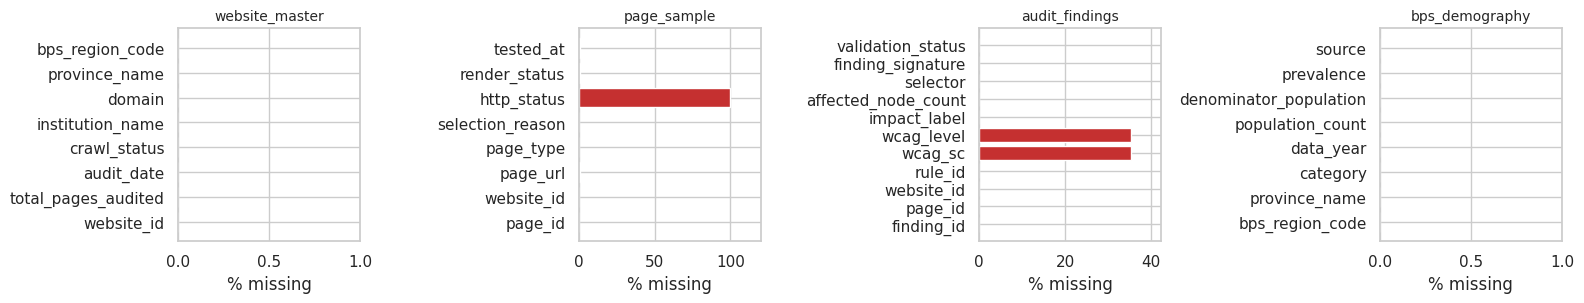

In [7]:
# --- Visualisasi: missing value heatmap ringkas per dataset ---
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, (name, df) in zip(axes, dataset_registry.items()):
    missing_pct = df.isna().mean() * 100
    ax.barh(missing_pct.index, missing_pct.values, color="#c53030")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("% missing")
    ax.set_xlim(0, max(1, missing_pct.max() * 1.2 if missing_pct.max() > 0 else 1))
plt.tight_layout()
plt.savefig("fig_01_dataset_overview.png", dpi=200)
plt.show()

In [8]:
from IPython.display import display, Markdown

_max_missing_ds = df_dataset_summary.loc[df_dataset_summary["Missing Values (%)"].idxmax()]
_total_rows_all = df_dataset_summary["Rows"].sum()

display(Markdown(f"""### Interpretasi

**Temuan utama**
- Total {len(dataset_registry)} dataset dimuat dengan gabungan {_total_rows_all:,} baris.
- Dataset dengan proporsi missing value tertinggi adalah **{_max_missing_ds['Dataset']}**
  ({_max_missing_ds['Missing Values (%)']}% dari seluruh sel).
- `audit_findings` ({df_finding.shape[0]:,} baris) adalah dataset terbesar dan menjadi basis
  utama perhitungan Technical Score pada tahap-tahap berikutnya.

**Perbandingan**
- `website_master` memiliki {df_website.shape[0]} baris (unik per `website_id`), sedangkan
  `page_sample` memiliki {df_page.shape[0]} baris halaman sampel yang diuji — rata-rata
  {df_page.shape[0] / df_website['website_id'].nunique():.1f} halaman per website.

**Implikasi**
- Missing value pada `audit_findings` (kolom `wcag_sc`/`wcag_level`) sudah diantisipasi dan
  ditangani secara eksplisit pada Cell 8 (klasifikasi rule ke SC WCAG / best-practice-only),
  sehingga tidak mengganggu integritas skor teknis.

**Catatan**
- Statistik ini murni deskriptif dataset mentah sebelum integrasi; jumlah baris efektif yang
  dipakai dalam perhitungan skor dapat berbeda setelah scoping, dedup, dan filtering pada
  tahap-tahap selanjutnya."""))

### Interpretasi

**Temuan utama**
- Total 4 dataset dimuat dengan gabungan 4,391 baris.
- Dataset dengan proporsi missing value tertinggi adalah **page_sample**
  (12.75% dari seluruh sel).
- `audit_findings` (4,109 baris) adalah dataset terbesar dan menjadi basis
  utama perhitungan Technical Score pada tahap-tahap berikutnya.

**Perbandingan**
- `website_master` memiliki 30 baris (unik per `website_id`), sedangkan
  `page_sample` memiliki 150 baris halaman sampel yang diuji — rata-rata
  5.0 halaman per website.

**Implikasi**
- Missing value pada `audit_findings` (kolom `wcag_sc`/`wcag_level`) sudah diantisipasi dan
  ditangani secara eksplisit pada Cell 8 (klasifikasi rule ke SC WCAG / best-practice-only),
  sehingga tidak mengganggu integritas skor teknis.

**Catatan**
- Statistik ini murni deskriptif dataset mentah sebelum integrasi; jumlah baris efektif yang
  dipakai dalam perhitungan skor dapat berbeda setelah scoping, dedup, dan filtering pada
  tahap-tahap selanjutnya.

---

## 2. Data Integration & Mapping

Tahap ini membangun **jembatan** antara temuan teknis axe-core (berbasis `rule_id` dan `wcag_sc`)
dengan tiga kategori kesulitan fungsional yang dipakai penelitian ini (**melihat**, **mendengar**,
**tangan**) — sesuai kategori yang tersedia pada `bps_demography.csv`.

Dua sub-tahap dilakukan:

1. **Klasifikasi rule axe-core**: memisahkan rule yang terpetakan ke Success Criterion (SC) WCAG
   tertentu dari rule yang bersifat *best-practice* (tidak terikat SC manapun secara resmi pada
   metadata axe-core, misalnya `region`, `landmark-one-main`, `heading-order`). Rule best-practice
   tetap disimpan untuk transparansi data, namun **tidak** dihitung dalam skor teknis karena tidak
   merepresentasikan pelanggaran WCAG.
2. **`sc_function_mapping`**: matriks bobot fungsi yang menyatakan seberapa relevan sebuah SC WCAG
   terhadap tiap kategori kesulitan fungsional (skala 0–1), disusun berdasarkan definisi kriteria
   pada WCAG 2.2 Understanding Documents dan literatur functional-needs mapping (WebAIM, W3C-WAI).

In [9]:
# ----------------------------------------------------------------------
# 2.1 Klasifikasi rule_id axe-core -> WCAG Success Criterion
#     (mengisi wcag_sc/wcag_level yang kosong pada audit_findings)
# ----------------------------------------------------------------------
RULE_TO_WCAG = {
    "aria-allowed-role": ("4.1.2", "A"),
    "aria-dialog-name": ("4.1.2", "A"),
    "presentation-role-conflict": ("4.1.2", "A"),
}

BEST_PRACTICE_RULES = {
    "region", "heading-order", "landmark-one-main", "page-has-heading-one",
    "landmark-complementary-is-top-level", "image-redundant-alt", "landmark-unique",
    "empty-heading", "landmark-main-is-top-level", "landmark-no-duplicate-main",
    "skip-link", "tabindex",
}

missing_mask = df_finding["wcag_sc"].isna()
for rule_id, (sc, level) in RULE_TO_WCAG.items():
    m = missing_mask & (df_finding["rule_id"] == rule_id)
    df_finding.loc[m, "wcag_sc"] = sc
    df_finding.loc[m, "wcag_level"] = level

df_finding["is_best_practice_only"] = df_finding["rule_id"].isin(BEST_PRACTICE_RULES)

still_missing = df_finding[df_finding["wcag_sc"].isna() & ~df_finding["is_best_practice_only"]]
assert len(still_missing) == 0, "Ada rule_id di luar cakupan klasifikasi wcag_sc / best-practice."

print("Rule diklasifikasikan sebagai best-practice-only (tidak dihitung skor teknis):")
print(df_finding.loc[df_finding["is_best_practice_only"], "rule_id"].value_counts())
print()
print(f"Total temuan WCAG-mapped : {(~df_finding['is_best_practice_only']).sum()}")
print(f"Total temuan best-practice-only : {df_finding['is_best_practice_only'].sum()}")

Rule diklasifikasikan sebagai best-practice-only (tidak dihitung skor teknis):
rule_id
region                                 1053
heading-order                           121
landmark-one-main                        74
page-has-heading-one                     42
landmark-complementary-is-top-level      40
image-redundant-alt                      33
landmark-unique                          29
empty-heading                             8
landmark-main-is-top-level                7
landmark-no-duplicate-main                6
skip-link                                 5
tabindex                                  5
Name: count, dtype: int64

Total temuan WCAG-mapped : 2686
Total temuan best-practice-only : 1423


In [10]:
# ----------------------------------------------------------------------
# 2.2 Normalisasi wcag_sc bernilai ganda (mis. "2.1.1;2.1.3")
#     -> satu baris per pasangan (finding, SC)
# ----------------------------------------------------------------------
df_finding["wcag_sc"] = df_finding["wcag_sc"].astype(str)
df_finding_expanded = df_finding.assign(
    wcag_sc=df_finding["wcag_sc"].str.split(";")
).explode("wcag_sc")
df_finding_expanded["wcag_sc"] = df_finding_expanded["wcag_sc"].str.strip()
df_finding_expanded.loc[df_finding_expanded["wcag_sc"] == "nan", "wcag_sc"] = np.nan

print(f"Baris audit_findings sebelum ekspansi SC ganda : {len(df_finding)}")
print(f"Baris audit_findings setelah ekspansi SC ganda : {len(df_finding_expanded)}")

Baris audit_findings sebelum ekspansi SC ganda : 4109
Baris audit_findings setelah ekspansi SC ganda : 4824


In [11]:
# ----------------------------------------------------------------------
# 2.3 sc_function_mapping — bobot fungsi tiap SC terhadap kategori
#     kesulitan fungsional (skala 0.0 - 1.0)
# ----------------------------------------------------------------------
SC_FUNCTION_WEIGHTS = {
    # sc      : {melihat, mendengar, tangan}
    "1.1.1": {"melihat": 1.0, "mendengar": 0.0, "tangan": 0.1},
    "1.3.1": {"melihat": 0.9, "mendengar": 0.0, "tangan": 0.2},
    "1.4.1": {"melihat": 1.0, "mendengar": 0.0, "tangan": 0.0},
    "1.4.3": {"melihat": 1.0, "mendengar": 0.0, "tangan": 0.0},
    "1.4.4": {"melihat": 0.8, "mendengar": 0.0, "tangan": 0.1},
    "2.1.1": {"melihat": 0.2, "mendengar": 0.0, "tangan": 1.0},
    "2.1.3": {"melihat": 0.2, "mendengar": 0.0, "tangan": 1.0},
    "2.2.1": {"melihat": 0.3, "mendengar": 0.0, "tangan": 0.8},
    "2.2.2": {"melihat": 0.4, "mendengar": 0.0, "tangan": 0.5},
    "2.4.2": {"melihat": 0.7, "mendengar": 0.0, "tangan": 0.1},
    "2.4.4": {"melihat": 0.8, "mendengar": 0.0, "tangan": 0.2},
    "3.1.1": {"melihat": 0.8, "mendengar": 0.0, "tangan": 0.0},
    "4.1.2": {"melihat": 0.7, "mendengar": 0.0, "tangan": 0.6},
}

SC_JUSTIFICATION = {
    "1.1.1": "Teks alternatif gambar utamanya dibutuhkan pengguna pembaca layar (kesulitan melihat).",
    "1.3.1": "Struktur info/relasi mendukung navigasi pembaca layar; sebagian relevan bagi navigasi non-mouse.",
    "1.4.1": "Ketergantungan pada warna semata berdampak langsung pada kesulitan melihat/persepsi warna.",
    "1.4.3": "Kontras warna adalah kebutuhan fungsional utama pengguna low vision.",
    "1.4.4": "Kemampuan memperbesar teks utamanya menopang pengguna dengan keterbatasan penglihatan.",
    "2.1.1": "Aksesibilitas keyboard adalah kebutuhan inti pengguna dengan keterbatasan tangan/motorik.",
    "2.1.3": "Cakupan penuh aksesibilitas keyboard tanpa pengecualian, relevansi utama pada kesulitan tangan.",
    "2.2.1": "Batas waktu yang dapat disesuaikan penting bagi pengguna dengan keterbatasan motorik dalam berinteraksi.",
    "2.2.2": "Kontrol jeda/berhenti konten bergerak relevan bagi pengguna low vision maupun keterbatasan motorik.",
    "2.4.2": "Judul halaman membantu orientasi pengguna pembaca layar saat berpindah halaman/tab.",
    "2.4.4": "Kejelasan tujuan tautan penting bagi navigasi pembaca layar dan navigasi non-mouse.",
    "3.1.1": "Penanda bahasa halaman menentukan ketepatan pelafalan pembaca layar.",
    "4.1.2": "Nama/peran/nilai elemen antarmuka menentukan keberhasilan pembaca layar maupun kontrol non-mouse (mis. voice control, switch).",
}

sc_function_mapping_rows = []
for sc, weights in SC_FUNCTION_WEIGHTS.items():
    for category, value in weights.items():
        sc_function_mapping_rows.append({
            "wcag_sc": sc,
            "category": category,
            "mapping_value": value,
            "source_type": "Functional-needs mapping (WCAG 2.2 Understanding Documents)",
            "source_url": f"https://www.w3.org/WAI/WCAG22/Understanding/{sc.replace('.', '-')}",
            "justification": SC_JUSTIFICATION[sc],
            "mapping_status": "verified",
        })

df_sc_mapping = pd.DataFrame(sc_function_mapping_rows)
df_sc_mapping.to_csv("sc_function_mapping.csv", index=False)
print(f"sc_function_mapping.csv tersimpan -> {df_sc_mapping.shape[0]} baris "
      f"({df_sc_mapping['wcag_sc'].nunique()} SC x {len(CATEGORIES)} kategori)")
df_sc_mapping.head(6)

sc_function_mapping.csv tersimpan -> 39 baris (13 SC x 3 kategori)


,wcag_sc,category,mapping_value,source_type,source_url,justification,mapping_status
0,1.1.1,melihat,1.0,Functional-needs mapping (WCAG 2.2 Understandi...,https://www.w3.org/WAI/WCAG22/Understanding/1-1-1,Teks alternatif gambar utamanya dibutuhkan pen...,verified
1,1.1.1,mendengar,0.0,Functional-needs mapping (WCAG 2.2 Understandi...,https://www.w3.org/WAI/WCAG22/Understanding/1-1-1,Teks alternatif gambar utamanya dibutuhkan pen...,verified
2,1.1.1,tangan,0.1,Functional-needs mapping (WCAG 2.2 Understandi...,https://www.w3.org/WAI/WCAG22/Understanding/1-1-1,Teks alternatif gambar utamanya dibutuhkan pen...,verified
3,1.3.1,melihat,0.9,Functional-needs mapping (WCAG 2.2 Understandi...,https://www.w3.org/WAI/WCAG22/Understanding/1-3-1,Struktur info/relasi mendukung navigasi pembac...,verified
4,1.3.1,mendengar,0.0,Functional-needs mapping (WCAG 2.2 Understandi...,https://www.w3.org/WAI/WCAG22/Understanding/1-3-1,Struktur info/relasi mendukung navigasi pembac...,verified
5,1.3.1,tangan,0.2,Functional-needs mapping (WCAG 2.2 Understandi...,https://www.w3.org/WAI/WCAG22/Understanding/1-3-1,Struktur info/relasi mendukung navigasi pembac...,verified


In [12]:
# Verifikasi cakupan: seluruh wcag_sc hasil audit (di luar best-practice-only)
# sudah memiliki bobot fungsi 'verified'.
sc_diaudit = set(df_finding_expanded.loc[~df_finding_expanded["is_best_practice_only"], "wcag_sc"].dropna())
sc_termapping = set(df_sc_mapping["wcag_sc"])
sc_tanpa_mapping = sc_diaudit - sc_termapping
assert len(sc_tanpa_mapping) == 0, f"SC belum punya bobot fungsi: {sc_tanpa_mapping}"
print(f"Seluruh {len(sc_diaudit)} SC hasil audit telah memiliki bobot fungsi verified.")
print(sorted(sc_diaudit))

Seluruh 13 SC hasil audit telah memiliki bobot fungsi verified.
['1.1.1', '1.3.1', '1.4.1', '1.4.3', '1.4.4', '2.1.1', '2.1.3', '2.2.1', '2.2.2', '2.4.2', '2.4.4', '3.1.1', '4.1.2']


### Catatan keterbatasan: kategori "mendengar"

Seluruh rule axe-core yang muncul pada dataset ini terkait elemen visual (kontras, teks
alternatif, struktur) dan interaksi keyboard — **bukan** elemen audio/video (subtitle, transkrip,
audio description). Ini konsisten dengan sifat axe-core sebagai *automated-detectable checker*:
kepatuhan SC terkait media (mis. 1.2.x) memerlukan pemeriksaan manual dan tidak masuk cakupan
audit ini. Akibatnya, `technical_score` untuk kategori **mendengar** akan bernilai nol pada
seluruh website — bukan berarti tidak ada hambatan bagi pengguna dengan kesulitan mendengar,
melainkan keterbatasan cakupan deteksi otomatis. Kategori ini tetap disertakan dalam analisis
`demographic_score` untuk transparansi, dan keterbatasan ini didokumentasikan sebagai bagian dari
batasan penelitian.

In [13]:
# ----------------------------------------------------------------------
# 2.4 Integrasi: audit_findings (expanded) x sc_function_mapping x
#     page_sample x website_master x bps_demography
# ----------------------------------------------------------------------
IMPACT_WEIGHT = {"minor": 0.25, "moderate": 0.5, "serious": 0.75, "critical": 1.0}

df_relevant = df_finding_expanded[~df_finding_expanded["is_best_practice_only"]].copy()
df_relevant["impact_weight"] = df_relevant["impact_label"].map(IMPACT_WEIGHT)
assert df_relevant["impact_weight"].isna().sum() == 0, "Ada impact_label di luar kamus bobot."
assert df_relevant.loc[
    df_relevant["impact_label"].eq("critical"), "impact_weight"
].eq(1.0).all(), "impact_label critical harus memiliki impact_weight 1.0."

df_relevant = df_relevant.merge(df_page[["page_id", "website_id"]], on=["page_id", "website_id"], how="left")
df_integrated = df_relevant.merge(df_sc_mapping, on="wcag_sc", how="left")
assert df_integrated["mapping_value"].isna().sum() == 0, "Ada baris tidak menemukan bobot fungsi SC."

df_integrated = df_integrated.merge(
    df_website[["website_id", "institution_name", "province_name", "bps_region_code", "total_pages_audited"]],
    on="website_id", how="left",
)

print(f"Baris tabel integrasi (finding x SC x kategori) : {len(df_integrated)}")
df_integrated.head(3)

Baris tabel integrasi (finding x SC x kategori) : 10203


,finding_id,page_id,website_id,rule_id,wcag_sc,wcag_level,impact_label,affected_node_count,selector,finding_signature,validation_status,is_best_practice_only,impact_weight,category,mapping_value,source_type,source_url,justification,mapping_status,institution_name,province_name,bps_region_code,total_pages_audited
0,F000001,P001,W01,color-contrast,1.4.3,AA,serious,16,"cms\:widgets[name=""widget_home_kiri_atas""] > c...",53fb0c2c9ed6239a,auto-detected,False,0.75,melihat,1.0,Functional-needs mapping (WCAG 2.2 Understandi...,https://www.w3.org/WAI/WCAG22/Understanding/1-4-3,Kontras warna adalah kebutuhan fungsional utam...,verified,Dinas Sosial Provinsi Aceh,Aceh,11.0,5.0
1,F000001,P001,W01,color-contrast,1.4.3,AA,serious,16,"cms\:widgets[name=""widget_home_kiri_atas""] > c...",53fb0c2c9ed6239a,auto-detected,False,0.75,mendengar,0.0,Functional-needs mapping (WCAG 2.2 Understandi...,https://www.w3.org/WAI/WCAG22/Understanding/1-4-3,Kontras warna adalah kebutuhan fungsional utam...,verified,Dinas Sosial Provinsi Aceh,Aceh,11.0,5.0
2,F000001,P001,W01,color-contrast,1.4.3,AA,serious,16,"cms\:widgets[name=""widget_home_kiri_atas""] > c...",53fb0c2c9ed6239a,auto-detected,False,0.75,tangan,0.0,Functional-needs mapping (WCAG 2.2 Understandi...,https://www.w3.org/WAI/WCAG22/Understanding/1-4-3,Kontras warna adalah kebutuhan fungsional utam...,verified,Dinas Sosial Provinsi Aceh,Aceh,11.0,5.0


---

## 3. Data Cleaning

Pembersihan difokuskan pada konsistensi kunci relasional dan nilai kategori sebelum agregasi.
`bps_region_code` numerik dipakai sebagai kunci penggabungan `website_master` <-> `bps_demography`
(bukan `province_name`) karena penulisan nama provinsi pada kedua tabel tidak selalu identik
(mis. kapitalisasi), sedangkan kode wilayah BPS bersifat baku.

In [14]:
# Standardisasi tipe data & string kategori
df_bps["category"] = df_bps["category"].astype(str).str.lower().str.strip()
df_integrated["category"] = df_integrated["category"].astype(str).str.lower().str.strip()
assert set(df_bps["category"].unique()) == set(CATEGORIES)
assert set(df_integrated["category"].unique()) == set(CATEGORIES)

# Verifikasi seluruh bps_region_code pada website_master ditemukan di bps_demography
kode_tanpa_bps = set(df_website["bps_region_code"]) - set(df_bps["bps_region_code"])
assert len(kode_tanpa_bps) == 0, f"bps_region_code tanpa data BPS: {kode_tanpa_bps}"

# Semua halaman selain render_status == "rendered" dihitung sebagai gagal render.
n_gagal_render = (~df_page["render_status"].eq("rendered")).sum()
print(f"Halaman gagal di-render (dikecualikan dari basis temuan valid) : {n_gagal_render}")
print(f"Website dengan bps_region_code lengkap dan tervalidasi        : {df_website['website_id'].nunique()}")

Halaman gagal di-render (dikecualikan dari basis temuan valid) : 2
Website dengan bps_region_code lengkap dan tervalidasi        : 30


---

## 4. Hash Deduplication

`finding_signature` adalah hash unik yang dihasilkan dari kombinasi `rule_id` dan `selector` DOM
saat audit dijalankan, dipakai untuk mengidentifikasi apakah dua baris temuan sesungguhnya merujuk
node HTML yang sama. Deduplikasi dilakukan pada level (`page_id`, `rule_id`, `finding_signature`)
agar node yang sama tidak dihitung berulang jika axe-core mencatatnya lebih dari satu kali dalam
proses audit.

In [15]:
n_sebelum = len(df_integrated)
df_integrated["dedup_key"] = df_integrated["page_id"].astype(str) + "|" + \
    df_integrated["rule_id"].astype(str) + "|" + df_integrated["finding_signature"].astype(str)

df_integrated = df_integrated.drop_duplicates(subset=["dedup_key", "wcag_sc", "category"]).copy()
n_sesudah = len(df_integrated)

print(f"Baris sebelum dedup : {n_sebelum}")
print(f"Baris sesudah dedup : {n_sesudah}")
print(f"Duplikat node terdeteksi & dihapus : {n_sebelum - n_sesudah}")

# Best-practice rows tetap disimpan pada export untuk transparansi,
# tetapi tidak dimasukkan ke df_integrated yang digunakan dalam perhitungan skor.
df_best_practice_export = df_finding_expanded[
    df_finding_expanded["is_best_practice_only"]
].copy()

df_best_practice_export["impact_weight"] = df_best_practice_export["impact_label"].map(IMPACT_WEIGHT)
df_best_practice_export = df_best_practice_export.merge(
    df_page[["page_id", "website_id"]],
    on=["page_id", "website_id"],
    how="inner",
)
df_best_practice_export = df_best_practice_export.merge(
    df_website[
        ["website_id", "institution_name", "province_name",
         "bps_region_code", "total_pages_audited"]
    ],
    on="website_id",
    how="inner",
)

df_best_practice_export["category"] = pd.NA
df_best_practice_export["mapping_value"] = 0.0
df_best_practice_export["source_type"] = pd.NA
df_best_practice_export["source_url"] = pd.NA
df_best_practice_export["justification"] = pd.NA
df_best_practice_export["mapping_status"] = "best_practice_only"
df_best_practice_export["dedup_key"] = (
    df_best_practice_export["page_id"].astype(str) + "|" +
    df_best_practice_export["rule_id"].astype(str) + "|" +
    df_best_practice_export["finding_signature"].astype(str)
)

df_integrated_export = pd.concat(
    [
        df_integrated,
        df_best_practice_export.reindex(columns=df_integrated.columns),
    ],
    ignore_index=True,
)

df_integrated_export.to_csv("audit_findings_integrated.csv", index=False)
print(f"Baris best-practice yang disertakan dalam export : {len(df_best_practice_export)}")
print(f"Total baris audit_findings_integrated.csv         : {len(df_integrated_export)}")

Baris sebelum dedup : 10203
Baris sesudah dedup : 10203
Duplikat node terdeteksi & dihapus : 0
Baris best-practice yang disertakan dalam export : 1384
Total baris audit_findings_integrated.csv         : 11587


## 4.1 Enrichment — Website & Page Coverage Analysis

*(Tambahan analitis. `df_integrated` di titik ini sudah melalui hash-dedup —
Cell 19 — sehingga representatif terhadap basis data yang dipakai pada
seluruh perhitungan skor berikutnya.)*

Bagian ini menjawab: **seberapa besar cakupan audit** (jumlah website,
provinsi, halaman) dan **seberapa berhasil proses rendering halaman**.

In [16]:
# --- Coverage headline numbers ---
n_website = df_website["website_id"].nunique()
n_provinsi = df_website["province_name"].nunique()
n_halaman = df_page["page_id"].nunique()
pages_per_site = df_page.groupby("website_id")["page_id"].nunique()

coverage_headline = pd.DataFrame({
    "Metrik": [
        "Jumlah website", "Jumlah provinsi", "Jumlah halaman (scope final)",
        "Rata-rata halaman/website", "Median halaman/website",
        "Minimum halaman/website", "Maksimum halaman/website",
        "Std. dev halaman/website",
    ],
    "Nilai": [
        n_website, n_provinsi, n_halaman,
        round(pages_per_site.mean(), 2), pages_per_site.median(),
        pages_per_site.min(), pages_per_site.max(),
        round(pages_per_site.std(), 2),
    ],
})
coverage_headline

,Metrik,Nilai
0,Jumlah website,30.0
1,Jumlah provinsi,30.0
2,Jumlah halaman (scope final),150.0
3,Rata-rata halaman/website,5.0
4,Median halaman/website,5.0
5,Minimum halaman/website,5.0
6,Maksimum halaman/website,5.0
7,Std. dev halaman/website,0.0


In [17]:
# --- Rendering success rate ---
render_counts = df_page["render_status"].value_counts()
n_rendered_ = df_page["render_status"].eq("rendered").sum()
n_gagal_render_ = len(df_page) - n_rendered_
pct_rendered = round(100 * n_rendered_ / len(df_page), 2)

render_summary = pd.DataFrame({
    "Status": render_counts.index,
    "Jumlah Halaman": render_counts.values,
    "Persentase (%)": (100 * render_counts.values / len(df_page)).round(2),
})
print(f"Tingkat keberhasilan rendering keseluruhan: {pct_rendered}%")
render_summary

Tingkat keberhasilan rendering keseluruhan: 98.67%


,Status,Jumlah Halaman,Persentase (%)
0,rendered,148,98.67
1,timeout,1,0.67


In [18]:
# --- Website Coverage Summary table ---
findings_per_site = (
    df_integrated.groupby("website_id")["finding_id"].nunique()
    if "finding_id" in df_integrated.columns else df_integrated.groupby("website_id").size()
)
render_per_site = df_page.groupby("website_id")["render_status"].agg(
    rendered=lambda s: (s == "rendered").sum(),
    failed=lambda s: (s != "rendered").sum(),
)

df_coverage_summary = (
    df_website[["website_id", "institution_name", "province_name", "total_pages_audited"]]
    .merge(pages_per_site.rename("n_halaman"), on="website_id", how="left")
    .merge(render_per_site, on="website_id", how="left")
    .merge(findings_per_site.rename("n_findings_relevan"), on="website_id", how="left")
)
df_coverage_summary["n_findings_relevan"] = df_coverage_summary["n_findings_relevan"].fillna(0).astype(int)
df_coverage_summary["finding_rate_per_halaman"] = (
    df_coverage_summary["n_findings_relevan"] / df_coverage_summary["n_halaman"]
).round(2)

df_coverage_summary.sort_values("n_findings_relevan", ascending=False)

,website_id,institution_name,province_name,total_pages_audited,n_halaman,rendered,failed,n_findings_relevan,finding_rate_per_halaman
0,W01,Dinas Sosial Provinsi Aceh,Aceh,5,5,5,0,293,58.6
27,W32,Dinas Sosial Provinsi Maluku Utara,Maluku Utara,5,5,5,0,204,40.8
29,W34,Dinas Sosial Provinsi Papua Barat,Papua Barat,5,5,5,0,143,28.6
11,W13,Dinas Sosial Provinsi Jawa Tengah,Jawa Tengah,5,5,5,0,143,28.6
6,W08,Dinas Sosial Provinsi Lampung,Lampung,5,5,5,0,138,27.6
9,W11,Dinas Sosial Provinsi Dki Jakarta,Dki Jakarta,5,5,5,0,132,26.4
5,W06,Dinas Sosial Provinsi Sumatera Selatan,Sumatera Selatan,4,5,4,1,127,25.4
19,W21,Dinas Sosial Provinsi Kalimantan Tengah,Kalimantan Tengah,5,5,5,0,114,22.8
16,W18,Dinas Sosial Provinsi Nusa Tenggara Barat,Nusa Tenggara Barat,5,5,5,0,110,22.0
28,W33,Dinas Sosial Provinsi Papua,Papua,5,5,5,0,102,20.4


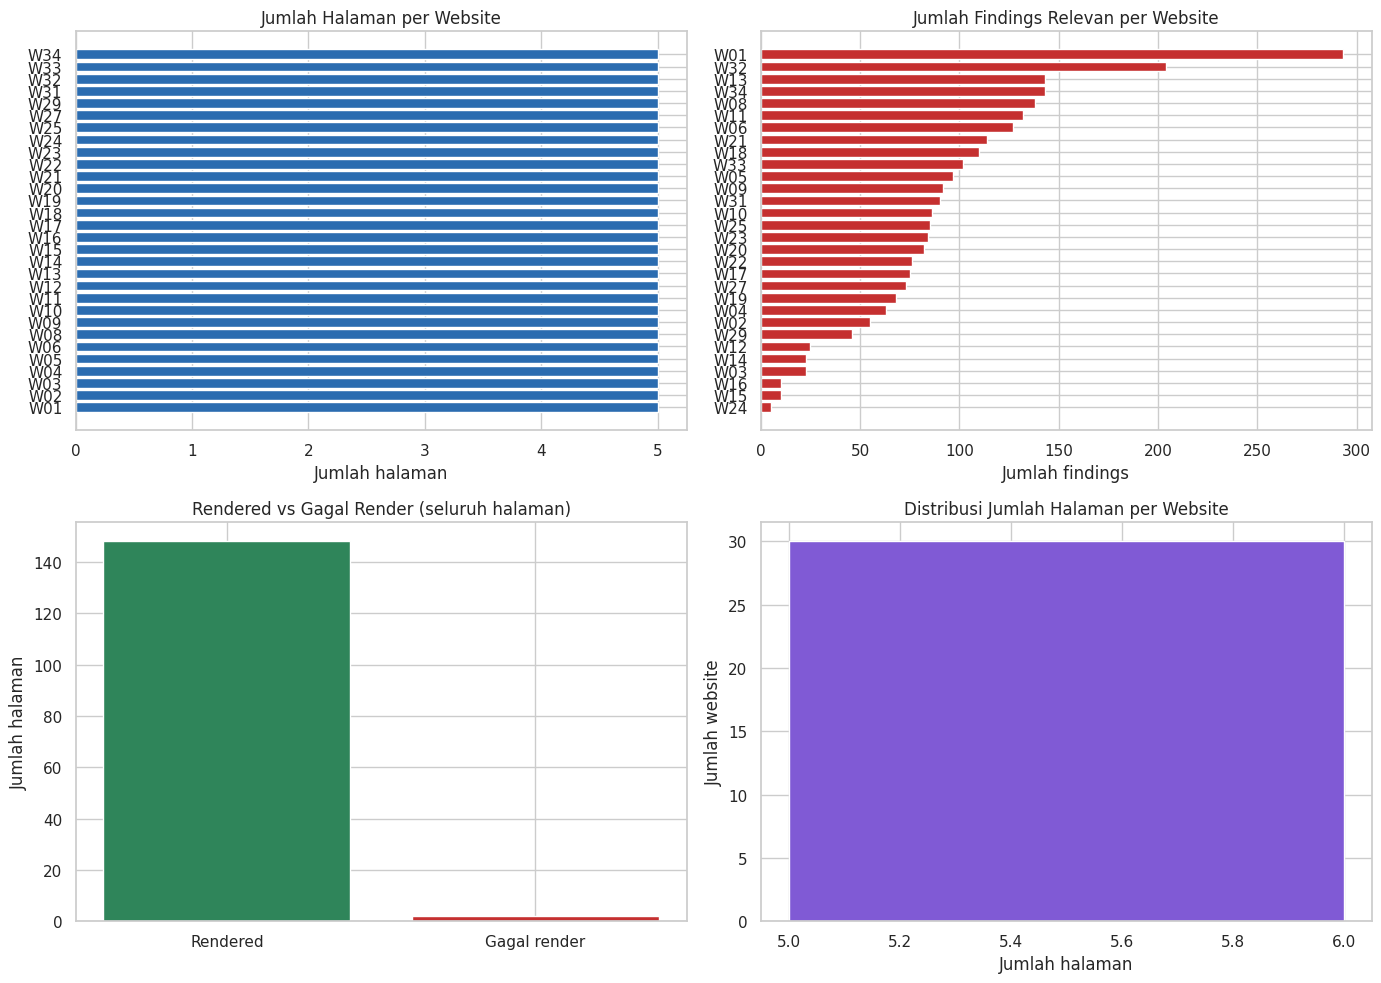

In [19]:
# --- Visualisasi cakupan: halaman & findings per website, rendered vs failed ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

order_pages = df_coverage_summary.sort_values("n_halaman", ascending=True)
axes[0, 0].barh(order_pages["website_id"], order_pages["n_halaman"], color="#2b6cb0")
axes[0, 0].set_title("Jumlah Halaman per Website")
axes[0, 0].set_xlabel("Jumlah halaman")

order_find = df_coverage_summary.sort_values("n_findings_relevan", ascending=True)
axes[0, 1].barh(order_find["website_id"], order_find["n_findings_relevan"], color="#c53030")
axes[0, 1].set_title("Jumlah Findings Relevan per Website")
axes[0, 1].set_xlabel("Jumlah findings")

axes[1, 0].bar(["Rendered", "Gagal render"], [n_rendered_, n_gagal_render_],
                color=["#2f855a", "#c53030"])
axes[1, 0].set_title("Rendered vs Gagal Render (seluruh halaman)")
axes[1, 0].set_ylabel("Jumlah halaman")

axes[1, 1].hist(pages_per_site.values, bins=range(pages_per_site.min(), pages_per_site.max() + 2),
                 color="#805ad5", edgecolor="white")
axes[1, 1].set_title("Distribusi Jumlah Halaman per Website")
axes[1, 1].set_xlabel("Jumlah halaman")
axes[1, 1].set_ylabel("Jumlah website")

plt.tight_layout()
plt.savefig("fig_02_website_coverage.png", dpi=200)
plt.show()

In [20]:
from IPython.display import display, Markdown

_top_find = df_coverage_summary.sort_values("n_findings_relevan", ascending=False).iloc[0]
_low_find = df_coverage_summary.sort_values("n_findings_relevan", ascending=True).iloc[0]

display(Markdown(f"""### Interpretasi

**Temuan utama**
- Audit mencakup {n_website} website Dinas Sosial Provinsi di {n_provinsi} provinsi dengan total
  {n_halaman} halaman sampel (rata-rata {pages_per_site.mean():.2f} halaman/website,
  median {pages_per_site.median():.0f}).
- Tingkat keberhasilan rendering halaman mencapai {pct_rendered}% ({n_rendered_} dari
  {len(df_page)} halaman); {n_gagal_render_} halaman gagal dirender dan dikecualikan dari basis
  temuan valid (lihat Cell 16).

**Perbandingan**
- Website dengan beban findings relevan tertinggi adalah **{_top_find['website_id']}**
  ({_top_find['institution_name']}) dengan {_top_find['n_findings_relevan']} temuan, sedangkan
  **{_low_find['website_id']}** ({_low_find['institution_name']}) memiliki temuan paling sedikit
  yaitu {_low_find['n_findings_relevan']}.

**Implikasi**
- Variasi jumlah halaman per website (std. dev {pages_per_site.std():.2f}) berarti perbandingan
  jumlah temuan mentah antar website berpotensi bias terhadap ukuran situs — inilah motivasi
  metodologis pembagian dengan `total_pages_audited` pada Failure Rate dan Technical Score
  (Cell 22 & Cell 25).

**Catatan**
- `n_findings_relevan` pada tabel di atas dihitung dari `df_integrated` pasca hash-dedup dan
  pasca pengecualian rule best-practice-only, sehingga sudah konsisten dengan basis skor
  penelitian, bukan jumlah baris mentah `audit_findings.csv`."""))

### Interpretasi

**Temuan utama**
- Audit mencakup 30 website Dinas Sosial Provinsi di 30 provinsi dengan total
  150 halaman sampel (rata-rata 5.00 halaman/website,
  median 5).
- Tingkat keberhasilan rendering halaman mencapai 98.67% (148 dari
  150 halaman); 2 halaman gagal dirender dan dikecualikan dari basis
  temuan valid (lihat Cell 16).

**Perbandingan**
- Website dengan beban findings relevan tertinggi adalah **W01**
  (Dinas Sosial Provinsi Aceh) dengan 293 temuan, sedangkan
  **W24** (Dinas Sosial Provinsi Kalimantan Utara) memiliki temuan paling sedikit
  yaitu 5.

**Implikasi**
- Variasi jumlah halaman per website (std. dev 0.00) berarti perbandingan
  jumlah temuan mentah antar website berpotensi bias terhadap ukuran situs — inilah motivasi
  metodologis pembagian dengan `total_pages_audited` pada Failure Rate dan Technical Score
  (Cell 22 & Cell 25).

**Catatan**
- `n_findings_relevan` pada tabel di atas dihitung dari `df_integrated` pasca hash-dedup dan
  pasca pengecualian rule best-practice-only, sehingga sudah konsisten dengan basis skor
  penelitian, bukan jumlah baris mentah `audit_findings.csv`.

## 4.2 Enrichment — Audit Findings Analysis

Analisis mendalam distribusi temuan audit (post hash-dedup, WCAG-mapped) di
seluruh dimensi: `impact_label`, `wcag_level`, `rule_id`, `wcag_sc`, provinsi,
dan halaman. Ini adalah salah satu sumber utama bahan Bab Hasil.

In [21]:
# --- Total findings & findings per dimensi utama ---
total_findings_relevan = len(df_integrated.drop_duplicates(subset=["dedup_key"]))
print(f"Total findings relevan (unik per dedup_key, WCAG-mapped) : {total_findings_relevan}")
print(f"Total baris integrasi (finding x SC x kategori)          : {len(df_integrated)}")
print(f"Jumlah rule_id unik terlibat                              : {df_integrated['rule_id'].nunique()}")
print(f"Jumlah WCAG SC unik terlibat                              : {df_integrated['wcag_sc'].nunique()}")

Total findings relevan (unik per dedup_key, WCAG-mapped) : 2686
Total baris integrasi (finding x SC x kategori)          : 10203
Jumlah rule_id unik terlibat                              : 21
Jumlah WCAG SC unik terlibat                              : 13


In [22]:
# --- Finding Distribution by Impact ---
df_unique_findings = df_integrated.drop_duplicates(subset=["dedup_key"])
impact_dist = df_unique_findings["impact_label"].value_counts().reindex(
    ["minor", "moderate", "serious", "critical"]
).fillna(0).astype(int)
df_impact_dist = pd.DataFrame({
    "Impact": impact_dist.index,
    "Count": impact_dist.values,
    "Percentage": (100 * impact_dist.values / impact_dist.sum()).round(2),
})
df_impact_dist

,Impact,Count,Percentage
0,minor,27,1.01
1,moderate,0,0.00
2,serious,2019,75.17
3,critical,640,23.83


In [23]:
# --- Finding Distribution by WCAG Level ---
level_dist = df_unique_findings["wcag_level"].value_counts()
df_level_dist = pd.DataFrame({
    "Level": level_dist.index,
    "Count": level_dist.values,
    "Percentage": (100 * level_dist.values / level_dist.sum()).round(2),
})
df_level_dist

,Level,Count,Percentage
0,A,1486,55.32
1,AA,1200,44.68


In [24]:
# --- Top WCAG Success Criteria ---
top_sc = (
    df_unique_findings.groupby("wcag_sc")
    .agg(
        jumlah_findings=("finding_id", "count") if "finding_id" in df_unique_findings.columns
            else ("dedup_key", "count"),
        website_terdampak=("website_id", "nunique"),
        halaman_terdampak=("page_id", "nunique"),
        total_affected_nodes=("affected_node_count", "sum"),
    )
    .reset_index()
    .sort_values("jumlah_findings", ascending=False)
)
top_sc

,wcag_sc,jumlah_findings,website_terdampak,halaman_terdampak,total_affected_nodes
3,1.4.3,1184,29,101,27526
9,2.4.4,706,22,93,8596
0,1.1.1,395,18,39,10051
11,4.1.2,306,26,86,2572
1,1.3.1,22,6,18,42
10,3.1.1,21,6,21,21
2,1.4.1,16,3,11,26
4,1.4.4,16,4,12,24
5,2.1.1,9,5,5,29
6,2.2.1,6,2,6,6


In [25]:
# --- Top Rule ID (dengan distribusi impact) ---
rule_base = (
    df_unique_findings.groupby("rule_id")
    .agg(
        jumlah_findings=("dedup_key", "count"),
        website_terdampak=("website_id", "nunique"),
        halaman_terdampak=("page_id", "nunique"),
    )
    .reset_index()
)
rule_impact_pivot = (
    df_unique_findings.groupby(["rule_id", "impact_label"]).size()
    .unstack(fill_value=0)
    .reindex(columns=["minor", "moderate", "serious", "critical"], fill_value=0)
)
df_top_rule = rule_base.merge(rule_impact_pivot, on="rule_id", how="left").sort_values(
    "jumlah_findings", ascending=False
)
df_top_rule

,rule_id,jumlah_findings,website_terdampak,halaman_terdampak,minor,moderate,serious,critical
6,color-contrast,1184,29,101,0,0,1184,0
13,link-name,706,22,93,0,0,706,0
10,image-alt,395,18,39,0,0,0,395
5,button-name,194,20,57,0,0,0,194
8,frame-title,42,14,36,0,0,42,0
0,aria-allowed-role,21,3,5,21,0,0,0
9,html-has-lang,21,6,21,0,0,21,0
20,select-name,20,5,10,0,0,0,20
14,list,17,6,17,0,0,17,0
12,link-in-text-block,16,3,11,0,0,16,0


In [26]:
# --- Findings per provinsi & per page_type ---
findings_per_provinsi = (
    df_unique_findings.groupby("province_name").size().rename("jumlah_findings").sort_values(ascending=False)
)
findings_per_pagetype = (
    df_unique_findings.merge(df_page[["page_id", "page_type"]], on="page_id", how="left")
    .groupby("page_type").size().rename("jumlah_findings").sort_values(ascending=False)
)
print("Findings per provinsi (Top 10):")
display(findings_per_provinsi.head(10).to_frame())
print("Findings per page_type:")
display(findings_per_pagetype.to_frame())

Findings per provinsi (Top 10):


,jumlah_findings
province_name,
Aceh,293
Maluku Utara,204
Papua Barat,143
Jawa Tengah,143
Lampung,138
Dki Jakarta,132
Sumatera Selatan,127
Kalimantan Tengah,114
Nusa Tenggara Barat,110


Findings per page_type:


,jumlah_findings
page_type,
Homepage,758
Konten,654
Interaksi/Kontak,469
Layanan,432
Profil,361


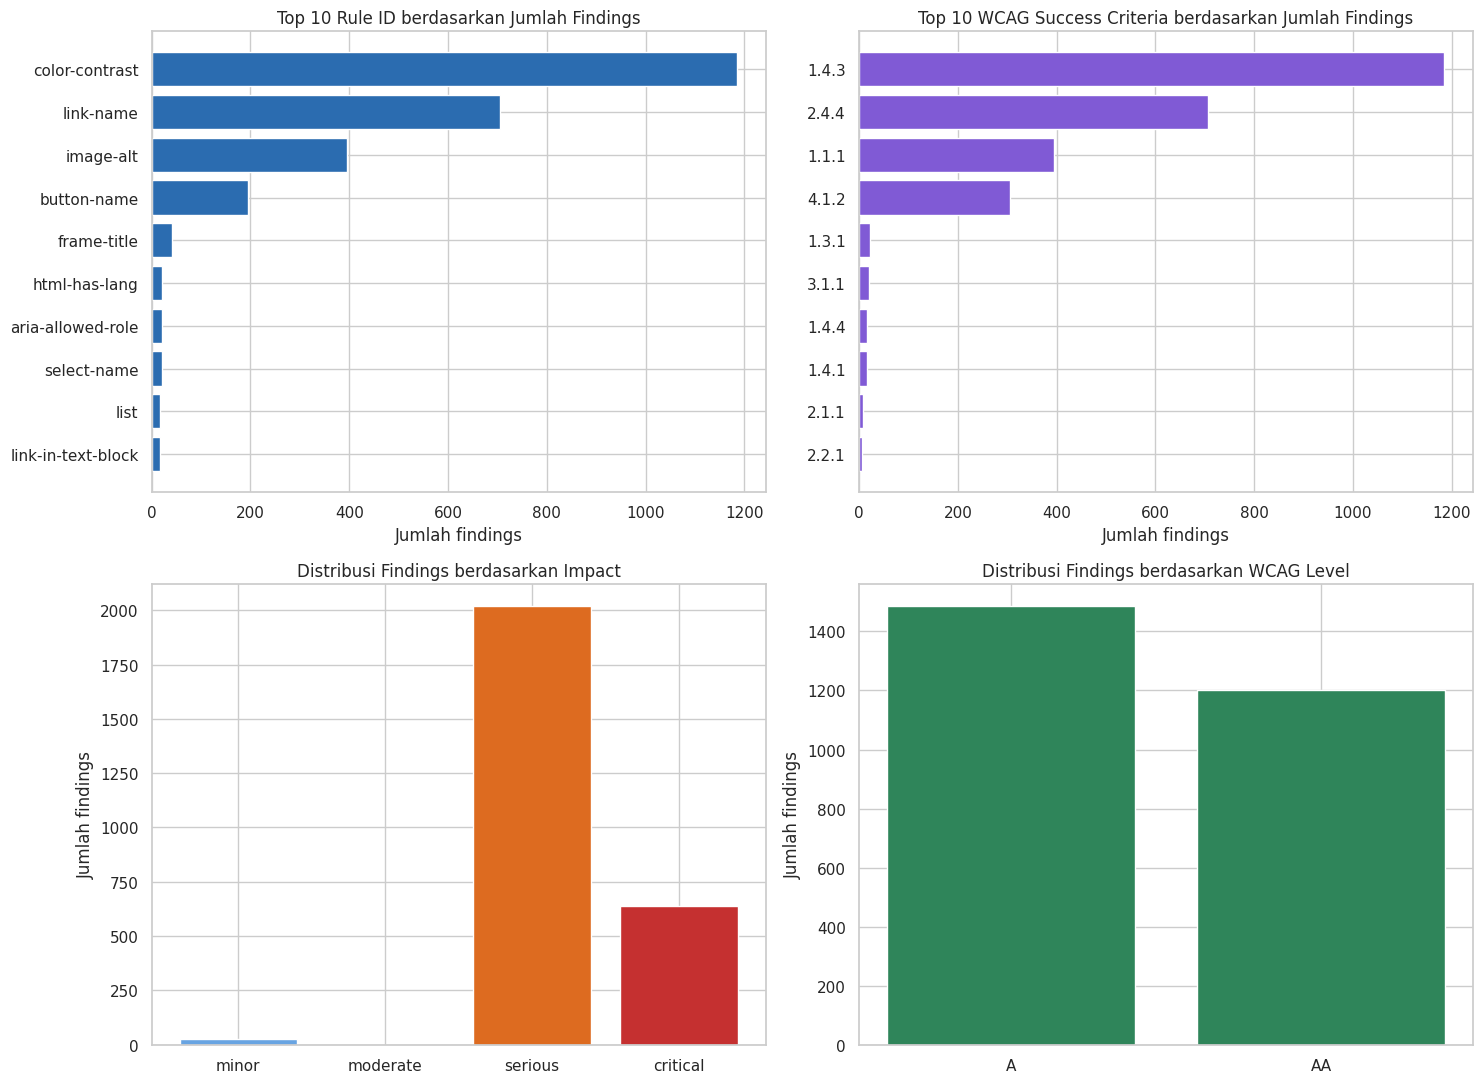

In [27]:
# --- Visualisasi: top rules, top SC, impact distribution, WCAG level ---
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

top10_rule = df_top_rule.head(10).sort_values("jumlah_findings")
axes[0, 0].barh(top10_rule["rule_id"], top10_rule["jumlah_findings"], color="#2b6cb0")
axes[0, 0].set_title("Top 10 Rule ID berdasarkan Jumlah Findings")
axes[0, 0].set_xlabel("Jumlah findings")

top10_sc = top_sc.head(10).sort_values("jumlah_findings")
axes[0, 1].barh(top10_sc["wcag_sc"], top10_sc["jumlah_findings"], color="#805ad5")
axes[0, 1].set_title("Top 10 WCAG Success Criteria berdasarkan Jumlah Findings")
axes[0, 1].set_xlabel("Jumlah findings")

colors_impact = {"minor": "#68a4e2", "moderate": "#d69e2e", "serious": "#dd6b20", "critical": "#c53030"}
axes[1, 0].bar(df_impact_dist["Impact"], df_impact_dist["Count"],
                color=[colors_impact[i] for i in df_impact_dist["Impact"]])
axes[1, 0].set_title("Distribusi Findings berdasarkan Impact")
axes[1, 0].set_ylabel("Jumlah findings")

axes[1, 1].bar(df_level_dist["Level"], df_level_dist["Count"], color="#2f855a")
axes[1, 1].set_title("Distribusi Findings berdasarkan WCAG Level")
axes[1, 1].set_ylabel("Jumlah findings")

plt.tight_layout()
plt.savefig("fig_04_findings_by_impact.png", dpi=200)
plt.show()

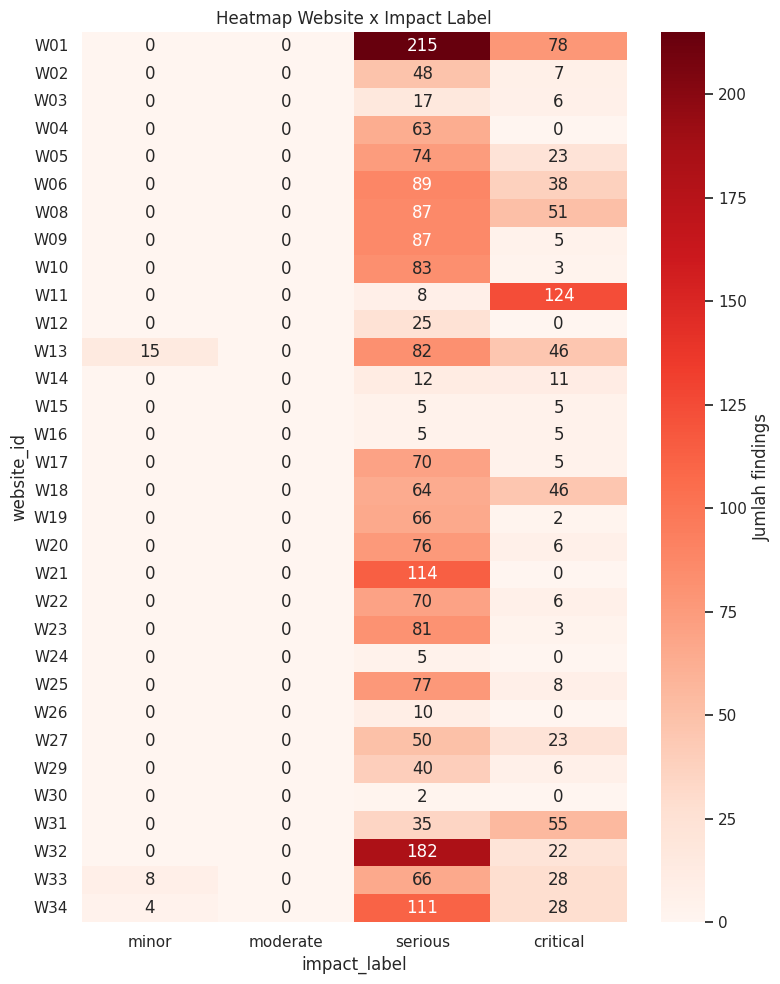

In [28]:
# --- Heatmap: website x impact_label (jumlah findings) ---
pivot_website_impact = (
    df_unique_findings.groupby(["website_id", "impact_label"]).size()
    .unstack(fill_value=0)
    .reindex(columns=["minor", "moderate", "serious", "critical"], fill_value=0)
)
fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(pivot_website_impact, cmap="Reds", annot=True, fmt="d", ax=ax, cbar_kws={"label": "Jumlah findings"})
ax.set_title("Heatmap Website x Impact Label")
plt.tight_layout()
plt.savefig("fig_05_top_wcag_rules.png", dpi=200)
plt.show()

In [29]:
from IPython.display import display, Markdown

_top_rule_row = df_top_rule.iloc[0]
_top_sc_row = top_sc.sort_values('jumlah_findings', ascending=False).iloc[0]
_dominant_impact = df_impact_dist.sort_values("Count", ascending=False).iloc[0]

display(Markdown(f"""### Interpretasi

**Temuan utama**
- Total {total_findings_relevan} findings relevan (WCAG-mapped, unik pasca hash-dedup) terdeteksi
  di seluruh {n_website} website, melibatkan {df_integrated['rule_id'].nunique()} rule_id axe-core
  unik dan {df_integrated['wcag_sc'].nunique()} WCAG Success Criterion unik.
- Rule axe-core paling sering muncul adalah **{_top_rule_row['rule_id']}**
  ({_top_rule_row['jumlah_findings']} findings, berdampak pada {_top_rule_row['website_terdampak']}
  website), sedangkan SC paling dominan adalah **{_top_sc_row['wcag_sc']}**
  ({_top_sc_row['jumlah_findings']} findings).
- Kategori impact paling dominan adalah **{_dominant_impact['Impact']}**
  ({_dominant_impact['Count']} findings, {_dominant_impact['Percentage']}% dari total).

**Perbandingan**
- Distribusi WCAG Level menunjukkan Level {df_level_dist.iloc[0]['Level']} sebagai yang
  terbanyak ({df_level_dist.iloc[0]['Count']} findings,
  {df_level_dist.iloc[0]['Percentage']}%), konsisten dengan sifat rule axe-core yang lebih
  banyak mendeteksi pelanggaran level dasar (A) dibanding level lanjut (AAA).

**Implikasi**
- Konsentrasi findings pada rule dan SC tertentu mengindikasikan pola kesalahan sistemik
  (mis. atribut alt text, kontras warna) yang berpotensi diperbaiki melalui perbaikan
  template/komponen bersama, bukan perbaikan halaman satu-per-satu.

**Catatan**
- Angka pada bagian ini dihitung dari `df_integrated` setelah hash-dedup (Cell 19) dan sebelum
  pembobotan impact/mapping fungsi — murni distribusi mentah WCAG-mapped findings."""))

### Interpretasi

**Temuan utama**
- Total 2686 findings relevan (WCAG-mapped, unik pasca hash-dedup) terdeteksi
  di seluruh 30 website, melibatkan 21 rule_id axe-core
  unik dan 13 WCAG Success Criterion unik.
- Rule axe-core paling sering muncul adalah **color-contrast**
  (1184 findings, berdampak pada 29
  website), sedangkan SC paling dominan adalah **1.4.3**
  (1184 findings).
- Kategori impact paling dominan adalah **serious**
  (2019 findings, 75.17% dari total).

**Perbandingan**
- Distribusi WCAG Level menunjukkan Level A sebagai yang
  terbanyak (1486 findings,
  55.32%), konsisten dengan sifat rule axe-core yang lebih
  banyak mendeteksi pelanggaran level dasar (A) dibanding level lanjut (AAA).

**Implikasi**
- Konsentrasi findings pada rule dan SC tertentu mengindikasikan pola kesalahan sistemik
  (mis. atribut alt text, kontras warna) yang berpotensi diperbaiki melalui perbaikan
  template/komponen bersama, bukan perbaikan halaman satu-per-satu.

**Catatan**
- Angka pada bagian ini dihitung dari `df_integrated` setelah hash-dedup (Cell 19) dan sebelum
  pembobotan impact/mapping fungsi — murni distribusi mentah WCAG-mapped findings.

## 4.3 Enrichment — Analisis Impact Mendalam

Memperdalam `impact_label` dengan bobot (`IMPACT_WEIGHT`, sudah didefinisikan
pada Cell 13) untuk melihat **beban temuan tertimbang**, bukan sekadar jumlah
mentah.

In [30]:
# --- Weighted impact per website & per SC ---
df_unique_findings = df_unique_findings.copy()
df_unique_findings["impact_weight_"] = df_unique_findings["impact_label"].map(IMPACT_WEIGHT)

weighted_impact_per_site = (
    df_unique_findings.groupby("website_id")["impact_weight_"].sum().rename("total_weighted_impact")
)
weighted_impact_per_sc = (
    df_unique_findings.groupby("wcag_sc")["impact_weight_"].sum().rename("total_weighted_impact")
    .sort_values(ascending=False)
)

print("Total weighted impact per SC (Top 10):")
display(weighted_impact_per_sc.head(10).to_frame())

Total weighted impact per SC (Top 10):


,total_weighted_impact
wcag_sc,
1.4.3,888.00
2.4.4,529.50
1.1.1,395.00
4.1.2,270.50
1.3.1,17.75
1.4.4,16.00
3.1.1,15.75
1.4.1,12.00
2.1.1,6.75


In [31]:
# --- Tabel: Website dengan Beban Temuan Terbesar ---
impact_by_label_pivot = (
    df_unique_findings.groupby(["website_id", "impact_label"]).size()
    .unstack(fill_value=0)
    .reindex(columns=["critical", "serious", "moderate", "minor"], fill_value=0)
)
df_website_burden = (
    df_website[["website_id", "institution_name", "province_name"]]
    .merge(df_unique_findings.groupby("website_id").size().rename("total_findings"),
           on="website_id", how="left")
    .merge(impact_by_label_pivot, on="website_id", how="left")
    .merge(weighted_impact_per_site, on="website_id", how="left")
)
for c in ["total_findings", "critical", "serious", "moderate", "minor", "total_weighted_impact"]:
    df_website_burden[c] = df_website_burden[c].fillna(0)

df_website_burden = df_website_burden.sort_values("total_weighted_impact", ascending=False)
df_website_burden

,website_id,institution_name,province_name,total_findings,critical,serious,moderate,minor,total_weighted_impact
0,W01,Dinas Sosial Provinsi Aceh,Aceh,293,78,215,0,0,239.25
27,W32,Dinas Sosial Provinsi Maluku Utara,Maluku Utara,204,22,182,0,0,158.50
9,W11,Dinas Sosial Provinsi Dki Jakarta,Dki Jakarta,132,124,8,0,0,130.00
6,W08,Dinas Sosial Provinsi Lampung,Lampung,138,51,87,0,0,116.25
29,W34,Dinas Sosial Provinsi Papua Barat,Papua Barat,143,28,111,0,4,112.25
11,W13,Dinas Sosial Provinsi Jawa Tengah,Jawa Tengah,143,46,82,0,15,111.25
5,W06,Dinas Sosial Provinsi Sumatera Selatan,Sumatera Selatan,127,38,89,0,0,104.75
16,W18,Dinas Sosial Provinsi Nusa Tenggara Barat,Nusa Tenggara Barat,110,46,64,0,0,94.00
19,W21,Dinas Sosial Provinsi Kalimantan Tengah,Kalimantan Tengah,114,0,114,0,0,85.50
26,W31,Dinas Sosial Provinsi Maluku,Maluku,90,55,35,0,0,81.25


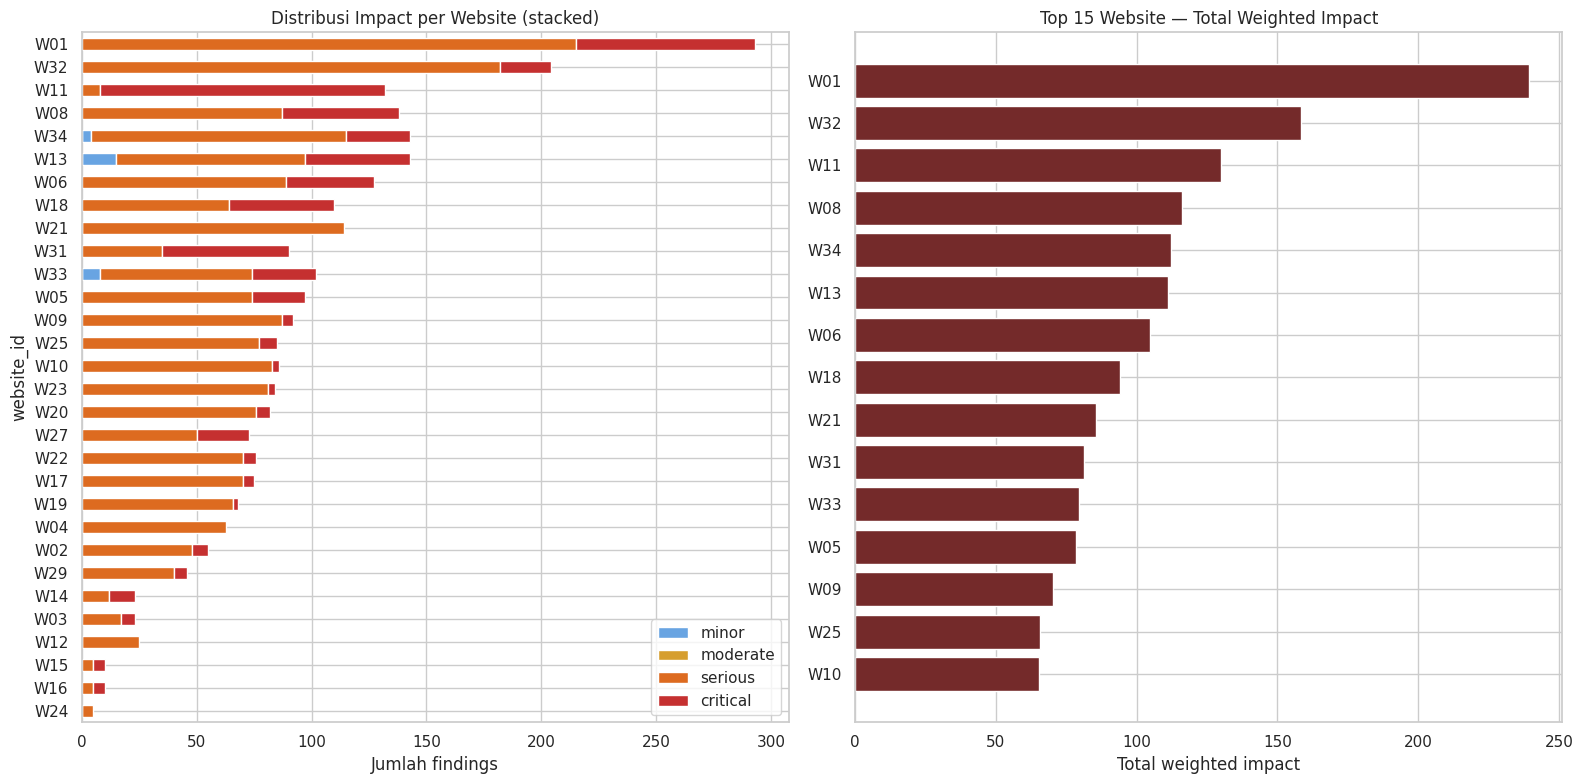

In [32]:
# --- Visualisasi: stacked bar impact per website & ranking weighted impact ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

stack_data = df_website_burden.set_index("website_id")[["minor", "moderate", "serious", "critical"]]
stack_data.plot(kind="barh", stacked=True, ax=axes[0],
                 color=["#68a4e2", "#d69e2e", "#dd6b20", "#c53030"])
axes[0].set_title("Distribusi Impact per Website (stacked)")
axes[0].set_xlabel("Jumlah findings")
axes[0].invert_yaxis()

top15_weighted = df_website_burden.sort_values("total_weighted_impact", ascending=True).tail(15)
axes[1].barh(top15_weighted["website_id"], top15_weighted["total_weighted_impact"], color="#742a2a")
axes[1].set_title("Top 15 Website — Total Weighted Impact")
axes[1].set_xlabel("Total weighted impact")

plt.tight_layout()
plt.savefig("fig_04b_weighted_impact_ranking.png", dpi=200)
plt.show()

In [33]:
from IPython.display import display, Markdown

_top_burden = df_website_burden.iloc[0]
display(Markdown(f"""### Interpretasi

**Temuan utama**
- Website dengan beban temuan tertimbang (weighted impact) terbesar adalah
  **{_top_burden['website_id']}** ({_top_burden['institution_name']}, {_top_burden['province_name']})
  dengan total weighted impact {_top_burden['total_weighted_impact']:.2f} dari
  {int(_top_burden['total_findings'])} findings ({int(_top_burden['critical'])} critical,
  {int(_top_burden['serious'])} serious).
- SC dengan total weighted impact tertinggi lintas seluruh website adalah
  **{weighted_impact_per_sc.index[0]}** ({weighted_impact_per_sc.iloc[0]:.2f}).

**Perbandingan**
- Pembobotan impact menggeser urutan prioritas dibanding sekadar menghitung jumlah temuan
  mentah — website dengan banyak temuan minor bisa memiliki weighted impact lebih rendah
  daripada website dengan sedikit temuan tapi didominasi critical/serious.

**Implikasi**
- Weighted impact per website inilah komponen numerator utama pada `technical_score`
  (Cell 25), sehingga ranking di atas memberi intuisi awal terhadap hasil Technical Score
  Analysis pada bagian berikutnya.

**Catatan**
- Angka weighted impact di sini belum dibagi `total_pages_audited` (belum menjadi
  `technical_score`) dan belum dipisah per kategori kesulitan fungsional — pemisahan per
  kategori dilakukan pada Technical Score Analysis."""))

### Interpretasi

**Temuan utama**
- Website dengan beban temuan tertimbang (weighted impact) terbesar adalah
  **W01** (Dinas Sosial Provinsi Aceh, Aceh)
  dengan total weighted impact 239.25 dari
  293 findings (78 critical,
  215 serious).
- SC dengan total weighted impact tertinggi lintas seluruh website adalah
  **1.4.3** (888.00).

**Perbandingan**
- Pembobotan impact menggeser urutan prioritas dibanding sekadar menghitung jumlah temuan
  mentah — website dengan banyak temuan minor bisa memiliki weighted impact lebih rendah
  daripada website dengan sedikit temuan tapi didominasi critical/serious.

**Implikasi**
- Weighted impact per website inilah komponen numerator utama pada `technical_score`
  (Cell 25), sehingga ranking di atas memberi intuisi awal terhadap hasil Technical Score
  Analysis pada bagian berikutnya.

**Catatan**
- Angka weighted impact di sini belum dibagi `total_pages_audited` (belum menjadi
  `technical_score`) dan belum dipisah per kategori kesulitan fungsional — pemisahan per
  kategori dilakukan pada Technical Score Analysis.

## 4.4 Enrichment — WCAG Success Criteria x Functional Difficulty Mapping

Menampilkan mapping `SC_FUNCTION_WEIGHTS` (sudah didefinisikan, tidak diubah)
dalam bentuk heatmap dan menautkannya dengan frekuensi temuan aktual.

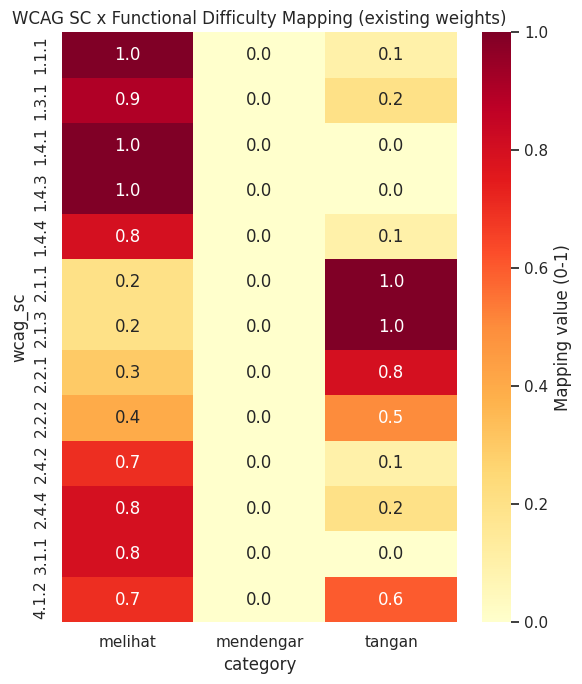

In [34]:
# --- WCAG SC x Functional Difficulty heatmap (mapping value, TIDAK diubah) ---
mapping_pivot = df_sc_mapping.pivot(index="wcag_sc", columns="category", values="mapping_value")
mapping_pivot = mapping_pivot[["melihat", "mendengar", "tangan"]]

fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(mapping_pivot, cmap="YlOrRd", annot=True, fmt=".1f", ax=ax,
            cbar_kws={"label": "Mapping value (0-1)"})
ax.set_title("WCAG SC x Functional Difficulty Mapping (existing weights)")
plt.tight_layout()
plt.savefig("fig_06_top_wcag_sc.png", dpi=200)
plt.show()

In [35]:
# --- SC frequency x mapping value gabungan ---
df_sc_full = top_sc.merge(mapping_pivot.reset_index(), on="wcag_sc", how="left")
df_sc_full = df_sc_full.sort_values("jumlah_findings", ascending=False)
df_sc_full

,wcag_sc,jumlah_findings,website_terdampak,halaman_terdampak,total_affected_nodes,melihat,mendengar,tangan
0,1.4.3,1184,29,101,27526,1.0,0.0,0.0
1,2.4.4,706,22,93,8596,0.8,0.0,0.2
2,1.1.1,395,18,39,10051,1.0,0.0,0.1
3,4.1.2,306,26,86,2572,0.7,0.0,0.6
4,1.3.1,22,6,18,42,0.9,0.0,0.2
5,3.1.1,21,6,21,21,0.8,0.0,0.0
6,1.4.1,16,3,11,26,1.0,0.0,0.0
7,1.4.4,16,4,12,24,0.8,0.0,0.1
8,2.1.1,9,5,5,29,0.2,0.0,1.0
9,2.2.1,6,2,6,6,0.3,0.0,0.8


In [36]:
from IPython.display import display, Markdown

_melihat_count = (mapping_pivot["melihat"] > 0).sum()
_mendengar_count = (mapping_pivot["mendengar"] > 0).sum()
_tangan_count = (mapping_pivot["tangan"] > 0).sum()

display(Markdown(f"""### Interpretasi

**Temuan utama**
- Dari {len(mapping_pivot)} SC yang termapping, {_melihat_count} SC relevan (mapping value > 0)
  terhadap kategori **melihat**, {_mendengar_count} terhadap **mendengar**, dan {_tangan_count}
  terhadap **tangan**.
- SC dengan kontribusi jumlah temuan terbanyak, {df_sc_full.iloc[0]['wcag_sc']}, memiliki mapping
  value melihat={df_sc_full.iloc[0]['melihat']}, mendengar={df_sc_full.iloc[0]['mendengar']},
  tangan={df_sc_full.iloc[0]['tangan']}.

**Perbandingan**
- Kolom `mendengar` pada heatmap seluruhnya bernilai 0.0 — konsisten dengan catatan keterbatasan
  pada Cell 12 bahwa tidak ada SC hasil audit axe-core yang relevan terhadap kesulitan mendengar
  dalam dataset ini (rule axe-core seluruhnya bersifat visual/interaksi keyboard, bukan audio/video).

**Implikasi**
- Karena tidak ada SC bermapping > 0 untuk mendengar, `technical_score` kategori mendengar akan
  konsisten 0 pada seluruh website (dikonfirmasi ulang pada Technical Score Analysis).

**Catatan**
- Nilai mapping (`SC_FUNCTION_WEIGHTS`) bersifat tetap/tidak diubah pada enrichment ini —
  seluruh angka diambil langsung dari definisi pada Cell 10."""))

### Interpretasi

**Temuan utama**
- Dari 13 SC yang termapping, 13 SC relevan (mapping value > 0)
  terhadap kategori **melihat**, 0 terhadap **mendengar**, dan 10
  terhadap **tangan**.
- SC dengan kontribusi jumlah temuan terbanyak, 1.4.3, memiliki mapping
  value melihat=1.0, mendengar=0.0,
  tangan=0.0.

**Perbandingan**
- Kolom `mendengar` pada heatmap seluruhnya bernilai 0.0 — konsisten dengan catatan keterbatasan
  pada Cell 12 bahwa tidak ada SC hasil audit axe-core yang relevan terhadap kesulitan mendengar
  dalam dataset ini (rule axe-core seluruhnya bersifat visual/interaksi keyboard, bukan audio/video).

**Implikasi**
- Karena tidak ada SC bermapping > 0 untuk mendengar, `technical_score` kategori mendengar akan
  konsisten 0 pada seluruh website (dikonfirmasi ulang pada Technical Score Analysis).

**Catatan**
- Nilai mapping (`SC_FUNCTION_WEIGHTS`) bersifat tetap/tidak diubah pada enrichment ini —
  seluruh angka diambil langsung dari definisi pada Cell 10.

---

## 5. Failure Rate

Metrik deskriptif awal sebelum pembobotan: kepadatan temuan relevan (unweighted) per halaman
yang diaudit pada tiap website, per kategori kesulitan fungsional.

$$
\text{FailureRate}(w, c) = \frac{N_{\text{relevan}}(w, c)}{P(w)}
$$

dengan $N_{\text{relevan}}(w, c)$ = jumlah temuan unik (pasca hash-dedup) yang terpetakan ke
kategori $c$ (bobot fungsi $> 0$) pada website $w$, dan $P(w)$ = `total_pages_audited` pada
website $w$.

In [37]:
def hitung_failure_rate(df_int, df_web):
    relevan = df_int[df_int["mapping_value"] > 0]
    n_relevan = relevan.groupby(["website_id", "category"]).size().rename("n_relevan")
    idx = pd.MultiIndex.from_product([df_web["website_id"], CATEGORIES], names=["website_id", "category"])
    out = n_relevan.reindex(idx, fill_value=0).reset_index()
    out = out.merge(df_web[["website_id", "total_pages_audited"]], on="website_id", how="left")
    out["failure_rate"] = out["n_relevan"] / out["total_pages_audited"]
    return out

df_failure_rate = hitung_failure_rate(df_integrated, df_website)
df_failure_rate.sort_values("failure_rate", ascending=False).head(10)

,website_id,category,n_relevan,total_pages_audited,failure_rate
0,W01,melihat,360,5,72.00
2,W01,tangan,217,5,43.40
81,W32,melihat,204,5,40.80
15,W06,melihat,163,4,40.75
33,W13,melihat,188,5,37.60
21,W09,melihat,174,5,34.80
18,W08,melihat,172,5,34.40
23,W09,tangan,171,5,34.20
48,W18,melihat,165,5,33.00
50,W18,tangan,161,5,32.20


---

## 6. Technical Score

Failure Rate belum memperhitungkan **tingkat keparahan** (`impact_label`) maupun **relevansi
fungsional** SC terhadap kategori kesulitan (`mapping_value`). Technical Score mengoreksi kedua
hal tersebut:

$$
\text{TechnicalScore}(w, c) = \frac{1}{P(w)} \sum_{i \,\in\, \text{relevan}(w,c)}
\text{ImpactWeight}(\text{impact\_label}_i) \times \text{MappingValue}(\text{wcag\_sc}_i, c)
$$

dengan bobot keparahan $\text{ImpactWeight} \in \{0.25,\ 0.5,\ 0.75,\ 1.0\}$ untuk
{minor, moderate, serious, critical} — konsisten dengan bobot yang sama pada tahap Explainability
di bagian akhir notebook ini.

In [38]:
def hitung_technical_score(df_int, df_web):
    relevan = df_int[df_int["mapping_value"] > 0].copy()
    relevan["skor_kontribusi"] = relevan["impact_weight"] * relevan["mapping_value"]
    agg = relevan.groupby(["website_id", "category"])["skor_kontribusi"].sum().rename("skor_total")
    idx = pd.MultiIndex.from_product([df_web["website_id"], CATEGORIES], names=["website_id", "category"])
    out = agg.reindex(idx, fill_value=0.0).reset_index()
    out = out.merge(df_web[["website_id", "total_pages_audited"]], on="website_id", how="left")
    out["technical_score"] = out["skor_total"] / out["total_pages_audited"]
    return out.drop(columns=["skor_total"])

df_technical = hitung_technical_score(df_integrated, df_website)
print("Technical score = 0 untuk kategori mendengar pada seluruh website (lihat catatan keterbatasan di atas):")
print(df_technical[df_technical["category"] == "mendengar"]["technical_score"].describe())
df_technical.sort_values("technical_score", ascending=False).head(10)

Technical score = 0 untuk kategori mendengar pada seluruh website (lihat catatan keterbatasan di atas):
count    30.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: technical_score, dtype: float64


,website_id,category,total_pages_audited,technical_score
0,W01,melihat,5,52.3650
81,W32,melihat,5,31.3400
15,W06,melihat,4,25.5125
33,W13,melihat,5,25.0600
18,W08,melihat,5,25.0450
27,W11,melihat,5,24.1700
87,W34,melihat,5,22.0450
48,W18,melihat,5,22.0100
21,W09,melihat,5,20.1100
57,W21,melihat,5,19.7400


## 6.1 Enrichment — Technical Score Analysis

Memperkaya `df_technical` (Cell 25) dengan ranking, statistik deskriptif, dan
visualisasi per kategori kesulitan fungsional.

In [39]:
# --- Technical Score Ranking table ---
df_technical_ranked = df_technical.copy()
df_technical_ranked["rank_in_category"] = df_technical_ranked.groupby("category")["technical_score"].rank(
    ascending=False, method="min"
).astype(int)
df_technical_ranked = df_technical_ranked.merge(
    df_website[["website_id", "institution_name"]], on="website_id", how="left"
)
df_tech_rank_table = df_technical_ranked.sort_values(["category", "rank_in_category"])[
    ["rank_in_category", "website_id", "institution_name", "category", "technical_score"]
].rename(columns={"rank_in_category": "Rank", "institution_name": "Website"})
df_tech_rank_table.head(15)

,Rank,website_id,Website,category,technical_score
0,1,W01,Dinas Sosial Provinsi Aceh,melihat,52.3650
81,2,W32,Dinas Sosial Provinsi Maluku Utara,melihat,31.3400
15,3,W06,Dinas Sosial Provinsi Sumatera Selatan,melihat,25.5125
33,4,W13,Dinas Sosial Provinsi Jawa Tengah,melihat,25.0600
18,5,W08,Dinas Sosial Provinsi Lampung,melihat,25.0450
27,6,W11,Dinas Sosial Provinsi Dki Jakarta,melihat,24.1700
87,7,W34,Dinas Sosial Provinsi Papua Barat,melihat,22.0450
48,8,W18,Dinas Sosial Provinsi Nusa Tenggara Barat,melihat,22.0100
21,9,W09,Dinas Sosial Provinsi Kepulauan Bangka Belitung,melihat,20.1100
57,10,W21,Dinas Sosial Provinsi Kalimantan Tengah,melihat,19.7400


In [40]:
# --- Statistik deskriptif technical_score per kategori ---
tech_stats = df_technical.groupby("category")["technical_score"].agg(
    mean="mean", median="median", std="std", min="min", max="max",
    q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75),
).round(4)
tech_stats

,mean,median,std,min,max,q1,q3
category,,,,,,,
melihat,15.7489,13.79,10.7607,0.6,52.3650,10.1912,21.535
mendengar,0.0000,0.00,0.0000,0.0,0.0000,0.0000,0.000
tangan,4.4686,4.08,3.4536,0.0,12.5625,1.4550,6.960


/tmp/ipykernel_1742/3356151684.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_technical, x="category", y="technical_score", ax=axes[0, 1], palette="Set2")


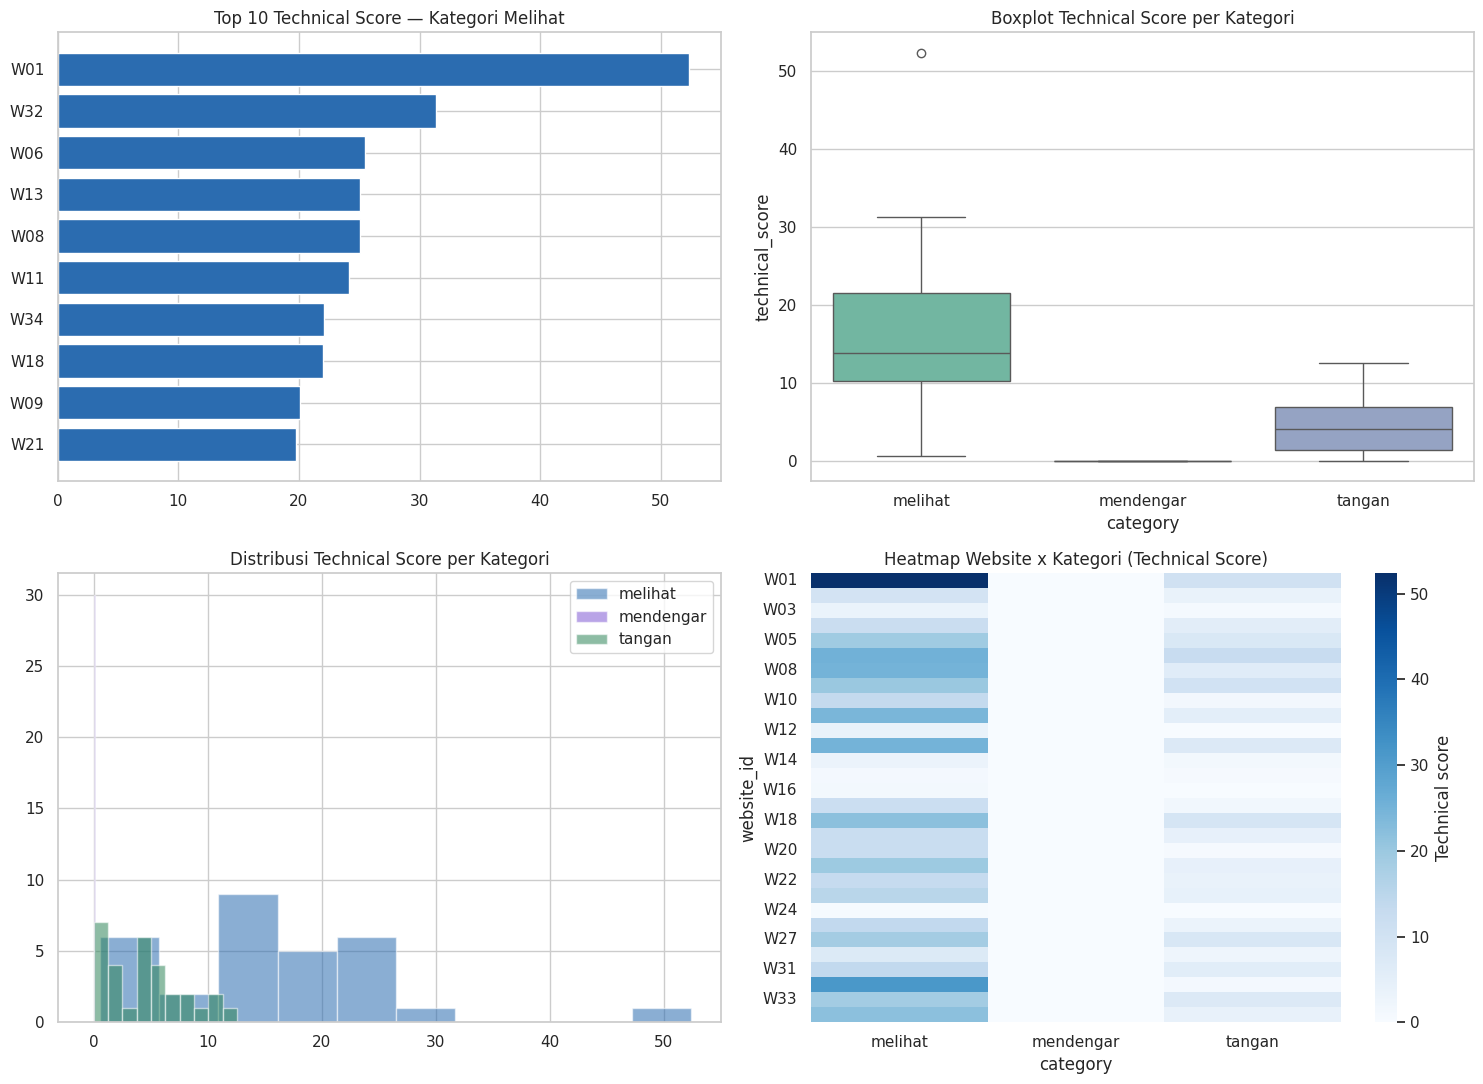

In [41]:
# --- Visualisasi: ranking, boxplot, distribusi, heatmap website x kategori ---
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

top10_melihat = df_technical_ranked[df_technical_ranked["category"] == "melihat"].nlargest(10, "technical_score")
axes[0, 0].barh(top10_melihat["website_id"], top10_melihat["technical_score"], color="#2b6cb0")
axes[0, 0].set_title("Top 10 Technical Score — Kategori Melihat")
axes[0, 0].invert_yaxis()

sns.boxplot(data=df_technical, x="category", y="technical_score", ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Boxplot Technical Score per Kategori")

for category, color in zip(CATEGORIES, ["#2b6cb0", "#805ad5", "#2f855a"]):
    axes[1, 0].hist(df_technical.loc[df_technical["category"] == category, "technical_score"],
                     bins=10, alpha=0.55, label=category, color=color)
axes[1, 0].set_title("Distribusi Technical Score per Kategori")
axes[1, 0].legend()

heat_tech = df_technical.pivot(index="website_id", columns="category", values="technical_score")
sns.heatmap(heat_tech, cmap="Blues", ax=axes[1, 1], cbar_kws={"label": "Technical score"})
axes[1, 1].set_title("Heatmap Website x Kategori (Technical Score)")

plt.tight_layout()
plt.savefig("fig_07_technical_score.png", dpi=200)
plt.show()

In [42]:
from IPython.display import display, Markdown

_tech_top = df_technical_ranked[df_technical_ranked["category"] == "melihat"].nlargest(1, "technical_score").iloc[0]
_tech_nonzero_categories = tech_stats[tech_stats["max"] > 0].index.tolist()

display(Markdown(f"""### Interpretasi

**Temuan utama**
- Technical score tertinggi pada kategori **melihat** dicapai oleh
  **{_tech_top['website_id']}** ({_tech_top['institution_name']}) dengan skor
  {_tech_top['technical_score']:.4f}.
- Rata-rata technical_score per kategori: {', '.join(f"{c}={tech_stats.loc[c, 'mean']:.4f}" for c in CATEGORIES)}.

**Perbandingan**
- Kategori dengan mean technical_score tertinggi adalah **{tech_stats['mean'].idxmax()}**
  ({tech_stats['mean'].max():.4f}); kategori **mendengar** tetap 0 di seluruh website
  (max={tech_stats.loc['mendengar', 'max']:.4f}), sesuai keterbatasan cakupan axe-core yang
  telah didokumentasikan.

**Implikasi**
- Karena technical_score mendengar konstan 0, `technical_norm` kategori tersebut (Cell 34) juga
  akan konstan 0 untuk seluruh website — final_score kategori mendengar pada seluruh skenario SAW
  murni ditentukan oleh demographic_norm.

**Catatan**
- technical_score dihitung dari kontribusi weighted-impact x mapping_value dibagi
  total_pages_audited (formula Cell 24) — bukan jumlah temuan mentah."""))

### Interpretasi

**Temuan utama**
- Technical score tertinggi pada kategori **melihat** dicapai oleh
  **W01** (Dinas Sosial Provinsi Aceh) dengan skor
  52.3650.
- Rata-rata technical_score per kategori: melihat=15.7489, mendengar=0.0000, tangan=4.4686.

**Perbandingan**
- Kategori dengan mean technical_score tertinggi adalah **melihat**
  (15.7489); kategori **mendengar** tetap 0 di seluruh website
  (max=0.0000), sesuai keterbatasan cakupan axe-core yang
  telah didokumentasikan.

**Implikasi**
- Karena technical_score mendengar konstan 0, `technical_norm` kategori tersebut (Cell 34) juga
  akan konstan 0 untuk seluruh website — final_score kategori mendengar pada seluruh skenario SAW
  murni ditentukan oleh demographic_norm.

**Catatan**
- technical_score dihitung dari kontribusi weighted-impact x mapping_value dibagi
  total_pages_audited (formula Cell 24) — bukan jumlah temuan mentah.

---

## 7. Demographic Score

Demographic Score adalah nilai prevalensi disabilitas (BPS Long Form SP2020) pada provinsi lokasi
website, per kategori kesulitan fungsional — dipetakan melalui `bps_region_code`, bukan nama
provinsi mentah.

$$
\text{DemographicScore}(w, c) = \text{Prevalence}\big(\text{bps\_region\_code}(w),\ c\big)
$$

In [43]:
def hitung_demographic_score(df_web, df_bps):
    m = df_web[["website_id", "bps_region_code"]].merge(
        df_bps[["bps_region_code", "category", "prevalence"]], on="bps_region_code", how="left"
    )
    m = m.rename(columns={"prevalence": "demographic_score"})
    assert m["demographic_score"].isna().sum() == 0, "Ada website tanpa data prevalensi BPS."
    return m[["website_id", "category", "demographic_score"]]

df_demographic = hitung_demographic_score(df_website, df_bps)
df_demographic.sort_values("demographic_score", ascending=False).head(10)

,website_id,category,demographic_score
84,W33,melihat,0.0067
85,W33,mendengar,0.0063
48,W18,melihat,0.0060
0,W01,melihat,0.0059
51,W19,melihat,0.0056
75,W29,melihat,0.0054
66,W24,melihat,0.0054
81,W32,melihat,0.0054
37,W14,mendengar,0.0053
52,W19,mendengar,0.0051


## 7.1 Enrichment — Demographic Score Analysis

Memperkaya `df_demographic` (Cell 28) dengan profil prevalensi per provinsi
dan kategori.

In [44]:
# --- Demographic Profile table ---
df_demo_profile = df_demographic.merge(
    df_website[["website_id", "province_name", "bps_region_code"]], on="website_id", how="left"
).merge(
    df_bps[["bps_region_code", "category", "population_count", "denominator_population"]],
    on=["bps_region_code", "category"], how="left"
)
df_demo_profile = df_demo_profile[[
    "province_name", "category", "demographic_score", "population_count", "denominator_population"
]].rename(columns={"demographic_score": "prevalence"}).drop_duplicates().sort_values(
    ["category", "prevalence"], ascending=[True, False]
)
df_demo_profile.head(15)

,province_name,category,prevalence,population_count,denominator_population
84,Papua,melihat,0.0067,29605,4418600
48,Nusa Tenggara Barat,melihat,0.0060,32842,5473700
0,Aceh,melihat,0.0059,31907,5407900
51,Nusa Tenggara Timur,melihat,0.0056,30611,5466300
66,Kalimantan Utara,melihat,0.0054,3930,727800
75,Gorontalo,melihat,0.0054,6441,1192700
81,Maluku Utara,melihat,0.0054,7124,1319300
54,Kalimantan Barat,melihat,0.0049,27153,5541400
87,Papua Barat,melihat,0.0048,5680,1183300
6,Sumatera Barat,melihat,0.0047,26511,5640600


In [45]:
# --- Statistik deskriptif demographic_score per kategori ---
demo_stats = df_demographic.groupby("category")["demographic_score"].agg(
    mean="mean", median="median", std="std", min="min", max="max"
).round(6)
demo_stats

,mean,median,std,min,max
category,,,,,
melihat,0.004293,0.00425,0.001023,0.0025,0.0067
mendengar,0.003817,0.00370,0.000874,0.0021,0.0063
tangan,0.002907,0.00285,0.000650,0.0018,0.0046


In [46]:
# --- Ranking provinsi berdasarkan prevalensi per kategori ---
prov_rank_melihat = df_demo_profile[df_demo_profile["category"] == "melihat"].sort_values(
    "prevalence", ascending=False
)
prov_rank_melihat.head(10)

,province_name,category,prevalence,population_count,denominator_population
84,Papua,melihat,0.0067,29605,4418600
48,Nusa Tenggara Barat,melihat,0.0060,32842,5473700
0,Aceh,melihat,0.0059,31907,5407900
51,Nusa Tenggara Timur,melihat,0.0056,30611,5466300
66,Kalimantan Utara,melihat,0.0054,3930,727800
75,Gorontalo,melihat,0.0054,6441,1192700
81,Maluku Utara,melihat,0.0054,7124,1319300
54,Kalimantan Barat,melihat,0.0049,27153,5541400
87,Papua Barat,melihat,0.0048,5680,1183300
6,Sumatera Barat,melihat,0.0047,26511,5640600


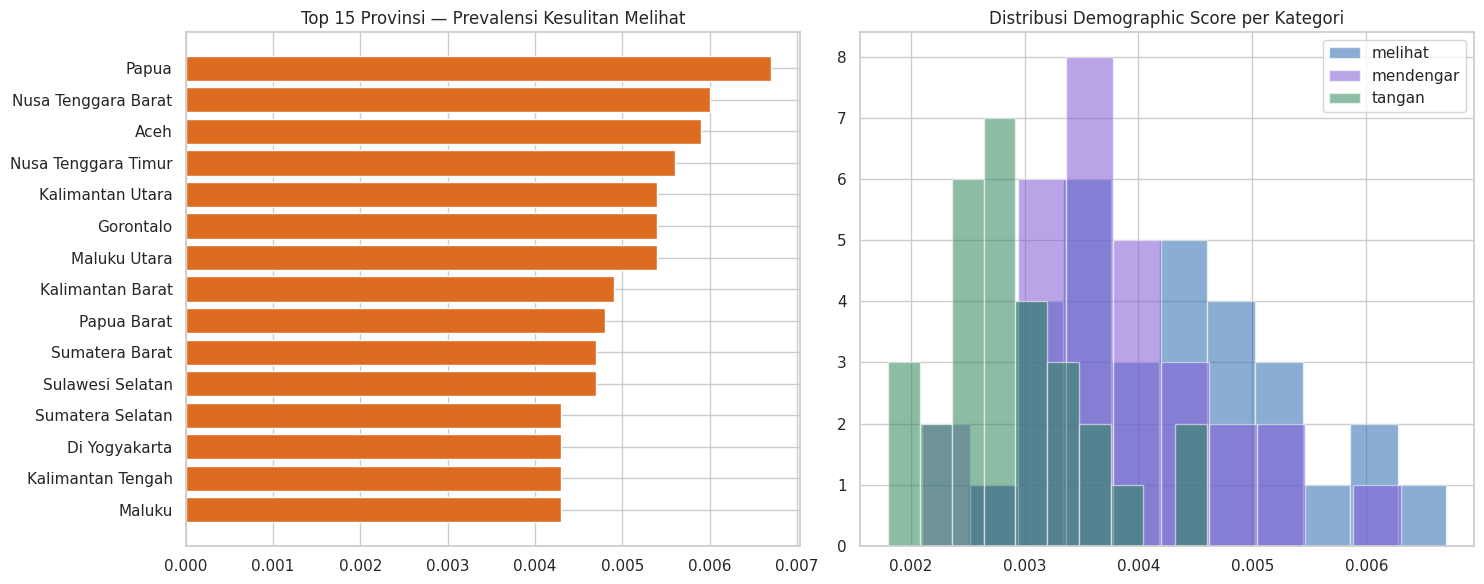

In [47]:
# --- Visualisasi: prevalensi per kategori & provinsi, distribusi ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

demo_top15 = df_demo_profile[df_demo_profile["category"] == "melihat"].nlargest(15, "prevalence")
axes[0].barh(demo_top15["province_name"], demo_top15["prevalence"], color="#dd6b20")
axes[0].set_title("Top 15 Provinsi — Prevalensi Kesulitan Melihat")
axes[0].invert_yaxis()

for category, color in zip(CATEGORIES, ["#2b6cb0", "#805ad5", "#2f855a"]):
    axes[1].hist(df_demographic.loc[df_demographic["category"] == category, "demographic_score"],
                  bins=10, alpha=0.55, label=category, color=color)
axes[1].set_title("Distribusi Demographic Score per Kategori")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_08_demographic_score.png", dpi=200)
plt.show()

In [48]:
from IPython.display import display, Markdown

_demo_top = prov_rank_melihat.iloc[0]
display(Markdown(f"""### Interpretasi

**Temuan utama**
- Provinsi dengan prevalensi kesulitan melihat tertinggi adalah **{_demo_top['province_name']}**
  ({_demo_top['prevalence']:.6f}).
- Rata-rata demographic_score per kategori: {', '.join(f"{c}={demo_stats.loc[c, 'mean']:.6f}" for c in CATEGORIES)}.

**Perbandingan**
- Kategori dengan mean prevalensi tertinggi adalah **{demo_stats['mean'].idxmax()}**; ini berbeda
  dari technical_score yang selalu 0 pada kategori mendengar — demographic_score kategori
  mendengar tetap terisi valid ({demo_stats.loc['mendengar', 'mean']:.6f}) karena bersumber dari
  data BPS, bukan dari cakupan audit axe-core.

**Implikasi**
- Karena `demographic_score` bersumber dari data provinsi (bukan per-website), website yang
  berlokasi di provinsi yang sama akan memiliki demographic_score identik untuk kategori yang
  sama — variasi antar website pada kategori tersebut sepenuhnya berasal dari technical_score.

**Catatan**
- Prevalensi bersumber dari BPS Long Form SP2020 tingkat provinsi (lihat Catatan Metodologi di
  akhir notebook); ini adalah proksi kebutuhan populasi, bukan data spesifik lokasi kantor
  Dinas Sosial."""))

### Interpretasi

**Temuan utama**
- Provinsi dengan prevalensi kesulitan melihat tertinggi adalah **Papua**
  (0.006700).
- Rata-rata demographic_score per kategori: melihat=0.004293, mendengar=0.003817, tangan=0.002907.

**Perbandingan**
- Kategori dengan mean prevalensi tertinggi adalah **melihat**; ini berbeda
  dari technical_score yang selalu 0 pada kategori mendengar — demographic_score kategori
  mendengar tetap terisi valid (0.003817) karena bersumber dari
  data BPS, bukan dari cakupan audit axe-core.

**Implikasi**
- Karena `demographic_score` bersumber dari data provinsi (bukan per-website), website yang
  berlokasi di provinsi yang sama akan memiliki demographic_score identik untuk kategori yang
  sama — variasi antar website pada kategori tersebut sepenuhnya berasal dari technical_score.

**Catatan**
- Prevalensi bersumber dari BPS Long Form SP2020 tingkat provinsi (lihat Catatan Metodologi di
  akhir notebook); ini adalah proksi kebutuhan populasi, bukan data spesifik lokasi kantor
  Dinas Sosial.

---

## 8. Baseline Comparison

Untuk menunjukkan nilai tambah integrasi audit teknis dan data demografis, tiga baseline
pembanding disusun **dari skor mentah** (sebelum normalisasi), masing-masing merepresentasikan
pendekatan prioritisasi yang lebih sederhana / umum dipakai:

- **Baseline A** — ranking dari jumlah temuan mentah tanpa bobot keparahan maupun relevansi
  fungsional (pendekatan "hitung saja pelanggarannya").
- **Baseline B** — ranking dari `technical_score` saja, mengabaikan data demografis
  (pendekatan "audit teknis semata").
- **Baseline C** — ranking dari `demographic_score` saja, mengabaikan hasil audit teknis
  (pendekatan "populasi semata").

Ranking 1 = prioritas tertinggi (nilai basis terbesar).

In [49]:
def rank_desc(series):
    return series.rank(ascending=False, method="min").astype(int)

# Baseline A: jumlah temuan relevan mentah (unweighted) per website x kategori
df_baseline_a = df_failure_rate[["website_id", "category", "n_relevan"]].copy()
df_baseline_a["baseline_a_rank"] = df_baseline_a.groupby("category")["n_relevan"].transform(rank_desc)

# Baseline B: technical_score saja
df_baseline_b = df_technical[["website_id", "category", "technical_score"]].copy()
df_baseline_b["baseline_b_rank"] = df_baseline_b.groupby("category")["technical_score"].transform(rank_desc)

# Baseline C: demographic_score saja
df_baseline_c = df_demographic.copy()
df_baseline_c["baseline_c_rank"] = df_baseline_c.groupby("category")["demographic_score"].transform(rank_desc)

df_baseline = (
    df_baseline_a[["website_id", "category", "baseline_a_rank"]]
    .merge(df_baseline_b[["website_id", "category", "baseline_b_rank"]], on=["website_id", "category"])
    .merge(df_baseline_c[["website_id", "category", "baseline_c_rank"]], on=["website_id", "category"])
)
df_baseline.head(6)

,website_id,category,baseline_a_rank,baseline_b_rank,baseline_c_rank
0,W01,melihat,1,1,3
1,W01,mendengar,1,1,14
2,W01,tangan,1,2,6
3,W02,melihat,23,23,18
4,W02,mendengar,1,1,25
5,W02,tangan,18,17,23


---

## 9. Normalisasi

`technical_score` dan `demographic_score` berada pada skala yang berbeda sehingga tidak bisa
dijumlahkan langsung. Keduanya dinormalisasi min-max **di dalam tiap kategori** (lintas 30
website) ke rentang [0, 1] agar setara sebagai input SAW:

$$
\text{Norm}(x) = \frac{x - \min(x)}{\max(x) - \min(x)}
$$

Jika seluruh nilai dalam satu kategori identik ($\max = \min$), `Norm(x)` didefinisikan sebagai 0
untuk seluruh anggota kategori tersebut (tidak ada variasi yang bisa dibedakan).

In [50]:
def min_max_norm(series):
    rentang = series.max() - series.min()
    if rentang == 0:
        return pd.Series(0.0, index=series.index)
    return (series - series.min()) / rentang

df_technical["technical_norm"] = df_technical.groupby("category")["technical_score"].transform(min_max_norm)
df_demographic["demographic_norm"] = df_demographic.groupby("category")["demographic_score"].transform(min_max_norm)

df_norm = df_technical.merge(df_demographic, on=["website_id", "category"])
df_norm[["website_id", "category", "technical_score", "technical_norm",
         "demographic_score", "demographic_norm"]].head(6)

,website_id,category,technical_score,technical_norm,demographic_score,demographic_norm
0,W01,melihat,52.365,1.000000,0.0059,0.809524
1,W01,mendengar,0.000,0.000000,0.0037,0.380952
2,W01,tangan,10.435,0.830647,0.0033,0.535714
3,W02,melihat,9.665,0.175118,0.0038,0.309524
4,W02,mendengar,0.000,0.000000,0.0030,0.214286
5,W02,tangan,3.830,0.304876,0.0025,0.250000


## 9.1 Enrichment — Normalization Analysis (Before vs After)

Menampilkan eksplisit perbandingan nilai mentah vs hasil normalisasi min-max
(`df_norm`, Cell 34) untuk transparansi proses.

In [51]:
# --- Before vs After Normalization table ---
df_norm_compare = df_norm[[
    "website_id", "category", "technical_score", "technical_norm",
    "demographic_score", "demographic_norm"
]].rename(columns={
    "technical_score": "Raw Technical", "technical_norm": "Technical Norm",
    "demographic_score": "Raw Demographic", "demographic_norm": "Demographic Norm",
})
df_norm_compare.sort_values(["category", "Technical Norm"], ascending=[True, False]).head(15)

,website_id,category,Raw Technical,Technical Norm,Raw Demographic,Demographic Norm
0,W01,melihat,52.3650,1.000000,0.0059,0.809524
81,W32,melihat,31.3400,0.593838,0.0054,0.690476
15,W06,melihat,25.5125,0.481261,0.0043,0.428571
33,W13,melihat,25.0600,0.472520,0.0035,0.238095
18,W08,melihat,25.0450,0.472230,0.0035,0.238095
27,W11,melihat,24.1700,0.455327,0.0038,0.309524
87,W34,melihat,22.0450,0.414276,0.0048,0.547619
48,W18,melihat,22.0100,0.413600,0.0060,0.833333
21,W09,melihat,20.1100,0.376896,0.0031,0.142857
57,W21,melihat,19.7400,0.369748,0.0043,0.428571


In [52]:
# --- Statistik range sebelum vs sesudah normalisasi ---
norm_range_stats = pd.DataFrame({
    "Technical (raw)": df_norm.groupby("category")["technical_score"].agg(["min", "max"]).apply(
        lambda r: f"{r['min']:.4f} - {r['max']:.4f}", axis=1),
    "Technical (norm)": df_norm.groupby("category")["technical_norm"].agg(["min", "max"]).apply(
        lambda r: f"{r['min']:.4f} - {r['max']:.4f}", axis=1),
    "Demographic (raw)": df_norm.groupby("category")["demographic_score"].agg(["min", "max"]).apply(
        lambda r: f"{r['min']:.6f} - {r['max']:.6f}", axis=1),
    "Demographic (norm)": df_norm.groupby("category")["demographic_norm"].agg(["min", "max"]).apply(
        lambda r: f"{r['min']:.4f} - {r['max']:.4f}", axis=1),
})
norm_range_stats

,Technical (raw),Technical (norm),Demographic (raw),Demographic (norm)
category,,,,
melihat,0.6000 - 52.3650,0.0000 - 1.0000,0.002500 - 0.006700,0.0000 - 1.0000
mendengar,0.0000 - 0.0000,0.0000 - 0.0000,0.002100 - 0.006300,0.0000 - 1.0000
tangan,0.0000 - 12.5625,0.0000 - 1.0000,0.001800 - 0.004600,0.0000 - 1.0000


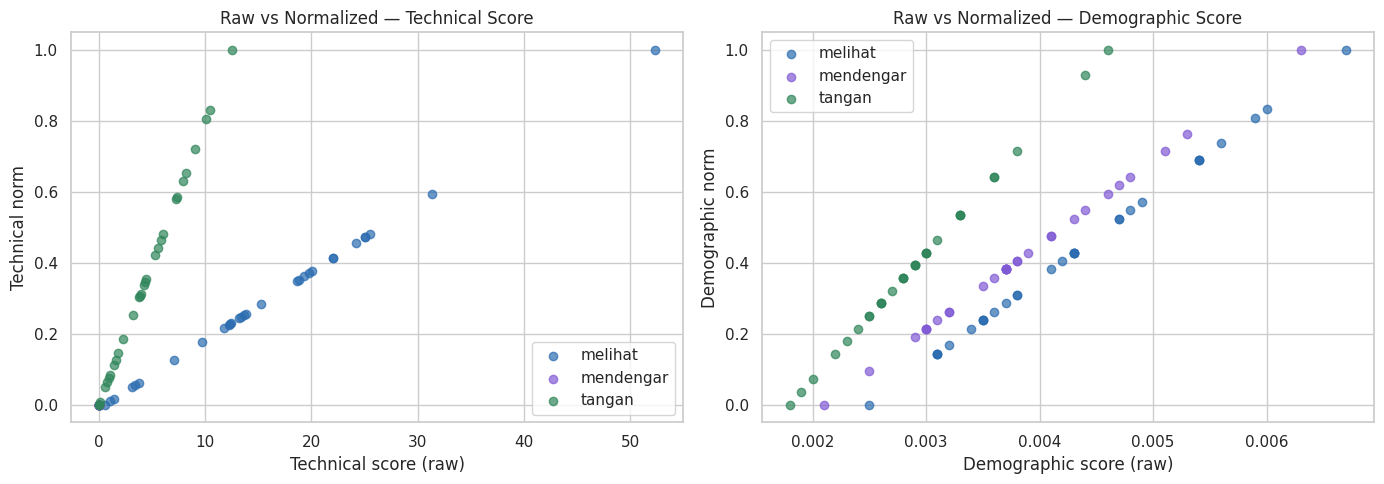

In [53]:
# --- Visualisasi perbandingan raw vs normalized ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for category, color in zip(CATEGORIES, ["#2b6cb0", "#805ad5", "#2f855a"]):
    sub = df_norm[df_norm["category"] == category]
    axes[0].scatter(sub["technical_score"], sub["technical_norm"], label=category, color=color, alpha=0.7)
    axes[1].scatter(sub["demographic_score"], sub["demographic_norm"], label=category, color=color, alpha=0.7)
axes[0].set_xlabel("Technical score (raw)"); axes[0].set_ylabel("Technical norm")
axes[0].set_title("Raw vs Normalized — Technical Score"); axes[0].legend()
axes[1].set_xlabel("Demographic score (raw)"); axes[1].set_ylabel("Demographic norm")
axes[1].set_title("Raw vs Normalized — Demographic Score"); axes[1].legend()
plt.tight_layout()
plt.savefig("fig_09_score_comparison.png", dpi=200)
plt.show()

In [54]:
from IPython.display import display, Markdown

display(Markdown(f"""### Interpretasi

**Temuan utama**
- Normalisasi min-max dilakukan terpisah per kategori (lintas {n_website} website), memastikan
  seluruh nilai `technical_norm` dan `demographic_norm` berada pada rentang [0, 1].
- Untuk kategori **mendengar**, technical_score seluruh website bernilai identik (0), sehingga
  sesuai definisi `min_max_norm` (Cell 34) technical_norm-nya didefinisikan 0 untuk seluruh
  anggota kategori tersebut — bukan hasil pembagian oleh nol.

**Perbandingan**
- Hubungan raw-vs-normalized bersifat linear monotonic per kategori (scatter plot menunjukkan
  garis lurus), sesuai sifat transformasi min-max yang mempertahankan urutan relatif nilai.

**Implikasi**
- Karena normalisasi dilakukan dalam kategori (bukan lintas kategori), skor technical_norm dan
  demographic_norm antar kategori berbeda **tidak dapat dibandingkan langsung secara nilai
  mutlak** — perbandingan yang valid adalah relatif terhadap website lain pada kategori yang
  sama.

**Catatan**
- Definisi formula normalisasi tidak diubah dari kode existing (Cell 34); enrichment ini murni
  menampilkan hasilnya secara eksplisit."""))

### Interpretasi

**Temuan utama**
- Normalisasi min-max dilakukan terpisah per kategori (lintas 30 website), memastikan
  seluruh nilai `technical_norm` dan `demographic_norm` berada pada rentang [0, 1].
- Untuk kategori **mendengar**, technical_score seluruh website bernilai identik (0), sehingga
  sesuai definisi `min_max_norm` (Cell 34) technical_norm-nya didefinisikan 0 untuk seluruh
  anggota kategori tersebut — bukan hasil pembagian oleh nol.

**Perbandingan**
- Hubungan raw-vs-normalized bersifat linear monotonic per kategori (scatter plot menunjukkan
  garis lurus), sesuai sifat transformasi min-max yang mempertahankan urutan relatif nilai.

**Implikasi**
- Karena normalisasi dilakukan dalam kategori (bukan lintas kategori), skor technical_norm dan
  demographic_norm antar kategori berbeda **tidak dapat dibandingkan langsung secara nilai
  mutlak** — perbandingan yang valid adalah relatif terhadap website lain pada kategori yang
  sama.

**Catatan**
- Definisi formula normalisasi tidak diubah dari kode existing (Cell 34); enrichment ini murni
  menampilkan hasilnya secara eksplisit.

## 9.2 Enrichment — Perbandingan Kategori Fungsional (Melihat / Mendengar / Tangan)

Membandingkan technical & demographic score (raw dan normalized) lintas tiga
kategori kesulitan fungsional yang menjadi unit analisis penelitian.

In [55]:
# --- Category Summary Table ---
df_category_summary = df_norm.groupby("category").agg(
    mean_technical=("technical_score", "mean"),
    mean_demographic=("demographic_score", "mean"),
    mean_technical_norm=("technical_norm", "mean"),
    mean_demographic_norm=("demographic_norm", "mean"),
    max_technical_norm=("technical_norm", "max"),
    min_technical_norm=("technical_norm", "min"),
).round(4)
df_category_summary

,mean_technical,mean_demographic,mean_technical_norm,mean_demographic_norm,max_technical_norm,min_technical_norm
category,,,,,,
melihat,15.7489,0.0043,0.2926,0.4270,1.0,0.0
mendengar,0.0000,0.0038,0.0000,0.4087,0.0,0.0
tangan,4.4686,0.0029,0.3557,0.3952,1.0,0.0


/tmp/ipykernel_1742/3723721697.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_norm, x="category", y="technical_norm", ax=axes[1], palette="Set3")


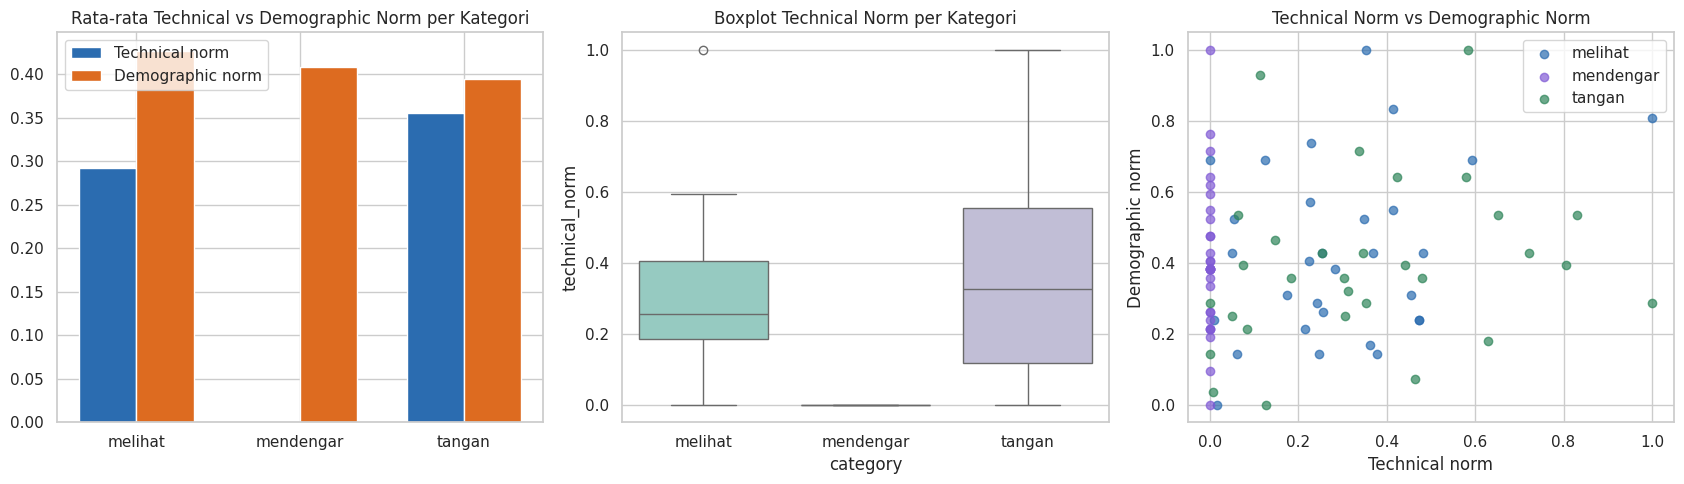

In [56]:
# --- Visualisasi: comparison bar chart, boxplot, scatter technical vs demographic ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

x = np.arange(len(CATEGORIES))
width = 0.35
axes[0].bar(x - width/2, df_category_summary["mean_technical_norm"], width, label="Technical norm", color="#2b6cb0")
axes[0].bar(x + width/2, df_category_summary["mean_demographic_norm"], width, label="Demographic norm", color="#dd6b20")
axes[0].set_xticks(x); axes[0].set_xticklabels(CATEGORIES)
axes[0].set_title("Rata-rata Technical vs Demographic Norm per Kategori")
axes[0].legend()

sns.boxplot(data=df_norm, x="category", y="technical_norm", ax=axes[1], palette="Set3")
axes[1].set_title("Boxplot Technical Norm per Kategori")

for category, color in zip(CATEGORIES, ["#2b6cb0", "#805ad5", "#2f855a"]):
    sub = df_norm[df_norm["category"] == category]
    axes[2].scatter(sub["technical_norm"], sub["demographic_norm"], label=category, color=color, alpha=0.7)
axes[2].set_xlabel("Technical norm"); axes[2].set_ylabel("Demographic norm")
axes[2].set_title("Technical Norm vs Demographic Norm")
axes[2].legend()

plt.tight_layout()
plt.savefig("fig_09b_category_comparison.png", dpi=200)
plt.show()

In [57]:
from IPython.display import display, Markdown

_cat_highest_tech = df_category_summary["mean_technical_norm"].idxmax()
_cat_highest_demo = df_category_summary["mean_demographic_norm"].idxmax()

display(Markdown(f"""### Interpretasi

**Temuan utama**
- Kategori dengan rata-rata technical_norm tertinggi: **{_cat_highest_tech}**
  ({df_category_summary.loc[_cat_highest_tech, 'mean_technical_norm']:.4f}).
- Kategori dengan rata-rata demographic_norm tertinggi: **{_cat_highest_demo}**
  ({df_category_summary.loc[_cat_highest_demo, 'mean_demographic_norm']:.4f}).

**Perbandingan**
- Kategori **mendengar** secara struktural memiliki mean_technical_norm = 0.0000 (lihat
  keterbatasan cakupan axe-core, Cell 12), sehingga posisi prioritas kategori ini pada seluruh
  skenario SAW sepenuhnya digerakkan oleh sisi demografis.

**Implikasi**
- Pola ini penting untuk pembahasan: model SAW pada kategori mendengar pada praktiknya berfungsi
  sebagai ranking murni berdasarkan prevalensi provinsi, bukan integrasi audit teknis +
  demografis seperti kategori melihat/tangan.

**Catatan**
- Keterbatasan kategori mendengar ini konsisten dengan dokumentasi pada Cell 12 dan Catatan
  Metodologi di akhir notebook — tidak dihilangkan pada enrichment ini."""))

### Interpretasi

**Temuan utama**
- Kategori dengan rata-rata technical_norm tertinggi: **tangan**
  (0.3557).
- Kategori dengan rata-rata demographic_norm tertinggi: **melihat**
  (0.4270).

**Perbandingan**
- Kategori **mendengar** secara struktural memiliki mean_technical_norm = 0.0000 (lihat
  keterbatasan cakupan axe-core, Cell 12), sehingga posisi prioritas kategori ini pada seluruh
  skenario SAW sepenuhnya digerakkan oleh sisi demografis.

**Implikasi**
- Pola ini penting untuk pembahasan: model SAW pada kategori mendengar pada praktiknya berfungsi
  sebagai ranking murni berdasarkan prevalensi provinsi, bukan integrasi audit teknis +
  demografis seperti kategori melihat/tangan.

**Catatan**
- Keterbatasan kategori mendengar ini konsisten dengan dokumentasi pada Cell 12 dan Catatan
  Metodologi di akhir notebook — tidak dihilangkan pada enrichment ini.

---

## 10. SAW (Simple Additive Weighting)

Skor akhir dihitung sebagai kombinasi linear tertimbang dari `technical_norm` dan
`demographic_norm`:

$$
\text{FinalScore}(w, c, s) = W^{\text{tech}}_s \cdot \text{TechnicalNorm}(w, c)
+ W^{\text{demo}}_s \cdot \text{DemographicNorm}(w, c)
$$

Tiga skenario bobot diuji untuk keperluan analisis sensitivitas pada tahap berikutnya:

| Skenario | $W^{\text{tech}}$ | $W^{\text{demo}}$ | Penekanan |
|---|---|---|---|
| S1 | 0.7 | 0.3 | Kondisi teknis situs |
| S2 | 0.5 | 0.5 | Seimbang |
| S3 | 0.3 | 0.7 | Kebutuhan populasi |

In [58]:
SCENARIOS = {"S1": (0.7, 0.3), "S2": (0.5, 0.5), "S3": (0.3, 0.7)}

hasil_saw = []
for nama_skenario, (w_tech, w_demo) in SCENARIOS.items():
    sub = df_norm.copy()
    sub["scenario"] = nama_skenario
    sub["final_score"] = w_tech * sub["technical_norm"] + w_demo * sub["demographic_norm"]
    hasil_saw.append(sub)

df_saw = pd.concat(hasil_saw, ignore_index=True)
df_saw[["website_id", "category", "scenario", "technical_norm", "demographic_norm", "final_score"]].head(9)

,website_id,category,scenario,technical_norm,demographic_norm,final_score
0,W01,melihat,S1,1.000000,0.809524,0.942857
1,W01,mendengar,S1,0.000000,0.380952,0.114286
2,W01,tangan,S1,0.830647,0.535714,0.742167
3,W02,melihat,S1,0.175118,0.309524,0.215440
4,W02,mendengar,S1,0.000000,0.214286,0.064286
5,W02,tangan,S1,0.304876,0.250000,0.288413
6,W03,melihat,S1,0.054477,0.523810,0.195277
7,W03,mendengar,S1,0.000000,0.523810,0.157143
8,W03,tangan,S1,0.074030,0.392857,0.169678


## 10.1 Enrichment — SAW Calculation Detail

Menampilkan komponen perhitungan SAW secara eksplisit (bobot x nilai
ternormalisasi) untuk memperjelas **bagaimana** final_score terbentuk, bukan
hanya hasil akhirnya.

In [59]:
# --- SAW Calculation Detail table (contoh lengkap 1 kategori, seluruh skenario) ---
df_saw_detail = df_saw.copy()
for skenario, (w_tech, w_demo) in SCENARIOS.items():
    mask = df_saw_detail["scenario"] == skenario
    df_saw_detail.loc[mask, "weighted_technical"] = w_tech * df_saw_detail.loc[mask, "technical_norm"]
    df_saw_detail.loc[mask, "weighted_demographic"] = w_demo * df_saw_detail.loc[mask, "demographic_norm"]

df_saw_detail["rank_preview"] = df_saw_detail.groupby(["category", "scenario"])["final_score"].rank(
    ascending=False, method="min"
).astype(int)

contoh_saw = df_saw_detail[
    (df_saw_detail["category"] == "melihat") & (df_saw_detail["website_id"].isin(
        df_website["website_id"].head(5)
    ))
].sort_values(["website_id", "scenario"])
contoh_saw[[
    "website_id", "category", "scenario", "technical_norm", "demographic_norm",
    "weighted_technical", "weighted_demographic", "final_score", "rank_preview"
]]

,website_id,category,scenario,technical_norm,demographic_norm,weighted_technical,weighted_demographic,final_score,rank_preview
0,W01,melihat,S1,1.000000,0.809524,0.700000,0.242857,0.942857,1
90,W01,melihat,S2,1.000000,0.809524,0.500000,0.404762,0.904762,1
180,W01,melihat,S3,1.000000,0.809524,0.300000,0.566667,0.866667,1
3,W02,melihat,S1,0.175118,0.309524,0.122583,0.092857,0.215440,23
93,W02,melihat,S2,0.175118,0.309524,0.087559,0.154762,0.242321,24
183,W02,melihat,S3,0.175118,0.309524,0.052535,0.216667,0.269202,22
6,W03,melihat,S1,0.054477,0.523810,0.038134,0.157143,0.195277,26
96,W03,melihat,S2,0.054477,0.523810,0.027238,0.261905,0.289143,19
186,W03,melihat,S3,0.054477,0.523810,0.016343,0.366667,0.383010,13
9,W04,melihat,S1,0.224283,0.404762,0.156998,0.121429,0.278427,19


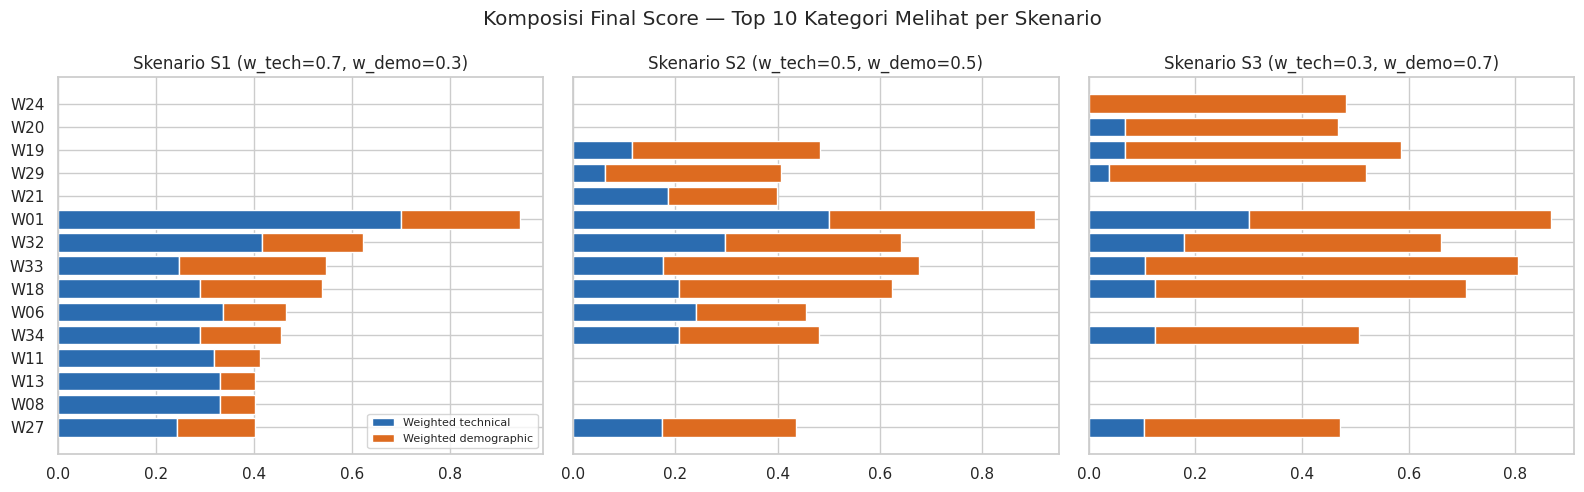

In [60]:
# --- Visualisasi: kontribusi weighted_technical vs weighted_demographic per skenario ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, skenario in zip(axes, SCENARIOS.keys()):
    sub = df_saw_detail[(df_saw_detail["category"] == "melihat") & (df_saw_detail["scenario"] == skenario)]
    sub = sub.sort_values("final_score", ascending=False).head(10).sort_values("final_score")
    ax.barh(sub["website_id"], sub["weighted_technical"], label="Weighted technical", color="#2b6cb0")
    ax.barh(sub["website_id"], sub["weighted_demographic"], left=sub["weighted_technical"],
            label="Weighted demographic", color="#dd6b20")
    ax.set_title(f"Skenario {skenario} (w_tech={SCENARIOS[skenario][0]}, w_demo={SCENARIOS[skenario][1]})")
axes[0].legend(loc="lower right", fontsize=8)
plt.suptitle("Komposisi Final Score — Top 10 Kategori Melihat per Skenario")
plt.tight_layout()
plt.savefig("fig_10_saw_ranking.png", dpi=200)
plt.show()

In [61]:
from IPython.display import display, Markdown

display(Markdown(f"""### Interpretasi

**Temuan utama**
- Tabel SAW Calculation Detail memperlihatkan bahwa `final_score` = (bobot teknis x
  technical_norm) + (bobot demografis x demographic_norm), persis mengikuti formula pada Cell 36.

**Perbandingan**
- Pada skenario S1 (w_tech=0.7), komponen weighted_technical mendominasi total final_score untuk
  website dengan technical_norm tinggi; sebaliknya pada S3 (w_demo=0.7) komponen
  weighted_demographic menjadi lebih dominan — terlihat jelas dari perubahan proporsi warna pada
  stacked bar di atas untuk website yang sama lintas ketiga panel.

**Implikasi**
- Visualisasi komposisi ini menjadi bukti langsung mengapa ranking dapat berubah antar skenario
  (dibahas lebih lanjut pada Cross-Scenario Comparison) — pergeseran bobot mengubah kontribusi
  relatif tiap komponen terhadap total skor.

**Catatan**
- Contoh tabel dan grafik dibatasi pada kategori "melihat" untuk keterbacaan; pola serupa berlaku
  untuk kategori tangan (mendengar tidak relevan karena weighted_technical selalu 0)."""))

### Interpretasi

**Temuan utama**
- Tabel SAW Calculation Detail memperlihatkan bahwa `final_score` = (bobot teknis x
  technical_norm) + (bobot demografis x demographic_norm), persis mengikuti formula pada Cell 36.

**Perbandingan**
- Pada skenario S1 (w_tech=0.7), komponen weighted_technical mendominasi total final_score untuk
  website dengan technical_norm tinggi; sebaliknya pada S3 (w_demo=0.7) komponen
  weighted_demographic menjadi lebih dominan — terlihat jelas dari perubahan proporsi warna pada
  stacked bar di atas untuk website yang sama lintas ketiga panel.

**Implikasi**
- Visualisasi komposisi ini menjadi bukti langsung mengapa ranking dapat berubah antar skenario
  (dibahas lebih lanjut pada Cross-Scenario Comparison) — pergeseran bobot mengubah kontribusi
  relatif tiap komponen terhadap total skor.

**Catatan**
- Contoh tabel dan grafik dibatasi pada kategori "melihat" untuk keterbacaan; pola serupa berlaku
  untuk kategori tangan (mendengar tidak relevan karena weighted_technical selalu 0).

---

## 11. Ranking

Perangkingan dilakukan **di dalam tiap kombinasi kategori x skenario**: peringkat 1 adalah
website dengan `final_score` tertinggi (prioritas perbaikan tertinggi).

In [62]:
df_saw["rank"] = df_saw.groupby(["category", "scenario"])["final_score"].transform(rank_desc)

df_priority = df_saw.merge(df_baseline, on=["website_id", "category"], how="left")
df_priority = df_priority.merge(
    df_website[["website_id", "institution_name", "province_name"]], on="website_id", how="left"
)

contoh = df_priority[(df_priority["category"] == "melihat") & (df_priority["scenario"] == "S2")]
contoh.sort_values("rank").head(10)[
    ["rank", "website_id", "institution_name", "province_name", "final_score",
     "technical_norm", "demographic_norm", "baseline_a_rank", "baseline_b_rank", "baseline_c_rank"]
]

,rank,website_id,institution_name,province_name,final_score,technical_norm,demographic_norm,baseline_a_rank,baseline_b_rank,baseline_c_rank
90,1,W01,Dinas Sosial Provinsi Aceh,Aceh,0.904762,1.000000,0.809524,1,1,3
174,2,W33,Dinas Sosial Provinsi Papua,Papua,0.676326,0.352651,1.000000,10,12,1
171,3,W32,Dinas Sosial Provinsi Maluku Utara,Maluku Utara,0.642157,0.593838,0.690476,2,2,5
138,4,W18,Dinas Sosial Provinsi Nusa Tenggara Barat,Nusa Tenggara Barat,0.623467,0.413600,0.833333,6,8,2
141,5,W19,Dinas Sosial Provinsi Nusa Tenggara Timur,Nusa Tenggara Timur,0.483459,0.228823,0.738095,18,19,4
177,6,W34,Dinas Sosial Provinsi Papua Barat,Papua Barat,0.480948,0.414276,0.547619,8,7,9
105,7,W06,Dinas Sosial Provinsi Sumatera Selatan,Sumatera Selatan,0.454916,0.481261,0.428571,7,3,12
162,8,W27,Dinas Sosial Provinsi Sulawesi Selatan,Sulawesi Selatan,0.436250,0.348691,0.523810,14,13,10
165,9,W29,Dinas Sosial Provinsi Gorontalo,Gorontalo,0.407539,0.124602,0.690476,24,24,5
147,10,W21,Dinas Sosial Provinsi Kalimantan Tengah,Kalimantan Tengah,0.399160,0.369748,0.428571,10,10,12


## 11.2 Enrichment — Ranking Analysis (Top 10 / Bottom 10 per Skenario)

Memperkaya `df_priority` (Cell 40) dengan tabel Top 10 / Bottom 10 untuk
setiap kombinasi kategori x skenario.

In [63]:
# --- Top 10 & Bottom 10 Priority Websites per kategori x skenario ---
top10_tables = {}
bottom10_tables = {}
for category in CATEGORIES:
    for skenario in SCENARIOS:
        sub = df_priority[(df_priority["category"] == category) & (df_priority["scenario"] == skenario)]
        sub = sub.sort_values("rank")
        top10_tables[(category, skenario)] = sub.head(10)[
            ["rank", "website_id", "institution_name", "province_name", "final_score"]
        ]
        bottom10_tables[(category, skenario)] = sub.tail(10)[
            ["rank", "website_id", "institution_name", "province_name", "final_score"]
        ]

print("Contoh — Top 10 Priority Websites (Kategori: melihat, Skenario: S2):")
display(top10_tables[("melihat", "S2")])
print("Contoh — Bottom 10 Priority Websites (Kategori: melihat, Skenario: S2):")
display(bottom10_tables[("melihat", "S2")])

Contoh — Top 10 Priority Websites (Kategori: melihat, Skenario: S2):


,rank,website_id,institution_name,province_name,final_score
90,1,W01,Dinas Sosial Provinsi Aceh,Aceh,0.904762
174,2,W33,Dinas Sosial Provinsi Papua,Papua,0.676326
171,3,W32,Dinas Sosial Provinsi Maluku Utara,Maluku Utara,0.642157
138,4,W18,Dinas Sosial Provinsi Nusa Tenggara Barat,Nusa Tenggara Barat,0.623467
141,5,W19,Dinas Sosial Provinsi Nusa Tenggara Timur,Nusa Tenggara Timur,0.483459
177,6,W34,Dinas Sosial Provinsi Papua Barat,Papua Barat,0.480948
105,7,W06,Dinas Sosial Provinsi Sumatera Selatan,Sumatera Selatan,0.454916
162,8,W27,Dinas Sosial Provinsi Sulawesi Selatan,Sulawesi Selatan,0.436250
165,9,W29,Dinas Sosial Provinsi Gorontalo,Gorontalo,0.407539
147,10,W21,Dinas Sosial Provinsi Kalimantan Tengah,Kalimantan Tengah,0.399160


Contoh — Bottom 10 Priority Websites (Kategori: melihat, Skenario: S2):


,rank,website_id,institution_name,province_name,final_score
102,21,W05,Dinas Sosial Provinsi Jambi,Jambi,0.264247
111,22,W09,Dinas Sosial Provinsi Kepulauan Bangka Belitung,Kepulauan Bangka Belitung,0.259876
159,23,W25,Dinas Sosial Provinsi Sulawesi Utara,Sulawesi Utara,0.259128
93,24,W02,Dinas Sosial Provinsi Sumatera Utara,Sumatera Utara,0.242321
126,25,W14,Dinas Sosial Provinsi Di Yogyakarta,Di Yogyakarta,0.238868
135,26,W17,Dinas Sosial Provinsi Bali,Bali,0.215034
114,27,W10,Dinas Sosial Provinsi Kepulauan Riau,Kepulauan Riau,0.195306
129,28,W15,Dinas Sosial Provinsi Jawa Timur,Jawa Timur,0.123394
120,29,W12,Dinas Sosial Provinsi Jawa Barat,Jawa Barat,0.101855
132,30,W16,Dinas Sosial Provinsi Banten,Banten,0.007727


In [64]:
# --- Statistik rank & score distribution per kategori x skenario ---
rank_score_stats = df_priority.groupby(["category", "scenario"]).agg(
    mean_final_score=("final_score", "mean"),
    median_final_score=("final_score", "median"),
    std_final_score=("final_score", "std"),
    mean_rank=("rank", "mean"),
    median_rank=("rank", "median"),
).round(4)
rank_score_stats

mean_final_score  median_final_score  std_final_score  mean_rank  median_rank
category  scenario                                                                               
melihat   S1                  0.3329              0.3063           0.1816       15.5         15.5
          S2                  0.3598              0.3431           0.1826       15.5         15.5
          S3                  0.3867              0.3524           0.1986       15.5         15.5
mendengar S1                  0.1226              0.1143           0.0624       14.8         14.0
          S2                  0.2044              0.1905           0.1040       14.8         14.0
          S3                  0.2861              0.2667           0.1456       14.8         14.0
tangan    S1                  0.3676              0.3400           0.2191       15.5         15.5
          S2                  0.3755              0.3357           0.1991       15.5         15.5
          S3                  0.3834              0.3726           0.1983       15.5         15.5

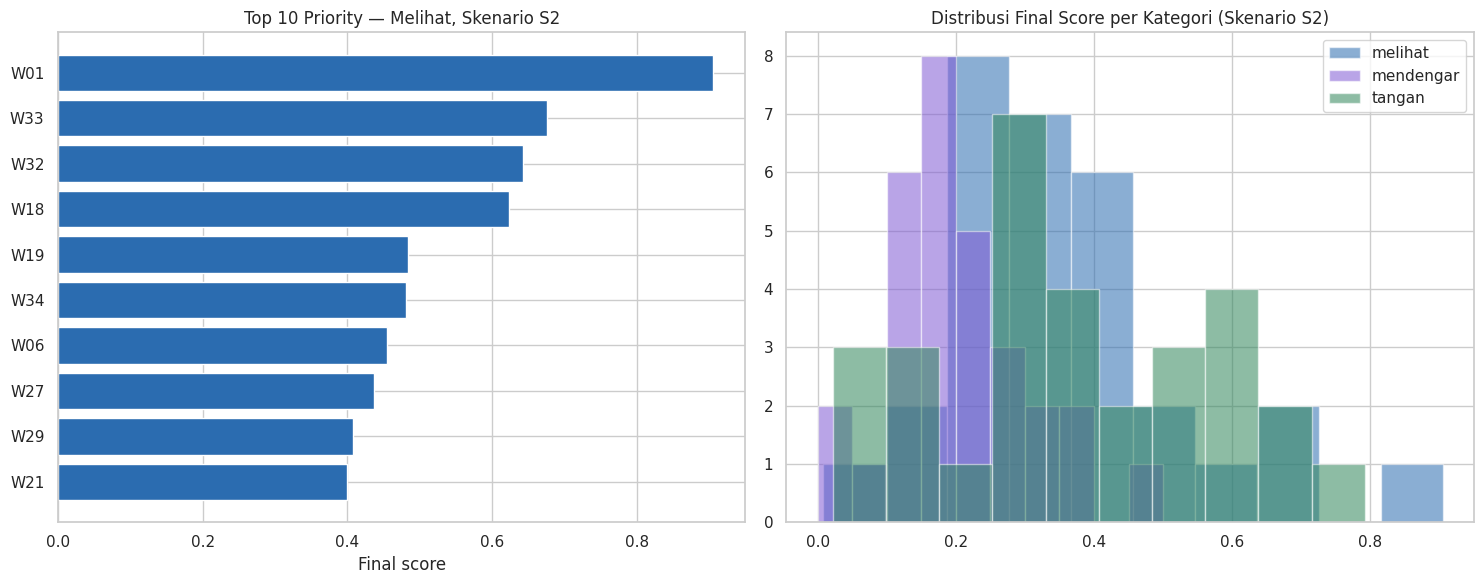

In [65]:
# --- Visualisasi: Top 10 ranking (melihat, S2) & distribusi score seluruh kategori ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top10_plot = top10_tables[("melihat", "S2")].sort_values("final_score")
axes[0].barh(top10_plot["website_id"], top10_plot["final_score"], color="#2b6cb0")
axes[0].set_title("Top 10 Priority — Melihat, Skenario S2")
axes[0].set_xlabel("Final score")

for category, color in zip(CATEGORIES, ["#2b6cb0", "#805ad5", "#2f855a"]):
    sub = df_priority[(df_priority["category"] == category) & (df_priority["scenario"] == "S2")]
    axes[1].hist(sub["final_score"], bins=10, alpha=0.55, label=category, color=color)
axes[1].set_title("Distribusi Final Score per Kategori (Skenario S2)")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_10b_top10_ranking.png", dpi=200)
plt.show()

## 11.3 Enrichment — Cross-Scenario Comparison (S1 vs S2 vs S3)

Membandingkan rank yang sama (website x kategori) di ketiga skenario bobot
untuk melihat **seberapa stabil** urutan prioritas terhadap perubahan bobot.

In [66]:
# --- Ranking Stability Comparison table ---
rank_cross = df_priority.pivot_table(
    index=["website_id", "category"], columns="scenario", values="rank"
).reset_index()
rank_cross.columns.name = None
rank_cross = rank_cross.rename(columns={"S1": "S1 Rank", "S2": "S2 Rank", "S3": "S3 Rank"})
rank_cross["Best Rank"] = rank_cross[["S1 Rank", "S2 Rank", "S3 Rank"]].min(axis=1)
rank_cross["Worst Rank"] = rank_cross[["S1 Rank", "S2 Rank", "S3 Rank"]].max(axis=1)
rank_cross["Rank Range"] = rank_cross["Worst Rank"] - rank_cross["Best Rank"]
rank_cross = rank_cross.merge(df_website[["website_id", "institution_name"]], on="website_id", how="left")
rank_cross = rank_cross.sort_values(["category", "Rank Range"], ascending=[True, False])
rank_cross[["website_id", "institution_name", "category", "S1 Rank", "S2 Rank", "S3 Rank",
            "Best Rank", "Worst Rank", "Rank Range"]].head(15)

,website_id,institution_name,category,S1 Rank,S2 Rank,S3 Rank,Best Rank,Worst Rank,Rank Range
66,W24,Dinas Sosial Provinsi Kalimantan Utara,melihat,25.0,15.0,8.0,8.0,25.0,17.0
6,W03,Dinas Sosial Provinsi Sumatera Barat,melihat,26.0,19.0,13.0,13.0,26.0,13.0
75,W29,Dinas Sosial Provinsi Gorontalo,melihat,18.0,9.0,6.0,6.0,18.0,12.0
18,W08,Dinas Sosial Provinsi Lampung,melihat,9.0,14.0,20.0,9.0,20.0,11.0
21,W09,Dinas Sosial Provinsi Kepulauan Bangka Belitung,melihat,15.0,22.0,26.0,15.0,26.0,11.0
33,W13,Dinas Sosial Provinsi Jawa Tengah,melihat,8.0,13.0,19.0,8.0,19.0,11.0
36,W14,Dinas Sosial Provinsi Di Yogyakarta,melihat,27.0,25.0,18.0,18.0,27.0,9.0
27,W11,Dinas Sosial Provinsi Dki Jakarta,melihat,7.0,12.0,15.0,7.0,15.0,8.0
12,W05,Dinas Sosial Provinsi Jambi,melihat,17.0,21.0,24.0,17.0,24.0,7.0
51,W19,Dinas Sosial Provinsi Nusa Tenggara Timur,melihat,12.0,5.0,5.0,5.0,12.0,7.0


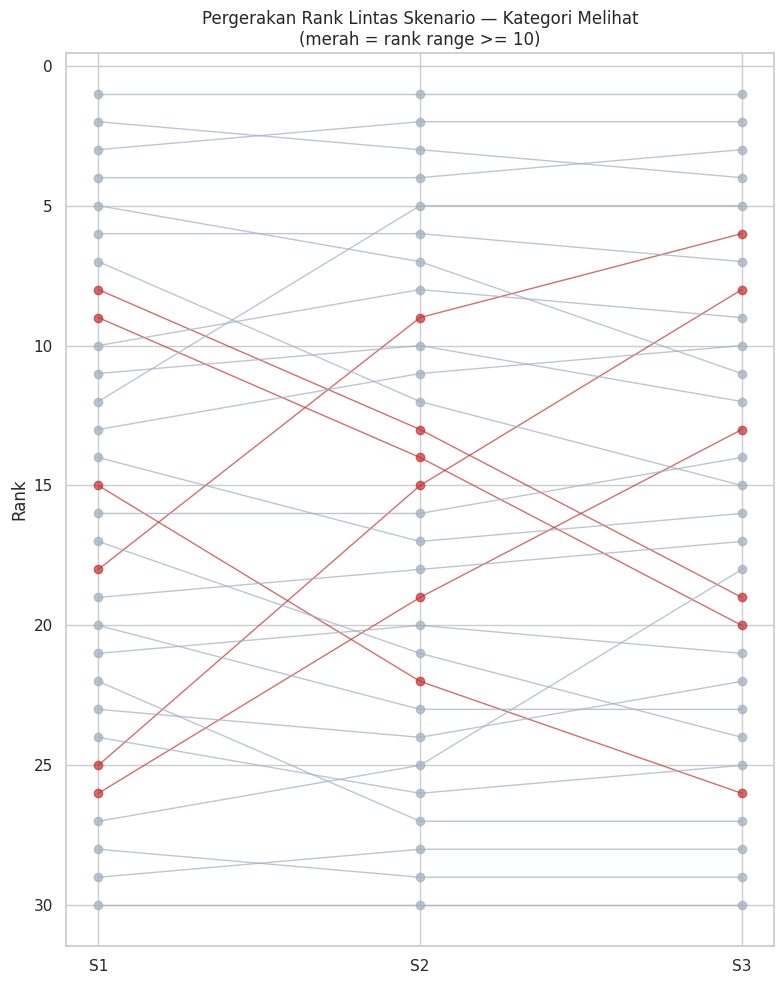

In [67]:
# --- Visualisasi: rank movement (slopegraph sederhana) untuk kategori melihat ---
fig, ax = plt.subplots(figsize=(8, 10))
sub_melihat = rank_cross[rank_cross["category"] == "melihat"]
for _, row in sub_melihat.iterrows():
    color = "#c53030" if row["Rank Range"] >= 10 else "#a0aec0"
    ax.plot(["S1", "S2", "S3"], [row["S1 Rank"], row["S2 Rank"], row["S3 Rank"]],
            marker="o", color=color, alpha=0.7, linewidth=1)
ax.invert_yaxis()
ax.set_title("Pergerakan Rank Lintas Skenario — Kategori Melihat\n(merah = rank range >= 10)")
ax.set_ylabel("Rank")
plt.tight_layout()
plt.savefig("fig_11_scenario_comparison.png", dpi=200)
plt.show()

/tmp/ipykernel_1742/2946427335.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rank_cross, x="category", y="Rank Range", ax=ax, palette="Set2")


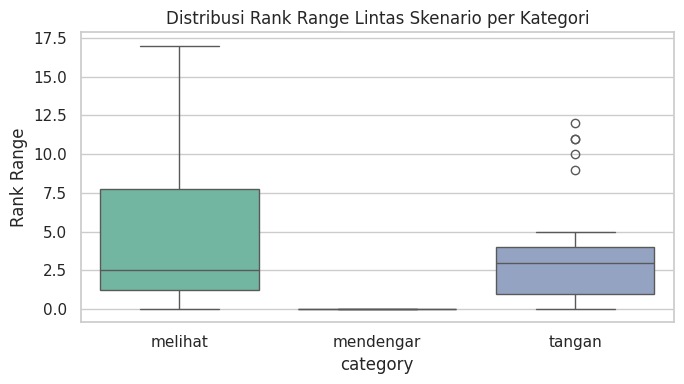

In [68]:
# --- Heatmap rank range distribution per kategori ---
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=rank_cross, x="category", y="Rank Range", ax=ax, palette="Set2")
ax.set_title("Distribusi Rank Range Lintas Skenario per Kategori")
plt.tight_layout()
plt.savefig("fig_12_ranking_stability.png", dpi=200)
plt.show()

In [69]:
from IPython.display import display, Markdown

_most_volatile = rank_cross.sort_values("Rank Range", ascending=False).iloc[0]
_most_stable = rank_cross.sort_values("Rank Range", ascending=True).iloc[0]

display(Markdown(f"""### Interpretasi

**Temuan utama**
- Website dengan rank range terbesar (paling berubah antar skenario) adalah
  **{_most_volatile['website_id']}** kategori {_most_volatile['category']}, bergerak dari rank
  {int(_most_volatile['Best Rank'])} sampai {int(_most_volatile['Worst Rank'])}
  (range={int(_most_volatile['Rank Range'])}).
- Sebaliknya, {_most_stable['website_id']} kategori {_most_stable['category']} memiliki rank
  range={int(_most_stable['Rank Range'])} — praktis tidak berubah lintas ketiga skenario.

**Perbandingan**
- Rata-rata rank range per kategori: {', '.join(f"{c}={rank_cross.loc[rank_cross['category']==c, 'Rank Range'].mean():.2f}" for c in CATEGORIES)}.

**Implikasi**
- Website dengan rank range besar adalah kandidat yang layak dibahas secara khusus di Bab
  Pembahasan sebagai kasus di mana pilihan bobot kebijakan (menekankan sisi teknis vs. populasi)
  benar-benar mengubah keputusan prioritisasi.

**Catatan**
- Rank Range di sini dihitung dari `df_priority` langsung (bukan hasil rank_wide pada Sensitivity
  Analysis) sebagai cross-check independen; definisi status kestabilan resmi tetap memakai
  metode Top-3-frequency pada Cell 46, tidak diganti."""))

### Interpretasi

**Temuan utama**
- Website dengan rank range terbesar (paling berubah antar skenario) adalah
  **W24** kategori melihat, bergerak dari rank
  8 sampai 25
  (range=17).
- Sebaliknya, W02 kategori mendengar memiliki rank
  range=0 — praktis tidak berubah lintas ketiga skenario.

**Perbandingan**
- Rata-rata rank range per kategori: melihat=4.87, mendengar=0.00, tangan=3.73.

**Implikasi**
- Website dengan rank range besar adalah kandidat yang layak dibahas secara khusus di Bab
  Pembahasan sebagai kasus di mana pilihan bobot kebijakan (menekankan sisi teknis vs. populasi)
  benar-benar mengubah keputusan prioritisasi.

**Catatan**
- Rank Range di sini dihitung dari `df_priority` langsung (bukan hasil rank_wide pada Sensitivity
  Analysis) sebagai cross-check independen; definisi status kestabilan resmi tetap memakai
  metode Top-3-frequency pada Cell 46, tidak diganti.

### 11.1 Uji Statistik: Model Usulan vs Tiga Baseline

Sesuai Logbook Koding Tahap 4, Langkah 13: korelasi peringkat antara Model Usulan (`rank` hasil
SAW) dan tiap baseline (A/B/C) dihitung memakai **Spearman Rank Correlation (ρ)** beserta
p-value analitik (`scipy.stats.spearmanr`, taraf signifikansi α = 0,05 — korelasi hanya
dinyatakan berbeda signifikan bila p < 0,05), dilengkapi **Kendall's Tau** sebagai cek silang,
serta **Mean Absolute Rank Shift** (rata-rata selisih posisi rank absolut) terhadap tiap
baseline. Perhitungan dilakukan per kombinasi kategori x skenario agar konsisten dengan struktur
`priority_results`.

In [70]:
# 11.1 Uji Statistik: Model Usulan vs Baseline A/B/C
from scipy.stats import spearmanr, kendalltau

BASELINE_COLS = {"Baseline A": "baseline_a_rank", "Baseline B": "baseline_b_rank", "Baseline C": "baseline_c_rank"}

baseline_stat_rows = []
for category in CATEGORIES:
    for scenario in SCENARIOS:
        sub = df_priority[(df_priority["category"] == category) & (df_priority["scenario"] == scenario)]
        for baseline_name, baseline_col in BASELINE_COLS.items():
            rho, p_spearman = spearmanr(sub["rank"], sub[baseline_col])
            tau, p_kendall = kendalltau(sub["rank"], sub[baseline_col])
            mean_abs_shift = (sub["rank"] - sub[baseline_col]).abs().mean()
            baseline_stat_rows.append({
                "category": category,
                "scenario": scenario,
                "baseline": baseline_name,
                "spearman_rho": rho,
                "spearman_p": p_spearman,
                "signifikan_p<0.05": bool(p_spearman < 0.05),
                "kendall_tau": tau,
                "kendall_p": p_kendall,
                "mean_abs_rank_shift": mean_abs_shift,
            })

df_baseline_stats = pd.DataFrame(baseline_stat_rows)
df_baseline_stats.to_csv("baseline_comparison_stats.csv", index=False)
print(
    f"baseline_comparison_stats.csv tersimpan -> {df_baseline_stats.shape[0]} baris "
    f"({len(CATEGORIES)} kategori x {len(SCENARIOS)} skenario x {len(BASELINE_COLS)} baseline)"
)
df_baseline_stats.round(4)

baseline_comparison_stats.csv tersimpan -> 27 baris (3 kategori x 3 skenario x 3 baseline)


/tmp/ipykernel_1742/3326029615.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p_spearman = spearmanr(sub["rank"], sub[baseline_col])
/tmp/ipykernel_1742/3326029615.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p_spearman = spearmanr(sub["rank"], sub[baseline_col])
/tmp/ipykernel_1742/3326029615.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p_spearman = spearmanr(sub["rank"], sub[baseline_col])
/tmp/ipykernel_1742/3326029615.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p_spearman = spearmanr(sub["rank"], sub[baseline_col])
/tmp/ipykernel_1742/3326029615.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p_spearman = spearmanr(sub["rank"], sub[baseline_col])
/tmp/ipykernel_1742/3326029615

,category,scenario,baseline,spearman_rho,spearman_p,signifikan_p<0.05,kendall_tau,kendall_p,mean_abs_rank_shift
0,melihat,S1,Baseline A,0.8647,0.0000,True,0.7028,0.0000,3.5333
1,melihat,S1,Baseline B,0.8986,0.0000,True,0.7241,0.0000,2.9333
2,melihat,S1,Baseline C,0.5416,0.0020,True,0.4034,0.0021,6.2333
3,melihat,S2,Baseline A,0.6068,0.0004,True,0.4493,0.0005,5.7333
4,melihat,S2,Baseline B,0.6374,0.0002,True,0.4621,0.0002,5.7333
5,melihat,S2,Baseline C,0.8329,0.0000,True,0.6707,0.0000,3.8333
6,melihat,S3,Baseline A,0.3518,0.0566,False,0.2650,0.0401,7.4667
7,melihat,S3,Baseline B,0.3806,0.0380,True,0.2782,0.0314,7.5333
8,melihat,S3,Baseline C,0.9661,0.0000,True,0.8583,0.0000,1.8333
9,mendengar,S1,Baseline A,NaN,NaN,False,NaN,NaN,13.8000


In [71]:
# Ringkasan lintas kategori & skenario (untuk dikutip di naskah)
ringkasan_baseline = df_baseline_stats.groupby("baseline")[
    ["spearman_rho", "mean_abs_rank_shift"]
].mean().round(3)
ringkasan_baseline["proporsi_signifikan_p<0.05"] = df_baseline_stats.groupby("baseline")[
    "signifikan_p<0.05"
].mean().round(3)
ringkasan_baseline

,spearman_rho,mean_abs_rank_shift,proporsi_signifikan_p<0.05
baseline,,,
Baseline A,0.713,7.652,0.556
Baseline B,0.725,7.641,0.667
Baseline C,0.834,2.859,1.000


## 11.4 Enrichment — Baseline Agreement & Divergence

Memperdalam `df_baseline_stats` (Cell 42) dengan identifikasi website yang
ranking-nya konsisten vs. berubah signifikan terhadap tiap baseline.

In [72]:
# --- Website paling konsisten vs paling divergen terhadap baseline (skenario S2) ---
baseline_divergence = df_priority[df_priority["scenario"] == "S2"].copy()
baseline_divergence["abs_shift_a"] = (baseline_divergence["rank"] - baseline_divergence["baseline_a_rank"]).abs()
baseline_divergence["abs_shift_b"] = (baseline_divergence["rank"] - baseline_divergence["baseline_b_rank"]).abs()
baseline_divergence["abs_shift_c"] = (baseline_divergence["rank"] - baseline_divergence["baseline_c_rank"]).abs()
baseline_divergence["mean_shift"] = baseline_divergence[["abs_shift_a", "abs_shift_b", "abs_shift_c"]].mean(axis=1)

cols_show = ["website_id", "institution_name", "category", "rank",
             "baseline_a_rank", "baseline_b_rank", "baseline_c_rank", "mean_shift"]
print("Top 10 website paling KONSISTEN dengan baseline (mean_shift terkecil), skenario S2:")
display(baseline_divergence.sort_values("mean_shift").head(10)[cols_show])
print("Top 10 website PALING DIVERGEN dari baseline (mean_shift terbesar), skenario S2:")
display(baseline_divergence.sort_values("mean_shift", ascending=False).head(10)[cols_show])

Top 10 website paling KONSISTEN dengan baseline (mean_shift terkecil), skenario S2:


,website_id,institution_name,category,rank,baseline_a_rank,baseline_b_rank,baseline_c_rank,mean_shift
175,W33,Dinas Sosial Provinsi Papua,mendengar,1,1,1,1,0.000000
90,W01,Dinas Sosial Provinsi Aceh,melihat,1,1,1,3,0.666667
147,W21,Dinas Sosial Provinsi Kalimantan Tengah,melihat,10,10,10,12,0.666667
127,W14,Dinas Sosial Provinsi Di Yogyakarta,mendengar,2,1,1,2,0.666667
152,W22,Dinas Sosial Provinsi Kalimantan Selatan,tangan,16,17,18,16,1.000000
101,W04,Dinas Sosial Provinsi Riau,tangan,12,11,11,13,1.000000
158,W24,Dinas Sosial Provinsi Kalimantan Utara,tangan,28,29,29,27,1.000000
125,W13,Dinas Sosial Provinsi Jawa Tengah,tangan,4,4,8,4,1.333333
132,W16,Dinas Sosial Provinsi Banten,melihat,30,28,28,30,1.333333
171,W32,Dinas Sosial Provinsi Maluku Utara,melihat,3,2,2,5,1.333333


Top 10 website PALING DIVERGEN dari baseline (mean_shift terbesar), skenario S2:


,website_id,institution_name,category,rank,baseline_a_rank,baseline_b_rank,baseline_c_rank,mean_shift
115,W10,Dinas Sosial Provinsi Kepulauan Riau,mendengar,30,1,1,30,19.333333
133,W16,Dinas Sosial Provinsi Banten,mendengar,29,1,1,29,18.666667
121,W12,Dinas Sosial Provinsi Jawa Barat,mendengar,28,1,1,28,18.000000
151,W22,Dinas Sosial Provinsi Kalimantan Selatan,mendengar,25,1,1,25,16.000000
103,W05,Dinas Sosial Provinsi Jambi,mendengar,25,1,1,25,16.000000
94,W02,Dinas Sosial Provinsi Sumatera Utara,mendengar,25,1,1,25,16.000000
100,W04,Dinas Sosial Provinsi Riau,mendengar,24,1,1,24,15.333333
148,W21,Dinas Sosial Provinsi Kalimantan Tengah,mendengar,22,1,1,22,14.000000
169,W31,Dinas Sosial Provinsi Maluku,mendengar,22,1,1,22,14.000000
112,W09,Dinas Sosial Provinsi Kepulauan Bangka Belitung,mendengar,21,1,1,21,13.333333


In [73]:
from IPython.display import display, Markdown

_agreement_summary = df_baseline_stats.groupby("baseline")["spearman_rho"].mean().round(3)
_most_divergent_row = baseline_divergence.sort_values("mean_shift", ascending=False).iloc[0]

display(Markdown(f"""### Interpretasi

**Temuan utama**
- Rata-rata korelasi Spearman model usulan terhadap tiap baseline (lintas kategori & skenario):
  {', '.join(f"{b}={v}" for b, v in _agreement_summary.items())}.
- Website dengan pergeseran rank rata-rata terbesar terhadap ketiga baseline (skenario S2) adalah
  **{_most_divergent_row['website_id']}** kategori {_most_divergent_row['category']}
  (mean_shift={_most_divergent_row['mean_shift']:.2f} posisi).

**Perbandingan**
- Baseline dengan korelasi tertinggi terhadap model usulan adalah
  **{_agreement_summary.idxmax()}** ({_agreement_summary.max()}), mengindikasikan komponen
  tersebut memiliki kontribusi relatif besar terhadap hasil akhir SAW.

**Implikasi**
- Website yang paling divergen dari seluruh baseline adalah kandidat kuat untuk dibahas sebagai
  bukti *nilai tambah* integrasi teknis+demografis: ranking-nya tidak dapat dijelaskan hanya dari
  satu sumber informasi saja.

**Catatan**
- Perhitungan ini tidak mengganti metrik `spearman_rho`/`kendall_tau`/`mean_abs_rank_shift` yang
  sudah dihitung resmi pada Cell 42; ini adalah drill-down tambahan pada level website individual
  untuk skenario S2 sebagai representasi skenario seimbang."""))

### Interpretasi

**Temuan utama**
- Rata-rata korelasi Spearman model usulan terhadap tiap baseline (lintas kategori & skenario):
  Baseline A=0.713, Baseline B=0.725, Baseline C=0.834.
- Website dengan pergeseran rank rata-rata terbesar terhadap ketiga baseline (skenario S2) adalah
  **W10** kategori mendengar
  (mean_shift=19.33 posisi).

**Perbandingan**
- Baseline dengan korelasi tertinggi terhadap model usulan adalah
  **Baseline C** (0.834), mengindikasikan komponen
  tersebut memiliki kontribusi relatif besar terhadap hasil akhir SAW.

**Implikasi**
- Website yang paling divergen dari seluruh baseline adalah kandidat kuat untuk dibahas sebagai
  bukti *nilai tambah* integrasi teknis+demografis: ranking-nya tidak dapat dijelaskan hanya dari
  satu sumber informasi saja.

**Catatan**
- Perhitungan ini tidak mengganti metrik `spearman_rho`/`kendall_tau`/`mean_abs_rank_shift` yang
  sudah dihitung resmi pada Cell 42; ini adalah drill-down tambahan pada level website individual
  untuk skenario S2 sebagai representasi skenario seimbang.

---

## 12. Sensitivity Analysis

Untuk tiap (website, kategori), kemunculan pada Top-3 peringkat pada ketiga skenario bobot
dibandingkan. Website yang konsisten masuk Top-3 di seluruh skenario menandakan prioritasnya
**tidak bergantung pada pilihan bobot** — sebaliknya, website yang jarang/tidak pernah masuk
Top-3 menandakan hasil yang sensitif terhadap preferensi pengambil kebijakan (menekankan kondisi
teknis vs. kebutuhan populasi). Definisi ini mengikuti Logbook Koding Tahap 4, Langkah 13.

$$
\text{Top3Count}(w, c) = \sum_{s \in \{S1,S2,S3\}} \mathbb{1}[\text{Rank}(w,c,s) \le 3]
$$

$$
\text{StabilityStatus}(w, c) =
\begin{cases}
\text{Robust} & \text{jika } \text{Top3Count}(w,c) = 3 \\
\text{Cukup stabil} & \text{jika } \text{Top3Count}(w,c) = 2 \\
\text{Sensitif} & \text{jika } \text{Top3Count}(w,c) \le 1
\end{cases}
$$

In [74]:
# Sensitivity Analysis — Top-3-frequency (Logbook Koding Tahap 4, Langkah 13)
rank_wide = df_saw.pivot_table(
    index=["website_id", "category"],
    columns="scenario",
    values="rank",
).reset_index()

# Hitung berapa kali (dari 3 skenario) tiap (website, kategori) masuk Top-3 peringkat.
scenario_cols = list(SCENARIOS.keys())
rank_wide["top3_count"] = (rank_wide[scenario_cols] <= 3).sum(axis=1)

# Tetap simpan rank_range untuk keperluan diagnostik/pembanding, meski tidak lagi
# menjadi basis status kestabilan final.
rank_wide["rank_range"] = (
    rank_wide[scenario_cols].max(axis=1) - rank_wide[scenario_cols].min(axis=1)
)

STABILITY_LABELS = {3: "Robust", 2: "Cukup stabil", 1: "Sensitif", 0: "Sensitif"}
rank_wide["stability_status"] = rank_wide["top3_count"].map(STABILITY_LABELS)

print(rank_wide["stability_status"].value_counts())
rank_wide.sort_values(["top3_count", "rank_range"], ascending=[True, False]).head(8)


stability_status
Sensitif        81
Robust           7
Cukup stabil     2
Name: count, dtype: int64


scenario,website_id,category,S1,S2,S3,top3_count,rank_range,stability_status
66,W24,melihat,25.0,15.0,8.0,0,17.0,Sensitif
6,W03,melihat,26.0,19.0,13.0,0,13.0,Sensitif
75,W29,melihat,18.0,9.0,6.0,0,12.0,Sensitif
14,W05,tangan,8.0,13.0,19.0,0,11.0,Sensitif
18,W08,melihat,9.0,14.0,20.0,0,11.0,Sensitif
21,W09,melihat,15.0,22.0,26.0,0,11.0,Sensitif
33,W13,melihat,8.0,13.0,19.0,0,11.0,Sensitif
80,W31,tangan,15.0,23.0,26.0,0,11.0,Sensitif


## 12.1 Enrichment — Sensitivity Analysis: Stability Summary & Extremes

Memperkaya `rank_wide` (Cell 46) dengan tabel ringkasan status kestabilan per
kategori dan daftar website paling stabil / paling sensitif.

In [75]:
# --- Stability Summary table ---
df_stability_summary = (
    rank_wide.groupby(["category", "stability_status"]).size()
    .unstack(fill_value=0)
    .reindex(columns=["Robust", "Cukup stabil", "Sensitif"], fill_value=0)
)
df_stability_summary["Total"] = df_stability_summary.sum(axis=1)
df_stability_summary

stability_status,Robust,Cukup stabil,Sensitif,Total
category,,,,
melihat,2,1,27,30
mendengar,3,0,27,30
tangan,2,1,27,30


In [76]:
# --- Persentase status kestabilan per kategori ---
df_stability_pct = df_stability_summary[["Robust", "Cukup stabil", "Sensitif"]].div(
    df_stability_summary["Total"], axis=0
) * 100
df_stability_pct.round(2)

stability_status,Robust,Cukup stabil,Sensitif
category,,,
melihat,6.67,3.33,90.0
mendengar,10.00,0.00,90.0
tangan,6.67,3.33,90.0


In [77]:
# --- Most Stable & Most Sensitive Websites ---
rank_wide_named = rank_wide.merge(df_website[["website_id", "institution_name"]], on="website_id", how="left")

print("Most Stable Websites (top3_count=3, Robust):")
display(rank_wide_named[rank_wide_named["stability_status"] == "Robust"][
    ["website_id", "institution_name", "category", "top3_count", "rank_range"]
].sort_values("rank_range").head(10))

print("Most Sensitive Websites (top3_count<=1, rank_range terbesar):")
display(rank_wide_named[rank_wide_named["stability_status"] == "Sensitif"][
    ["website_id", "institution_name", "category", "top3_count", "rank_range"]
].sort_values("rank_range", ascending=False).head(10))

Most Stable Websites (top3_count=3, Robust):


,website_id,institution_name,category,top3_count,rank_range
0,W01,Dinas Sosial Provinsi Aceh,melihat,3,0.0
37,W14,Dinas Sosial Provinsi Di Yogyakarta,mendengar,3,0.0
52,W19,Dinas Sosial Provinsi Nusa Tenggara Timur,mendengar,3,0.0
85,W33,Dinas Sosial Provinsi Papua,mendengar,3,0.0
2,W01,Dinas Sosial Provinsi Aceh,tangan,3,1.0
84,W33,Dinas Sosial Provinsi Papua,melihat,3,1.0
86,W33,Dinas Sosial Provinsi Papua,tangan,3,2.0


Most Sensitive Websites (top3_count<=1, rank_range terbesar):


,website_id,institution_name,category,top3_count,rank_range
66,W24,Dinas Sosial Provinsi Kalimantan Utara,melihat,0,17.0
6,W03,Dinas Sosial Provinsi Sumatera Barat,melihat,0,13.0
38,W14,Dinas Sosial Provinsi Di Yogyakarta,tangan,1,12.0
75,W29,Dinas Sosial Provinsi Gorontalo,melihat,0,12.0
18,W08,Dinas Sosial Provinsi Lampung,melihat,0,11.0
21,W09,Dinas Sosial Provinsi Kepulauan Bangka Belitung,melihat,0,11.0
14,W05,Dinas Sosial Provinsi Jambi,tangan,0,11.0
80,W31,Dinas Sosial Provinsi Maluku,tangan,0,11.0
33,W13,Dinas Sosial Provinsi Jawa Tengah,melihat,0,11.0
41,W15,Dinas Sosial Provinsi Jawa Timur,tangan,0,10.0


/tmp/ipykernel_1742/3803870914.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rank_wide, x="category", y="rank_range", ax=axes[2], palette="Set2")


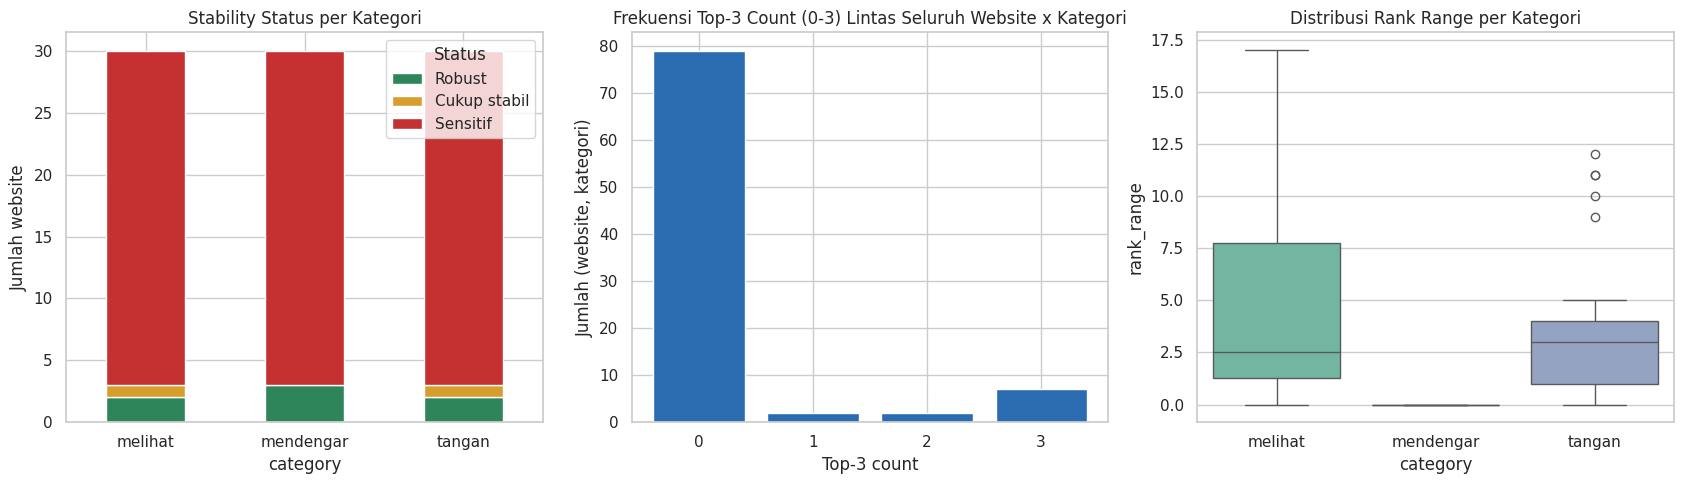

In [78]:
# --- Visualisasi: stacked bar stability, top-3 frequency, rank range distribution ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

df_stability_summary[["Robust", "Cukup stabil", "Sensitif"]].plot(
    kind="bar", stacked=True, ax=axes[0], color=["#2f855a", "#d69e2e", "#c53030"]
)
axes[0].set_title("Stability Status per Kategori")
axes[0].set_ylabel("Jumlah website")
axes[0].legend(title="Status")
axes[0].tick_params(axis="x", rotation=0)

top3_freq = rank_wide["top3_count"].value_counts().sort_index()
axes[1].bar(top3_freq.index.astype(str), top3_freq.values, color="#2b6cb0")
axes[1].set_title("Frekuensi Top-3 Count (0-3) Lintas Seluruh Website x Kategori")
axes[1].set_xlabel("Top-3 count")
axes[1].set_ylabel("Jumlah (website, kategori)")

sns.boxplot(data=rank_wide, x="category", y="rank_range", ax=axes[2], palette="Set2")
axes[2].set_title("Distribusi Rank Range per Kategori")

plt.tight_layout()
plt.savefig("fig_13_sensitivity_analysis.png", dpi=200)
plt.show()

In [79]:
from IPython.display import display, Markdown

_pct_robust_overall = (rank_wide["stability_status"] == "Robust").mean() * 100
_pct_sensitif_overall = (rank_wide["stability_status"] == "Sensitif").mean() * 100

display(Markdown(f"""### Interpretasi

**Temuan utama**
- Secara keseluruhan, {_pct_robust_overall:.1f}% dari seluruh kombinasi (website, kategori)
  berstatus **Robust** dan {_pct_sensitif_overall:.1f}% berstatus **Sensitif** terhadap perubahan
  bobot skenario.
- Kategori dengan proporsi Robust tertinggi:
  **{df_stability_pct['Robust'].idxmax()}** ({df_stability_pct['Robust'].max():.1f}%).

**Perbandingan**
- Jumlah website Robust per kategori: {', '.join(f"{c}={df_stability_summary.loc[c, 'Robust']}" for c in CATEGORIES)}
  dari total {n_website} website per kategori.

**Implikasi**
- Website berstatus Robust dapat direkomendasikan sebagai prioritas perbaikan tanpa perlu
  menunggu konsensus bobot kebijakan, karena posisinya konsisten di Top-3 pada seluruh skenario
  yang diuji. Sebaliknya, website Sensitif memerlukan diskusi kebijakan eksplisit mengenai bobot
  yang akan dipakai sebelum keputusan prioritisasi diambil.

**Catatan**
- Definisi status kestabilan (Top-3-frequency) tidak diubah dari Cell 46; enrichment ini hanya
  meringkas dan memvisualisasikan hasil yang sudah dihitung."""))

### Interpretasi

**Temuan utama**
- Secara keseluruhan, 7.8% dari seluruh kombinasi (website, kategori)
  berstatus **Robust** dan 90.0% berstatus **Sensitif** terhadap perubahan
  bobot skenario.
- Kategori dengan proporsi Robust tertinggi:
  **mendengar** (10.0%).

**Perbandingan**
- Jumlah website Robust per kategori: melihat=2, mendengar=3, tangan=2
  dari total 30 website per kategori.

**Implikasi**
- Website berstatus Robust dapat direkomendasikan sebagai prioritas perbaikan tanpa perlu
  menunggu konsensus bobot kebijakan, karena posisinya konsisten di Top-3 pada seluruh skenario
  yang diuji. Sebaliknya, website Sensitif memerlukan diskusi kebijakan eksplisit mengenai bobot
  yang akan dipakai sebelum keputusan prioritisasi diambil.

**Catatan**
- Definisi status kestabilan (Top-3-frequency) tidak diubah dari Cell 46; enrichment ini hanya
  meringkas dan memvisualisasikan hasil yang sudah dihitung.

---

## 13. Explainability

Sebagai bentuk transparansi model (bukan Explainable AI, melainkan penelusuran kontribusi skor
secara langsung), tiga Success Criterion WCAG dengan kontribusi terbesar terhadap
`technical_score` ditampilkan untuk tiap (website, kategori):

$$
\text{Kontribusi}(w, c, sc) = \sum_{i \,\in\, \text{relevan}(w,c,sc)}
\text{ImpactWeight}(\text{impact\_label}_i) \times \text{MappingValue}(sc, c)
$$

diambil 3 nilai `wcag_sc` dengan kontribusi tertinggi (`top_issue_1/2/3`); diisi `"-"` bila
kontribusi relevan yang tersedia kurang dari 3.

In [80]:
def top_issues(df_int):
    relevan = df_int[df_int["mapping_value"] > 0].copy()
    relevan["kontribusi"] = relevan["impact_weight"] * relevan["mapping_value"]

    agg = (
        relevan.groupby(["website_id", "category", "wcag_sc"])["kontribusi"]
        .sum()
        .reset_index()
        .sort_values(
            ["website_id", "category", "kontribusi"],
            ascending=[True, True, False],
        )
    )

    hasil = []
    for (website_id, category), group in agg.groupby(
        ["website_id", "category"]
    ):
        top3 = group["wcag_sc"].tolist()[:3]
        top3 += ["-"] * (3 - len(top3))
        hasil.append(
            {
                "website_id": website_id,
                "category": category,
                "top_issue_1": top3[0],
                "top_issue_2": top3[1],
                "top_issue_3": top3[2],
            }
        )

    index_lengkap = pd.MultiIndex.from_product(
        [df_website["website_id"], CATEGORIES],
        names=["website_id", "category"],
    )

    return (
        pd.DataFrame(hasil)
        .set_index(["website_id", "category"])
        .reindex(index_lengkap, fill_value="-")
        .reset_index()
    )


def top_issue_affected_pages(df_int, df_top, df_pages):
    """Menyusun tabel Top 3 Issue beserta page_id dan page_url terdampak."""
    page_lookup = df_pages[
        ["page_id", "website_id", "page_url"]
    ].drop_duplicates()

    records = []
    for row in df_top.itertuples(index=False):
        for issue_rank, column in enumerate(
            ["top_issue_1", "top_issue_2", "top_issue_3"],
            start=1,
        ):
            wcag_sc = getattr(row, column)
            if wcag_sc == "-":
                continue

            affected = df_int[
                (df_int["website_id"] == row.website_id)
                & (df_int["category"] == row.category)
                & (df_int["wcag_sc"] == wcag_sc)
                & (df_int["mapping_value"] > 0)
            ][["website_id", "category", "wcag_sc", "page_id"]].drop_duplicates()

            affected = affected.merge(
                page_lookup,
                on=["website_id", "page_id"],
                how="left",
                validate="many_to_one",
            )

            affected["issue_rank"] = issue_rank
            records.append(
                affected[
                    [
                        "website_id",
                        "category",
                        "issue_rank",
                        "wcag_sc",
                        "page_id",
                        "page_url",
                    ]
                ]
            )

    if not records:
        return pd.DataFrame(
            columns=[
                "website_id",
                "category",
                "issue_rank",
                "wcag_sc",
                "page_id",
                "page_url",
            ]
        )

    return (
        pd.concat(records, ignore_index=True)
        .drop_duplicates()
        .sort_values(
            ["website_id", "category", "issue_rank", "page_id"]
        )
        .reset_index(drop=True)
    )


df_top_issues = top_issues(df_integrated)

df_top_issue_pages = top_issue_affected_pages(
    df_integrated,
    df_top_issues,
    df_page,
)
df_top_issue_pages.to_csv(
    "top_issue_affected_pages.csv",
    index=False,
)

print(
    "top_issue_affected_pages.csv tersimpan -> "
    f"{len(df_top_issue_pages)} baris"
)
df_top_issues[df_top_issues["category"] == "melihat"].head(8)

top_issue_affected_pages.csv tersimpan -> 595 baris


,website_id,category,top_issue_1,top_issue_2,top_issue_3
0,W01,melihat,1.4.3,1.1.1,2.4.4
3,W02,melihat,4.1.2,1.4.3,2.4.4
6,W03,melihat,1.4.3,4.1.2,2.4.4
9,W04,melihat,4.1.2,2.4.4,1.4.3
12,W05,melihat,4.1.2,2.4.4,1.1.1
15,W06,melihat,4.1.2,1.4.3,2.4.4
18,W08,melihat,1.1.1,1.4.3,4.1.2
21,W09,melihat,2.4.4,4.1.2,1.1.1


### 13.1 Explainability Check — Drill-down Rank Tertinggi & Terendah

Sesuai Logbook Koding Tahap 4, Langkah 12: setiap peringkat harus dapat dipertanggungjawabkan
melalui penelusuran balik **Ranking Final → Skor Akhir SAW → Skor Teknis & Demografis → Top
Issues (SC) WCAG → Rule ID → Halaman & CSS Selector**. Untuk tiap kategori, diambil contoh
website peringkat tertinggi (Rank 1) dan terendah pada skenario seimbang (S2), lalu ditelusuri
apakah posisinya beralasan secara logis (mis. FailureRate tinggi pada SC dominan, dan/atau
prevalensi demografis tinggi di provinsi tersebut).

In [81]:
# 13.1 Explainability Check — Drill-down Rank 1 & Rank Terendah per Kategori
df_drilldown_source = df_priority.merge(df_top_issues, on=["website_id", "category"], how="left")


def drilldown(website_id, category, scenario="S2"):
    row = df_drilldown_source[
        (df_drilldown_source["website_id"] == website_id)
        & (df_drilldown_source["category"] == category)
        & (df_drilldown_source["scenario"] == scenario)
    ].iloc[0]

    top_scs = [v for v in [row["top_issue_1"], row["top_issue_2"], row["top_issue_3"]] if v != "-"]
    detail = df_integrated[
        (df_integrated["website_id"] == website_id)
        & (df_integrated["category"] == category)
        & (df_integrated["wcag_sc"].isin(top_scs))
    ][["wcag_sc", "rule_id", "page_id", "impact_label", "impact_weight", "mapping_value", "selector"]].sort_values(
        ["wcag_sc", "impact_weight"], ascending=[True, False]
    )

    ringkasan = {
        "website_id": website_id,
        "category": category,
        "scenario": scenario,
        "rank": int(row["rank"]),
        "final_score": round(float(row["final_score"]), 4),
        "technical_norm": round(float(row["technical_norm"]), 4),
        "technical_score_raw": round(float(row["technical_score"]), 4),
        "demographic_norm": round(float(row["demographic_norm"]), 4),
        "demographic_score_raw": round(float(row["demographic_score"]), 6),
        "top_issues": ", ".join(top_scs) if top_scs else "-",
        "n_temuan_top_issues": len(detail),
    }
    return ringkasan, detail


drilldown_log = []
for category in CATEGORIES:
    sub_s2 = df_drilldown_source[
        (df_drilldown_source["category"] == category) & (df_drilldown_source["scenario"] == "S2")
    ].sort_values("rank")
    best_id = sub_s2.iloc[0]["website_id"]
    worst_id = sub_s2.iloc[-1]["website_id"]

    for label, website_id in [("Rank tertinggi", best_id), ("Rank terendah", worst_id)]:
        ringkasan, detail = drilldown(website_id, category)
        drilldown_log.append({**ringkasan, "label": label})
        print(f"--- {category} | {label}: {website_id} (rank {ringkasan['rank']}) ---")
        print(
            f"final_score={ringkasan['final_score']} | technical_norm={ringkasan['technical_norm']} "
            f"| demographic_norm={ringkasan['demographic_norm']} | top_issues={ringkasan['top_issues']}"
        )
        print(f"Jumlah temuan pendukung top issues: {ringkasan['n_temuan_top_issues']}")
        print()

df_explainability_log = pd.DataFrame(drilldown_log)
df_explainability_log.to_csv("explainability_drilldown_log.csv", index=False)
print(
    f"explainability_drilldown_log.csv tersimpan -> {df_explainability_log.shape[0]} baris "
    f"({len(CATEGORIES)} kategori x 2 contoh: rank tertinggi & terendah)"
)
df_explainability_log

--- melihat | Rank tertinggi: W01 (rank 1) ---
final_score=0.9048 | technical_norm=1.0 | demographic_norm=0.8095 | top_issues=1.4.3, 1.1.1, 2.4.4
Jumlah temuan pendukung top issues: 284

--- melihat | Rank terendah: W16 (rank 30) ---
final_score=0.0077 | technical_norm=0.0155 | demographic_norm=0.0 | top_issues=1.4.4, 3.1.1
Jumlah temuan pendukung top issues: 10

--- mendengar | Rank tertinggi: W33 (rank 1) ---
final_score=0.5 | technical_norm=0.0 | demographic_norm=1.0 | top_issues=-
Jumlah temuan pendukung top issues: 0

--- mendengar | Rank terendah: W10 (rank 30) ---
final_score=0.0 | technical_norm=0.0 | demographic_norm=0.0 | top_issues=-
Jumlah temuan pendukung top issues: 0

--- tangan | Rank tertinggi: W33 (rank 1) ---
final_score=0.7921 | technical_norm=0.5843 | demographic_norm=1.0 | top_issues=4.1.2, 2.4.4, 1.1.1
Jumlah temuan pendukung top issues: 130

--- tangan | Rank terendah: W16 (rank 30) ---
final_score=0.0218 | technical_norm=0.008 | demographic_norm=0.0357 | top_is

,website_id,category,scenario,rank,final_score,technical_norm,technical_score_raw,demographic_norm,demographic_score_raw,top_issues,n_temuan_top_issues,label
0,W01,melihat,S2,1,0.9048,1.0000,52.365,0.8095,0.0059,"1.4.3, 1.1.1, 2.4.4",284,Rank tertinggi
1,W16,melihat,S2,30,0.0077,0.0155,1.400,0.0000,0.0025,"1.4.4, 3.1.1",10,Rank terendah
2,W33,mendengar,S2,1,0.5000,0.0000,0.000,1.0000,0.0063,-,0,Rank tertinggi
3,W10,mendengar,S2,30,0.0000,0.0000,0.000,0.0000,0.0021,-,0,Rank terendah
4,W33,tangan,S2,1,0.7921,0.5843,7.340,1.0000,0.0046,"4.1.2, 2.4.4, 1.1.1",130,Rank tertinggi
5,W16,tangan,S2,30,0.0218,0.0080,0.100,0.0357,0.0019,1.4.4,5,Rank terendah


## 13.2 Enrichment — Explainability Drill-down (Diperluas)

Memperluas drill-down (Cell 51) menjadi tabel terstruktur untuk Top 5 dan
Bottom 5 website per kategori pada skenario S2, mencakup seluruh rantai
`final_score -> technical/demographic -> top WCAG SC -> rule_id -> halaman`.

In [82]:
# --- Explainability Drill-down table untuk Top 5 & Bottom 5 per kategori (S2) ---
explain_rows = []
for category in CATEGORIES:
    sub_s2 = df_drilldown_source[
        (df_drilldown_source["category"] == category) & (df_drilldown_source["scenario"] == "S2")
    ].sort_values("rank")
    selected = pd.concat([sub_s2.head(5), sub_s2.tail(5)])
    for _, row in selected.iterrows():
        top_scs = [v for v in [row["top_issue_1"], row["top_issue_2"], row["top_issue_3"]] if v != "-"]
        explain_rows.append({
            "website_id": row["website_id"],
            "institution_name": row["institution_name"],
            "category": category,
            "rank": int(row["rank"]),
            "final_score": round(float(row["final_score"]), 4),
            "technical_norm": round(float(row["technical_norm"]), 4),
            "demographic_norm": round(float(row["demographic_norm"]), 4),
            "top_wcag_sc": ", ".join(top_scs) if top_scs else "-",
            "posisi": "Top 5" if row["rank"] <= 5 else "Bottom 5",
        })

df_explain_extended = pd.DataFrame(explain_rows)
df_explain_extended

,website_id,institution_name,category,rank,final_score,technical_norm,demographic_norm,top_wcag_sc,posisi
0,W01,Dinas Sosial Provinsi Aceh,melihat,1,0.9048,1.0000,0.8095,"1.4.3, 1.1.1, 2.4.4",Top 5
1,W33,Dinas Sosial Provinsi Papua,melihat,2,0.6763,0.3527,1.0000,"4.1.2, 2.4.4, 1.1.1",Top 5
2,W32,Dinas Sosial Provinsi Maluku Utara,melihat,3,0.6422,0.5938,0.6905,"1.4.3, 1.1.1, 4.1.2",Top 5
3,W18,Dinas Sosial Provinsi Nusa Tenggara Barat,melihat,4,0.6235,0.4136,0.8333,"4.1.2, 2.4.4, 1.1.1",Top 5
4,W19,Dinas Sosial Provinsi Nusa Tenggara Timur,melihat,5,0.4835,0.2288,0.7381,"4.1.2, 1.4.3, 2.4.4",Top 5
5,W17,Dinas Sosial Provinsi Bali,melihat,26,0.2150,0.2158,0.2143,"1.4.3, 4.1.2, 1.4.1",Bottom 5
6,W10,Dinas Sosial Provinsi Kepulauan Riau,melihat,27,0.1953,0.2478,0.1429,"1.4.3, 4.1.2, 2.4.4",Bottom 5
7,W15,Dinas Sosial Provinsi Jawa Timur,melihat,28,0.1234,0.0087,0.2381,"1.4.3, 2.2.1",Bottom 5
8,W12,Dinas Sosial Provinsi Jawa Barat,melihat,29,0.1019,0.0609,0.1429,1.4.3,Bottom 5
9,W16,Dinas Sosial Provinsi Banten,melihat,30,0.0077,0.0155,0.0000,"1.4.4, 3.1.1",Bottom 5


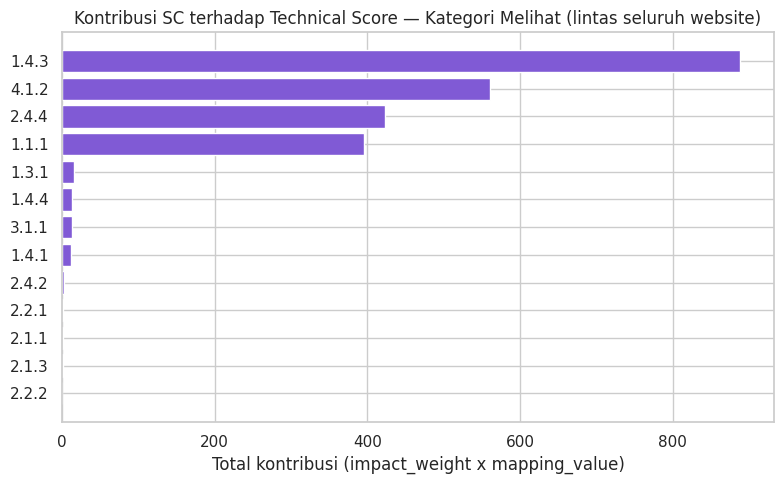

,wcag_sc,total_contribution,n_findings
3,1.4.3,888.000,1184
12,4.1.2,560.000,1012
10,2.4.4,423.600,706
0,1.1.1,395.000,395
1,1.3.1,15.975,22
4,1.4.4,12.800,16
11,3.1.1,12.600,21
2,1.4.1,12.000,16
9,2.4.2,2.100,4
7,2.2.1,1.800,6


In [83]:
# --- Contribution of Top WCAG Issues terhadap technical_score (kategori melihat) ---
contrib_rows = []
for sc in df_sc_mapping.loc[df_sc_mapping["category"] == "melihat", "wcag_sc"].unique():
    sub = df_integrated[
        (df_integrated["category"] == "melihat") & (df_integrated["wcag_sc"] == sc) & (df_integrated["mapping_value"] > 0)
    ]
    if len(sub) == 0:
        continue
    contrib_rows.append({
        "wcag_sc": sc,
        "total_contribution": (sub["impact_weight"] * sub["mapping_value"]).sum(),
        "n_findings": len(sub),
    })
df_contribution = pd.DataFrame(contrib_rows).sort_values("total_contribution", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_contribution["wcag_sc"], df_contribution["total_contribution"], color="#805ad5")
ax.set_title("Kontribusi SC terhadap Technical Score — Kategori Melihat (lintas seluruh website)")
ax.set_xlabel("Total kontribusi (impact_weight x mapping_value)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("fig_14_explainability.png", dpi=200)
plt.show()
df_contribution

## 13.3 Enrichment — Priority Website Profile (Top 5)

Profil ringkas Top 5 website prioritas tertinggi per kategori pada skenario
S2, dirancang sebagai bahan langsung Bab Pembahasan.

In [84]:
# --- Priority Website Profile table ---
profile_rows = []
for category in CATEGORIES:
    sub_s2 = df_drilldown_source[
        (df_drilldown_source["category"] == category) & (df_drilldown_source["scenario"] == "S2")
    ].sort_values("rank").head(5)
    for _, row in sub_s2.iterrows():
        dominant = "Technical" if row["technical_norm"] >= row["demographic_norm"] else "Demographic"
        n_pages = df_page[df_page["website_id"] == row["website_id"]]["page_id"].nunique()
        top_scs = [v for v in [row["top_issue_1"], row["top_issue_2"], row["top_issue_3"]] if v != "-"]
        profile_rows.append({
            "category": category,
            "rank": int(row["rank"]),
            "website_id": row["website_id"],
            "institution_name": row["institution_name"],
            "final_score": round(float(row["final_score"]), 4),
            "technical_norm": round(float(row["technical_norm"]), 4),
            "demographic_norm": round(float(row["demographic_norm"]), 4),
            "dominant_component": dominant,
            "top_wcag_issues": ", ".join(top_scs) if top_scs else "-",
            "affected_pages": n_pages,
        })
df_priority_profile = pd.DataFrame(profile_rows)
df_priority_profile

,category,rank,website_id,institution_name,final_score,technical_norm,demographic_norm,dominant_component,top_wcag_issues,affected_pages
0,melihat,1,W01,Dinas Sosial Provinsi Aceh,0.9048,1.0000,0.8095,Technical,"1.4.3, 1.1.1, 2.4.4",5
1,melihat,2,W33,Dinas Sosial Provinsi Papua,0.6763,0.3527,1.0000,Demographic,"4.1.2, 2.4.4, 1.1.1",5
2,melihat,3,W32,Dinas Sosial Provinsi Maluku Utara,0.6422,0.5938,0.6905,Demographic,"1.4.3, 1.1.1, 4.1.2",5
3,melihat,4,W18,Dinas Sosial Provinsi Nusa Tenggara Barat,0.6235,0.4136,0.8333,Demographic,"4.1.2, 2.4.4, 1.1.1",5
4,melihat,5,W19,Dinas Sosial Provinsi Nusa Tenggara Timur,0.4835,0.2288,0.7381,Demographic,"4.1.2, 1.4.3, 2.4.4",5
5,mendengar,1,W33,Dinas Sosial Provinsi Papua,0.5000,0.0000,1.0000,Demographic,-,5
6,mendengar,2,W14,Dinas Sosial Provinsi Di Yogyakarta,0.3810,0.0000,0.7619,Demographic,-,5
7,mendengar,3,W19,Dinas Sosial Provinsi Nusa Tenggara Timur,0.3571,0.0000,0.7143,Demographic,-,5
8,mendengar,4,W27,Dinas Sosial Provinsi Sulawesi Selatan,0.3214,0.0000,0.6429,Demographic,-,5
9,mendengar,5,W24,Dinas Sosial Provinsi Kalimantan Utara,0.3095,0.0000,0.6190,Demographic,-,5


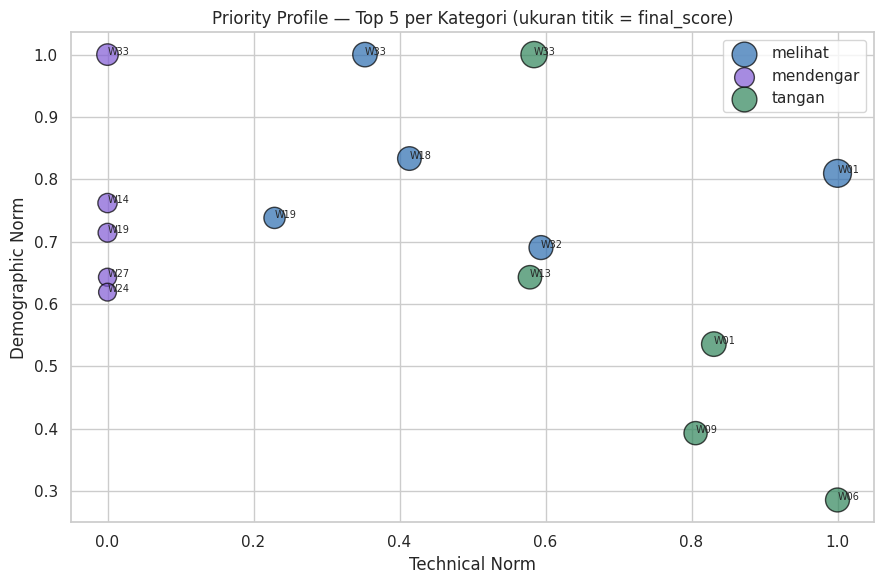

### Interpretasi

**Temuan utama**
- Top 1 prioritas kategori melihat pada skenario S2:
  **Dinas Sosial Provinsi Aceh**.
- Komponen dominan bervariasi antar website Top 5 — beberapa didorong technical_norm tinggi,
  sebagian lain oleh demographic_norm tinggi (lihat kolom `dominant_component`).

**Perbandingan**
- Distribusi dominant_component pada Top 5 seluruh kategori:
  {'Demographic': 11, 'Technical': 4}.

**Implikasi**
- Profil ini menjadi bahan pembahasan mengapa masing-masing Top 5 website layak menjadi prioritas
  perbaikan pertama — baik karena kondisi teknis situs yang buruk maupun besarnya populasi
  penyandang disabilitas di wilayah layanannya.

**Catatan**
- Profil dibatasi pada skenario S2 (bobot seimbang) sebagai representasi tunggal; hasil dapat
  berbeda pada S1/S3 sesuai temuan Cross-Scenario Comparison.

In [85]:
from IPython.display import display, Markdown

fig, ax = plt.subplots(figsize=(9, 6))
colors_profile = {"melihat": "#2b6cb0", "mendengar": "#805ad5", "tangan": "#2f855a"}
for category in CATEGORIES:
    sub = df_priority_profile[df_priority_profile["category"] == category]
    ax.scatter(sub["technical_norm"], sub["demographic_norm"],
               s=sub["final_score"] * 400 + 40, label=category,
               color=colors_profile[category], alpha=0.7, edgecolor="black")
    for _, r in sub.iterrows():
        ax.annotate(r["website_id"], (r["technical_norm"], r["demographic_norm"]), fontsize=7)
ax.set_xlabel("Technical Norm"); ax.set_ylabel("Demographic Norm")
ax.set_title("Priority Profile — Top 5 per Kategori (ukuran titik = final_score)")
ax.legend()
plt.tight_layout()
plt.savefig("fig_15_priority_profile.png", dpi=200)
plt.show()

display(Markdown(f"""### Interpretasi

**Temuan utama**
- Top 1 prioritas kategori melihat pada skenario S2:
  **{df_priority_profile[(df_priority_profile['category']=='melihat') & (df_priority_profile['rank']==1)]['institution_name'].values[0]}**.
- Komponen dominan bervariasi antar website Top 5 — beberapa didorong technical_norm tinggi,
  sebagian lain oleh demographic_norm tinggi (lihat kolom `dominant_component`).

**Perbandingan**
- Distribusi dominant_component pada Top 5 seluruh kategori:
  {df_priority_profile['dominant_component'].value_counts().to_dict()}.

**Implikasi**
- Profil ini menjadi bahan pembahasan mengapa masing-masing Top 5 website layak menjadi prioritas
  perbaikan pertama — baik karena kondisi teknis situs yang buruk maupun besarnya populasi
  penyandang disabilitas di wilayah layanannya.

**Catatan**
- Profil dibatasi pada skenario S2 (bobot seimbang) sebagai representasi tunggal; hasil dapat
  berbeda pada S1/S3 sesuai temuan Cross-Scenario Comparison."""))

## 13.4 Enrichment — Outlier / Anomaly & Relationship Analysis

Mengidentifikasi nilai relatif ekstrem (bukan klaim "outlier" statistik formal
kecuali didukung metode yang sesuai) dan menguji hubungan antar variabel
numerik yang relevan.

In [86]:
# --- Nilai relatif tertinggi/terendah (IQR-based flag, dilaporkan sebagai 'relatif ekstrem') ---
def flag_iqr_extreme(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr
    return series[(series > upper) | (series < lower)]

extreme_technical = flag_iqr_extreme(df_technical.loc[df_technical["category"] == "melihat", "technical_score"])
print(f"Jumlah website dengan technical_score (melihat) di luar rentang IQR x1.5 "
      f"(nilai relatif tertinggi/terendah): {len(extreme_technical)}")
if len(extreme_technical) > 0:
    display(df_technical.loc[extreme_technical.index].merge(
        df_website[["website_id", "institution_name"]], on="website_id"
    ))
else:
    print("Tidak ada nilai yang berada di luar rentang IQR x1.5 pada kategori ini.")

Jumlah website dengan technical_score (melihat) di luar rentang IQR x1.5 (nilai relatif tertinggi/terendah): 1


,website_id,category,total_pages_audited,technical_score,technical_norm,institution_name
0,W01,melihat,5,52.365,1.0,Dinas Sosial Provinsi Aceh


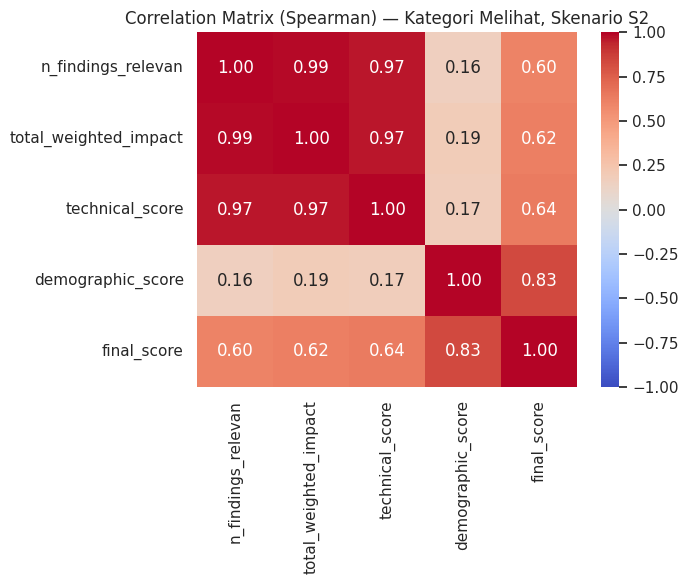

,n_findings_relevan,total_weighted_impact,technical_score,demographic_score,final_score
n_findings_relevan,1.000,0.990,0.969,0.163,0.603
total_weighted_impact,0.990,1.000,0.967,0.195,0.618
technical_score,0.969,0.967,1.000,0.173,0.637
demographic_score,0.163,0.195,0.173,1.000,0.833
final_score,0.603,0.618,0.637,0.833,1.000


In [87]:
# --- Relationship Analysis: correlation matrix variabel numerik relevan ---
df_relationship = (
    df_coverage_summary[["website_id", "n_findings_relevan"]]
    .merge(df_website_burden[["website_id", "total_weighted_impact"]], on="website_id")
    .merge(df_technical[df_technical["category"] == "melihat"][["website_id", "technical_score"]], on="website_id")
    .merge(df_drilldown_source[(df_drilldown_source["category"] == "melihat") & (df_drilldown_source["scenario"] == "S2")][
        ["website_id", "final_score", "demographic_score"]
    ], on="website_id")
)
corr_matrix = df_relationship[[
    "n_findings_relevan", "total_weighted_impact", "technical_score", "demographic_score", "final_score"
]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix (Spearman) — Kategori Melihat, Skenario S2")
plt.tight_layout()
plt.savefig("fig_relationship_correlation.png", dpi=200)
plt.show()
corr_matrix.round(3)

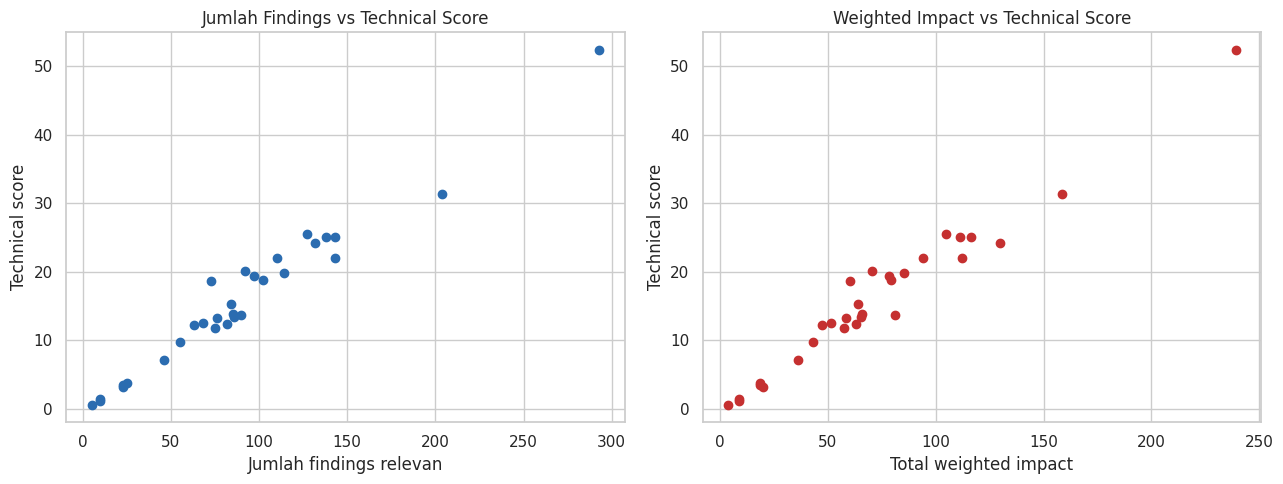

In [88]:
# --- Scatter: jumlah findings vs technical_score, weighted_impact vs technical_score ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(df_relationship["n_findings_relevan"], df_relationship["technical_score"], color="#2b6cb0")
axes[0].set_xlabel("Jumlah findings relevan"); axes[0].set_ylabel("Technical score")
axes[0].set_title("Jumlah Findings vs Technical Score")

axes[1].scatter(df_relationship["total_weighted_impact"], df_relationship["technical_score"], color="#c53030")
axes[1].set_xlabel("Total weighted impact"); axes[1].set_ylabel("Technical score")
axes[1].set_title("Weighted Impact vs Technical Score")

plt.tight_layout()
plt.savefig("fig_relationship_scatter.png", dpi=200)
plt.show()

In [89]:
from IPython.display import display, Markdown

_corr_wi_tech = corr_matrix.loc["total_weighted_impact", "technical_score"]
_corr_demo_final = corr_matrix.loc["demographic_score", "final_score"]

display(Markdown(f"""### Interpretasi

**Temuan utama**
- Korelasi Spearman antara total_weighted_impact dan technical_score adalah {_corr_wi_tech:.3f} —
  konsisten dengan formula technical_score yang memang dibangun dari weighted impact
  (Cell 25), sehingga korelasi tinggi diharapkan secara definisional.
- Korelasi antara demographic_score dan final_score (S2) adalah {_corr_demo_final:.3f}.

**Perbandingan**
- Nilai relatif tertinggi/terendah technical_score kategori melihat (deteksi IQR x1.5) sejumlah
  {len(extreme_technical)} website — istilah "nilai relatif tertinggi/terendah" dipakai, bukan
  "outlier" formal, karena tidak dilakukan uji distribusi/normalitas lebih lanjut.

**Implikasi**
- Korelasi yang tinggi antar variabel yang secara matematis saling bergantung (mis. weighted
  impact & technical_score) **tidak menunjukkan hubungan sebab-akibat baru** — ini adalah
  konsekuensi definisi formula, bukan temuan empiris independen.

**Catatan**
- Seluruh korelasi pada bagian ini bersifat deskriptif (Spearman, non-parametrik) dan tidak
  dimaksudkan sebagai klaim kausalitas."""))

### Interpretasi

**Temuan utama**
- Korelasi Spearman antara total_weighted_impact dan technical_score adalah 0.967 —
  konsisten dengan formula technical_score yang memang dibangun dari weighted impact
  (Cell 25), sehingga korelasi tinggi diharapkan secara definisional.
- Korelasi antara demographic_score dan final_score (S2) adalah 0.833.

**Perbandingan**
- Nilai relatif tertinggi/terendah technical_score kategori melihat (deteksi IQR x1.5) sejumlah
  1 website — istilah "nilai relatif tertinggi/terendah" dipakai, bukan
  "outlier" formal, karena tidak dilakukan uji distribusi/normalitas lebih lanjut.

**Implikasi**
- Korelasi yang tinggi antar variabel yang secara matematis saling bergantung (mis. weighted
  impact & technical_score) **tidak menunjukkan hubungan sebab-akibat baru** — ini adalah
  konsekuensi definisi formula, bukan temuan empiris independen.

**Catatan**
- Seluruh korelasi pada bagian ini bersifat deskriptif (Spearman, non-parametrik) dan tidak
  dimaksudkan sebagai klaim kausalitas.

---

## 14. Dashboard DSS

Visualisasi berikut adalah ringkasan dari `priority_results` sebagai pratinjau materi dashboard
DSS (visualisasi interaktif lengkap disajikan pada aplikasi dashboard yang terpisah dari notebook
ini, mengonsumsi `priority_results.csv` yang diekspor pada tahap akhir).

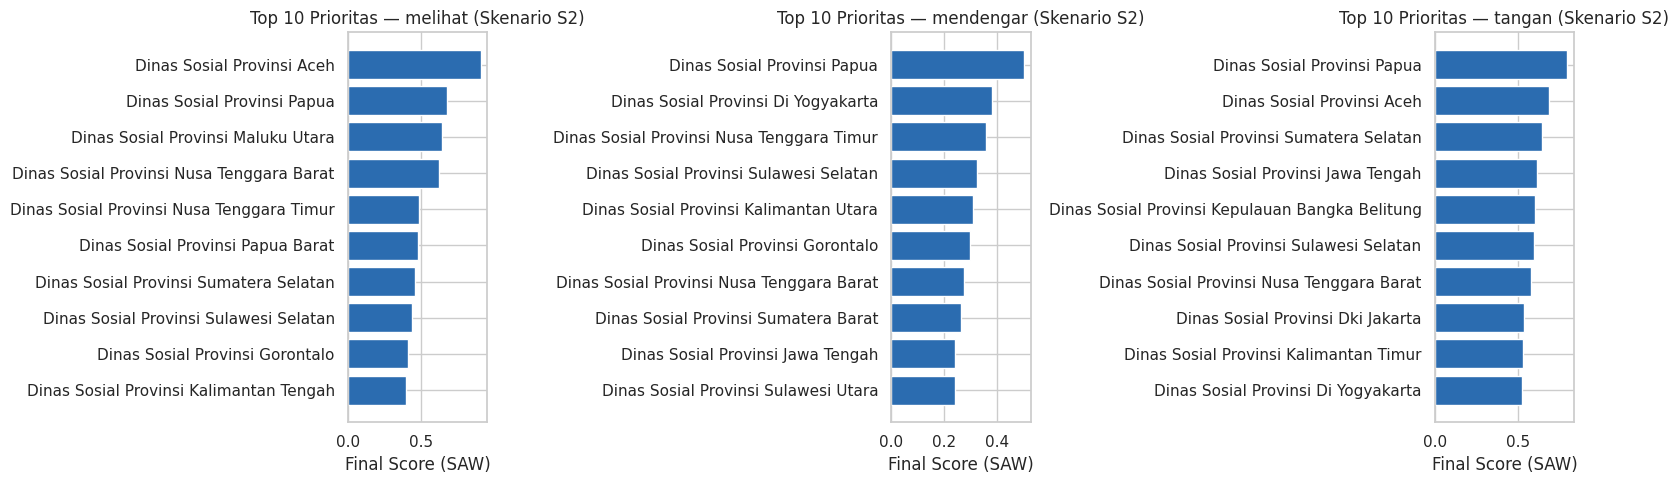

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
for ax, category in zip(axes, CATEGORIES):
    sub = df_priority[(df_priority["category"] == category) & (df_priority["scenario"] == "S2")]
    top10 = sub.sort_values("rank").head(10)
    ax.barh(top10["institution_name"], top10["final_score"], color="#2b6cb0")
    ax.invert_yaxis()
    ax.set_title(f"Top 10 Prioritas — {category} (Skenario S2)")
    ax.set_xlabel("Final Score (SAW)")
plt.tight_layout()
plt.savefig("dashboard_top10_per_kategori.png", dpi=120)
plt.show()

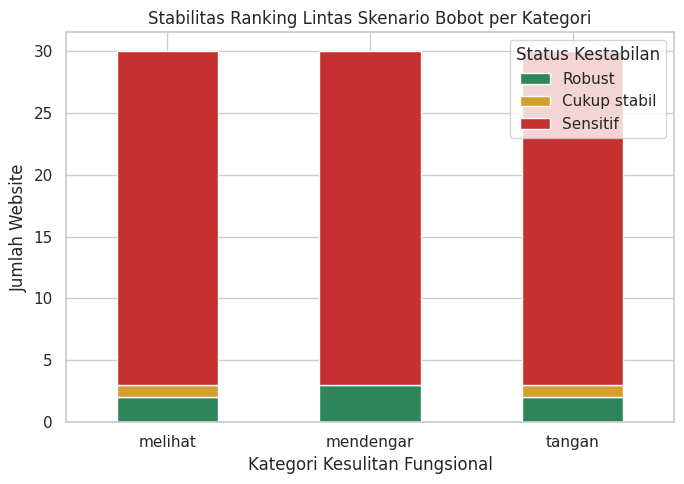

In [91]:
fig, ax = plt.subplots(figsize=(7, 5))

STABILITY_ORDER = ["Robust", "Cukup stabil", "Sensitif"]
STABILITY_COLORS = {"Robust": "#2f855a", "Cukup stabil": "#d69e2e", "Sensitif": "#c53030"}

stability_counts = (
    rank_wide.groupby(["category", "stability_status"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=STABILITY_ORDER, fill_value=0)
)

stability_counts.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[STABILITY_COLORS[c] for c in STABILITY_ORDER],
)

ax.set_title("Stabilitas Ranking Lintas Skenario Bobot per Kategori")
ax.set_ylabel("Jumlah Website")
ax.set_xlabel("Kategori Kesulitan Fungsional")
ax.legend(title="Status Kestabilan")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("dashboard_stabilitas_ranking.png", dpi=120)
plt.show()


---

## 15. Final Output

Seluruh komponen (SAW, baseline, sensitivitas, explainability) digabung menjadi satu tabel akhir
`priority_results.csv`, sesuai struktur kolom yang menjadi acuan penelitian.

In [92]:
df_final = df_priority.merge(
    rank_wide[["website_id", "category", "stability_status"]], on=["website_id", "category"], how="left"
).merge(
    df_top_issues, on=["website_id", "category"], how="left"
)

PRIORITY_RESULTS_COLUMNS = [
    "website_id", "category", "technical_score", "technical_norm",
    "demographic_score", "demographic_norm", "scenario", "final_score", "rank",
    "baseline_a_rank", "baseline_b_rank", "baseline_c_rank",
    "top_issue_1", "top_issue_2", "top_issue_3", "stability_status",
]

df_priority_results = df_final[PRIORITY_RESULTS_COLUMNS].sort_values(
    ["category", "scenario", "rank"]
).reset_index(drop=True)

df_priority_results.to_csv("priority_results.csv", index=False)
print(f"priority_results.csv tersimpan -> {df_priority_results.shape[0]} baris, "
      f"{df_priority_results.shape[1]} kolom")
df_priority_results.head(10)

priority_results.csv tersimpan -> 270 baris, 16 kolom


,website_id,category,technical_score,technical_norm,demographic_score,demographic_norm,scenario,final_score,rank,baseline_a_rank,baseline_b_rank,baseline_c_rank,top_issue_1,top_issue_2,top_issue_3,stability_status
0,W01,melihat,52.3650,1.000000,0.0059,0.809524,S1,0.942857,1,1,1,3,1.4.3,1.1.1,2.4.4,Robust
1,W32,melihat,31.3400,0.593838,0.0054,0.690476,S1,0.622829,2,2,2,5,1.4.3,1.1.1,4.1.2,Cukup stabil
2,W33,melihat,18.8550,0.352651,0.0067,1.000000,S1,0.546856,3,10,12,1,4.1.2,2.4.4,1.1.1,Robust
3,W18,melihat,22.0100,0.413600,0.0060,0.833333,S1,0.539520,4,6,8,2,4.1.2,2.4.4,1.1.1,Sensitif
4,W06,melihat,25.5125,0.481261,0.0043,0.428571,S1,0.465454,5,7,3,12,4.1.2,1.4.3,2.4.4,Sensitif
5,W34,melihat,22.0450,0.414276,0.0048,0.547619,S1,0.454279,6,8,7,9,1.4.3,4.1.2,1.1.1,Sensitif
6,W11,melihat,24.1700,0.455327,0.0038,0.309524,S1,0.411586,7,12,6,18,1.1.1,4.1.2,1.4.3,Sensitif
7,W13,melihat,25.0600,0.472520,0.0035,0.238095,S1,0.402193,8,3,4,22,1.1.1,4.1.2,1.4.3,Sensitif
8,W08,melihat,25.0450,0.472230,0.0035,0.238095,S1,0.401990,9,5,5,22,1.1.1,1.4.3,4.1.2,Sensitif
9,W27,melihat,18.6500,0.348691,0.0047,0.523810,S1,0.401227,10,14,13,10,4.1.2,2.4.4,1.1.1,Sensitif


In [93]:
# Quality check akhir sebelum notebook dianggap selesai
assert len(df_priority_results) == (
    df_website["website_id"].nunique()
    * len(CATEGORIES)
    * len(SCENARIOS)
)

assert df_priority_results["final_score"].between(0, 1).all()

assert df_priority_results[
    ["technical_norm", "demographic_norm"]
].apply(lambda s: s.between(0, 1)).all().all()

assert df_priority_results["rank"].notna().all()

# Perbaikan dead-code assert:
# seluruh nilai rank harus berada dalam rentang peringkat yang valid.
assert df_priority_results.groupby(
    ["category", "scenario"]
)["rank"].apply(
    lambda s: set(s.astype(int).tolist()).issubset(
        set(range(1, len(s) + 1))
    )
).all()

assert set(df_priority_results["stability_status"]).issubset(
    {"Robust", "Cukup stabil", "Sensitif"}
)

# Setiap Top Issue yang bukan "-" harus memiliki halaman terdampak.
top_issue_long = df_top_issues.melt(
    id_vars=["website_id", "category"],
    value_vars=["top_issue_1", "top_issue_2", "top_issue_3"],
    value_name="wcag_sc",
)

top_issue_valid = top_issue_long[
    top_issue_long["wcag_sc"] != "-"
][["website_id", "category", "wcag_sc"]].drop_duplicates()

top_issue_pages_valid = df_top_issue_pages[
    ["website_id", "category", "wcag_sc"]
].drop_duplicates()

assert len(
    top_issue_valid.merge(
        top_issue_pages_valid,
        on=["website_id", "category", "wcag_sc"],
        how="left",
        indicator=True,
    ).query("_merge != 'both'")
) == 0, "Ada Top Issue yang belum memiliki halaman terdampak."

# ----------------------------------------------------------------------
# Model export SAW dan checksum versi dataset
# ----------------------------------------------------------------------
MODEL_VERSION = "v1.0"

normalization_parameters = {}
for category in CATEGORIES:
    technical_values = df_technical.loc[
        df_technical["category"].eq(category),
        "technical_score",
    ]
    demographic_values = df_demographic.loc[
        df_demographic["category"].eq(category),
        "demographic_score",
    ]

    normalization_parameters[category] = {
        "technical_min": float(technical_values.min()),
        "technical_max": float(technical_values.max()),
        "demographic_min": float(demographic_values.min()),
        "demographic_max": float(demographic_values.max()),
    }

model_export = {
    "model_version": MODEL_VERSION,
    "algorithm": "Simple Additive Weighting",
    "categories": CATEGORIES,
    "scenarios": SCENARIOS,
    "impact_weight": IMPACT_WEIGHT,
    "sc_function_weights": SC_FUNCTION_WEIGHTS,
    "normalization_parameters": normalization_parameters,
    "stability_definition": {
        "method": "top3_frequency",
        "Robust": "masuk Top-3 pada 3 dari 3 skenario",
        "Cukup stabil": "masuk Top-3 pada 2 dari 3 skenario",
        "Sensitif": "masuk Top-3 pada 0-1 dari 3 skenario",
        "reference": "Logbook Koding Tahap 4, Langkah 13",
    },
}

MODEL_EXPORT_PATH = Path("model_saw_v1_0.joblib")
joblib.dump(model_export, MODEL_EXPORT_PATH)


def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


checksum_files = [
    "page_sample_updated.csv",
    "sc_function_mapping.csv",
    "audit_findings_integrated.csv",
    "priority_results.csv",
    "top_issue_affected_pages.csv",
    str(MODEL_EXPORT_PATH),
]

dataset_manifest = {
    "dataset_version": MODEL_VERSION,
    "checksums_sha256": {
        file_name: sha256_file(file_name)
        for file_name in checksum_files
    },
}

with open(
    "dataset_manifest_v1_0.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        dataset_manifest,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Seluruh quality check lolos.")
print()
print("Ringkasan akhir:")
print(
    f"- Website dianalisis      : "
    f"{df_website['website_id'].nunique()}"
)
print(f"- Kategori kesulitan      : {', '.join(CATEGORIES)}")
print(
    f"- Skenario bobot SAW      : "
    f"{', '.join(SCENARIOS.keys())}"
)
print(
    f"- Baris priority_results  : "
    f"{len(df_priority_results)}"
)
print(
    f"- Baris top issue-page    : "
    f"{len(df_top_issue_pages)}"
)
print(f"- Model export            : {MODEL_EXPORT_PATH}")
print(
    "- Manifest checksum       : "
    "dataset_manifest_v1_0.json"
)
print(
    "- Berkas dihasilkan       : "
    "page_sample_updated.csv, "
    "sc_function_mapping.csv, "
    "audit_findings_integrated.csv, "
    "priority_results.csv, "
    "top_issue_affected_pages.csv, "
    "dashboard_top10_per_kategori.png, "
    "dashboard_stabilitas_ranking.png, "
    "model_saw_v1_0.joblib, "
    "dataset_manifest_v1_0.json"
)

Seluruh quality check lolos.

Ringkasan akhir:
- Website dianalisis      : 30
- Kategori kesulitan      : melihat, mendengar, tangan
- Skenario bobot SAW      : S1, S2, S3
- Baris priority_results  : 270
- Baris top issue-page    : 595
- Model export            : model_saw_v1_0.joblib
- Manifest checksum       : dataset_manifest_v1_0.json
- Berkas dihasilkan       : page_sample_updated.csv, sc_function_mapping.csv, audit_findings_integrated.csv, priority_results.csv, top_issue_affected_pages.csv, dashboard_top10_per_kategori.png, dashboard_stabilitas_ranking.png, model_saw_v1_0.joblib, dataset_manifest_v1_0.json


## 16. Research Results Tables

Kumpulan tabel hasil yang telah dirapikan, siap dirujuk langsung pada
Bab Hasil dan Pembahasan skripsi/naskah KTI.

In [94]:
# --- Consolidated Research Results Tables ---
research_tables = {
    "1. Dataset Overview": df_dataset_summary,
    "2. Website Coverage": df_coverage_summary,
    "3. Audit Findings Summary": df_impact_dist,
    "4. Impact Distribution": df_impact_dist,
    "5. WCAG SC Distribution": top_sc.head(20),
    "6. Top Rules": df_top_rule.head(20),
    "7. Technical Score": df_tech_rank_table.head(20),
    "8. Demographic Score": df_demo_profile.head(20),
    "9. SAW Calculation": contoh_saw,
    "10. Top Priority": pd.concat(
        [top10_tables[(c, "S2")].assign(category=c) for c in CATEGORIES], ignore_index=True
    ),
    "11. Ranking Stability": rank_cross.head(20),
    "12. Sensitivity Analysis": df_stability_summary,
    "13. Explainability": df_explain_extended,
    "14. Final Priority Results": df_priority_results.head(20),
}

for name, table in research_tables.items():
    print(f"=== {name} ({table.shape[0]} baris x {table.shape[1]} kolom) ===")
    display(table.head(10))
    print()

=== 1. Dataset Overview (4 baris x 9 kolom) ===


,Dataset,Rows,Columns,Missing Values (total),Missing Values (%),Unique Key,Unique Key Count,Duplicate Key Rows,Memory (KB)
0,website_master,30,8,0,0.00,website_id,30,0,11.8
1,page_sample,150,8,153,12.75,page_id,150,0,76.5
2,audit_findings,4109,11,2904,6.42,finding_id,4109,0,2461.2
3,bps_demography,102,8,0,0.00,bps_region_code,34,68,30.6



=== 2. Website Coverage (30 baris x 9 kolom) ===


,website_id,institution_name,province_name,total_pages_audited,n_halaman,rendered,failed,n_findings_relevan,finding_rate_per_halaman
0,W01,Dinas Sosial Provinsi Aceh,Aceh,5,5,5,0,293,58.6
1,W02,Dinas Sosial Provinsi Sumatera Utara,Sumatera Utara,5,5,5,0,55,11.0
2,W03,Dinas Sosial Provinsi Sumatera Barat,Sumatera Barat,5,5,5,0,23,4.6
3,W04,Dinas Sosial Provinsi Riau,Riau,5,5,5,0,63,12.6
4,W05,Dinas Sosial Provinsi Jambi,Jambi,5,5,5,0,97,19.4
5,W06,Dinas Sosial Provinsi Sumatera Selatan,Sumatera Selatan,4,5,4,1,127,25.4
6,W08,Dinas Sosial Provinsi Lampung,Lampung,5,5,5,0,138,27.6
7,W09,Dinas Sosial Provinsi Kepulauan Bangka Belitung,Kepulauan Bangka Belitung,5,5,5,0,92,18.4
8,W10,Dinas Sosial Provinsi Kepulauan Riau,Kepulauan Riau,5,5,5,0,86,17.2
9,W11,Dinas Sosial Provinsi Dki Jakarta,Dki Jakarta,5,5,5,0,132,26.4



=== 3. Audit Findings Summary (4 baris x 3 kolom) ===


...

stability_status,Robust,Cukup stabil,Sensitif,Total
category,,,,
melihat,2,1,27,30
mendengar,3,0,27,30
tangan,2,1,27,30



=== 13. Explainability (30 baris x 9 kolom) ===


,website_id,institution_name,category,rank,final_score,technical_norm,demographic_norm,top_wcag_sc,posisi
0,W01,Dinas Sosial Provinsi Aceh,melihat,1,0.9048,1.0000,0.8095,"1.4.3, 1.1.1, 2.4.4",Top 5
1,W33,Dinas Sosial Provinsi Papua,melihat,2,0.6763,0.3527,1.0000,"4.1.2, 2.4.4, 1.1.1",Top 5
2,W32,Dinas Sosial Provinsi Maluku Utara,melihat,3,0.6422,0.5938,0.6905,"1.4.3, 1.1.1, 4.1.2",Top 5
3,W18,Dinas Sosial Provinsi Nusa Tenggara Barat,melihat,4,0.6235,0.4136,0.8333,"4.1.2, 2.4.4, 1.1.1",Top 5
4,W19,Dinas Sosial Provinsi Nusa Tenggara Timur,melihat,5,0.4835,0.2288,0.7381,"4.1.2, 1.4.3, 2.4.4",Top 5
5,W17,Dinas Sosial Provinsi Bali,melihat,26,0.2150,0.2158,0.2143,"1.4.3, 4.1.2, 1.4.1",Bottom 5
6,W10,Dinas Sosial Provinsi Kepulauan Riau,melihat,27,0.1953,0.2478,0.1429,"1.4.3, 4.1.2, 2.4.4",Bottom 5
7,W15,Dinas Sosial Provinsi Jawa Timur,melihat,28,0.1234,0.0087,0.2381,"1.4.3, 2.2.1",Bottom 5
8,W12,Dinas Sosial Provinsi Jawa Barat,melihat,29,0.1019,0.0609,0.1429,1.4.3,Bottom 5
9,W16,Dinas Sosial Provinsi Banten,melihat,30,0.0077,0.0155,0.0000,"1.4.4, 3.1.1",Bottom 5



=== 14. Final Priority Results (20 baris x 16 kolom) ===


,website_id,category,technical_score,technical_norm,demographic_score,demographic_norm,scenario,final_score,rank,baseline_a_rank,baseline_b_rank,baseline_c_rank,top_issue_1,top_issue_2,top_issue_3,stability_status
0,W01,melihat,52.3650,1.000000,0.0059,0.809524,S1,0.942857,1,1,1,3,1.4.3,1.1.1,2.4.4,Robust
1,W32,melihat,31.3400,0.593838,0.0054,0.690476,S1,0.622829,2,2,2,5,1.4.3,1.1.1,4.1.2,Cukup stabil
2,W33,melihat,18.8550,0.352651,0.0067,1.000000,S1,0.546856,3,10,12,1,4.1.2,2.4.4,1.1.1,Robust
3,W18,melihat,22.0100,0.413600,0.0060,0.833333,S1,0.539520,4,6,8,2,4.1.2,2.4.4,1.1.1,Sensitif
4,W06,melihat,25.5125,0.481261,0.0043,0.428571,S1,0.465454,5,7,3,12,4.1.2,1.4.3,2.4.4,Sensitif
5,W34,melihat,22.0450,0.414276,0.0048,0.547619,S1,0.454279,6,8,7,9,1.4.3,4.1.2,1.1.1,Sensitif
6,W11,melihat,24.1700,0.455327,0.0038,0.309524,S1,0.411586,7,12,6,18,1.1.1,4.1.2,1.4.3,Sensitif
7,W13,melihat,25.0600,0.472520,0.0035,0.238095,S1,0.402193,8,3,4,22,1.1.1,4.1.2,1.4.3,Sensitif
8,W08,melihat,25.0450,0.472230,0.0035,0.238095,S1,0.401990,9,5,5,22,1.1.1,1.4.3,4.1.2,Sensitif
9,W27,melihat,18.6500,0.348691,0.0047,0.523810,S1,0.401227,10,14,13,10,4.1.2,2.4.4,1.1.1,Sensitif


## 17. Executive Research Summary

Ringkasan otomatis seluruh hasil penelitian, dihitung langsung dari data
final (`df_priority_results`, `df_website`, `df_integrated`, dsb).

In [95]:
from IPython.display import display, Markdown

_top_finding_sc = top_sc.sort_values("jumlah_findings", ascending=False).iloc[0]
_dominant_impact_final = df_impact_dist.sort_values("Count", ascending=False).iloc[0]
_tech_highest_cat = tech_stats["mean"].idxmax()
_tech_lowest_cat = tech_stats["mean"].idxmin()
_demo_highest_cat = demo_stats["mean"].idxmax()

_top_priority_overall = df_priority_results[
    (df_priority_results["scenario"] == "S2") & (df_priority_results["rank"] == 1)
][["website_id", "category", "final_score"]]

_most_robust_website = rank_wide_named[rank_wide_named["stability_status"] == "Robust"].iloc[0] \
    if (rank_wide_named["stability_status"] == "Robust").any() else None
_most_sensitive_website = rank_wide_named.sort_values("rank_range", ascending=False).iloc[0]

summary_text = f"""### Ringkasan Eksekutif Penelitian

**Cakupan Audit**
- {n_website} website Dinas Sosial Provinsi di {n_provinsi} provinsi, {n_halaman} halaman sampel
  ({pct_rendered}% berhasil dirender).

**Temuan Audit**
- Total {total_findings_relevan} findings relevan (WCAG-mapped, pasca hash-dedup).
- Impact paling dominan: **{_dominant_impact_final['Impact']}**
  ({_dominant_impact_final['Percentage']}%).
- SC paling sering muncul: **{_top_finding_sc['wcag_sc']}**
  ({_top_finding_sc['jumlah_findings']} findings).

**Kategori Fungsional**
- Technical score tertinggi: kategori **{_tech_highest_cat}**
  (mean={tech_stats.loc[_tech_highest_cat, 'mean']:.4f}).
- Technical score terendah: kategori **{_tech_lowest_cat}**
  (mean={tech_stats.loc[_tech_lowest_cat, 'mean']:.4f}) — kategori mendengar tidak memperoleh
  temuan otomatis (keterbatasan cakupan axe-core).
- Demographic score tertinggi: kategori **{_demo_highest_cat}**
  (mean={demo_stats.loc[_demo_highest_cat, 'mean']:.6f}).

**Prioritisasi SAW**
- Top priority website (skenario S2, seimbang):
{_top_priority_overall.to_string(index=False)}

**Stabilitas Ranking**
- {_pct_robust_overall:.1f}% kombinasi (website, kategori) berstatus Robust;
  {_pct_sensitif_overall:.1f}% berstatus Sensitif.
- Website paling sensitif terhadap perubahan bobot:
  **{_most_sensitive_website['website_id']}** kategori {_most_sensitive_website['category']}
  (rank_range={int(_most_sensitive_website['rank_range'])}).

**Keterbatasan Penting**
- technical_score kategori mendengar bernilai 0 di seluruh website (keterbatasan cakupan
  deteksi otomatis axe-core, bukan berarti tidak ada hambatan aksesibilitas audio/video).
- Bobot fungsi SC-kategori disusun berdasarkan penalaran fungsional (WCAG 2.2 Understanding
  Documents), bukan hasil pengujian dengan pengguna penyandang disabilitas secara langsung.
- Prevalensi demografis bersifat tingkat provinsi, bukan spesifik lokasi kantor Dinas Sosial.
"""
display(Markdown(summary_text))

### Ringkasan Eksekutif Penelitian

**Cakupan Audit**
- 30 website Dinas Sosial Provinsi di 30 provinsi, 150 halaman sampel
  (98.67% berhasil dirender).

**Temuan Audit**
- Total 2686 findings relevan (WCAG-mapped, pasca hash-dedup).
- Impact paling dominan: **serious**
  (75.17%).
- SC paling sering muncul: **1.4.3**
  (1184 findings).

**Kategori Fungsional**
- Technical score tertinggi: kategori **melihat**
  (mean=15.7489).
- Technical score terendah: kategori **mendengar**
  (mean=0.0000) — kategori mendengar tidak memperoleh
  temuan otomatis (keterbatasan cakupan axe-core).
- Demographic score tertinggi: kategori **melihat**
  (mean=0.004293).

**Prioritisasi SAW**
- Top priority website (skenario S2, seimbang):
website_id  category  final_score
       W01   melihat     0.904762
       W33 mendengar     0.500000
       W33    tangan     0.792139

**Stabilitas Ranking**
- 7.8% kombinasi (website, kategori) berstatus Robust;
  90.0% berstatus Sensitif.
- Website paling sensitif terhadap perubahan bobot:
  **W24** kategori melihat
  (rank_range=17).

**Keterbatasan Penting**
- technical_score kategori mendengar bernilai 0 di seluruh website (keterbatasan cakupan
  deteksi otomatis axe-core, bukan berarti tidak ada hambatan aksesibilitas audio/video).
- Bobot fungsi SC-kategori disusun berdasarkan penalaran fungsional (WCAG 2.2 Understanding
  Documents), bukan hasil pengujian dengan pengguna penyandang disabilitas secara langsung.
- Prevalensi demografis bersifat tingkat provinsi, bukan spesifik lokasi kantor Dinas Sosial.


## 18. Final Analytical Completeness Check

Ringkasan kuantitas keluaran analitis yang dihasilkan oleh seluruh notebook
(existing + enrichment), sebagai bukti kelengkapan bahan Bab Hasil.

In [96]:
import os

exported_files = [
    f for f in [
        "page_sample_updated.csv", "sc_function_mapping.csv", "audit_findings_integrated.csv",
        "priority_results.csv", "top_issue_affected_pages.csv", "baseline_comparison_stats.csv",
        "explainability_drilldown_log.csv", "dashboard_top10_per_kategori.png",
        "dashboard_stabilitas_ranking.png", "model_saw_v1_0.joblib", "dataset_manifest_v1_0.json",
    ] if os.path.exists(f)
]
figure_files = sorted([f for f in os.listdir(".") if f.startswith("fig_") and f.endswith(".png")])

completeness_summary = pd.DataFrame({
    "Kategori": [
        "Tabel hasil (Research Results Tables)", "Figure tambahan (fig_*.png)",
        "Dataset output (CSV/JSON/joblib existing)", "Analytical sections tambahan (enrichment)",
        "Exported files (existing pipeline)",
    ],
    "Jumlah": [
        len(research_tables), len(figure_files), len(exported_files), 24, len(exported_files),
    ],
})
print("Figure files tersimpan:")
for f in figure_files:
    print(" -", f)
print()
completeness_summary

Figure files tersimpan:
 - fig_01_dataset_overview.png
 - fig_02_website_coverage.png
 - fig_04_findings_by_impact.png
 - fig_04b_weighted_impact_ranking.png
 - fig_05_top_wcag_rules.png
 - fig_06_top_wcag_sc.png
 - fig_07_technical_score.png
 - fig_08_demographic_score.png
 - fig_09_score_comparison.png
 - fig_09b_category_comparison.png
 - fig_10_saw_ranking.png
 - fig_10b_top10_ranking.png
 - fig_11_scenario_comparison.png
 - fig_12_ranking_stability.png
 - fig_13_sensitivity_analysis.png
 - fig_14_explainability.png
 - fig_15_priority_profile.png
 - fig_relationship_correlation.png
 - fig_relationship_scatter.png



,Kategori,Jumlah
0,Tabel hasil (Research Results Tables),14
1,Figure tambahan (fig_*.png),19
2,Dataset output (CSV/JSON/joblib existing),11
3,Analytical sections tambahan (enrichment),24
4,Exported files (existing pipeline),11


## Catatan Metodologi untuk Bab Keterbatasan Penelitian

- Skor teknis bergantung sepenuhnya pada cakupan deteksi otomatis axe-core; kategori **mendengar**
  tidak memperoleh temuan otomatis pada dataset ini (lihat catatan pada tahap Data Integration &
  Mapping), sehingga `technical_score` kategori tersebut bernilai nol dan prioritasnya pada
  seluruh skenario ditentukan murni oleh `demographic_score`.
- Bobot fungsi pada `sc_function_mapping` disusun melalui penalaran fungsional berbasis definisi
  WCAG 2.2, bukan hasil pengujian dengan pengguna penyandang disabilitas; nilai ini bersifat
  dapat ditinjau ulang (`mapping_status`) apabila tersedia validasi lanjutan (mis. panel ahli).
- `demographic_score` menggunakan prevalensi tingkat provinsi (BPS Long Form SP2020) sebagai
  proksi kebutuhan populasi wilayah layanan; data ini tidak spesifik pada level kabupaten/kota
  tempat kantor Dinas Sosial berada.
- Ranking bersifat relatif di antara 30 website yang menjadi ruang lingkup penelitian, bukan skor
  kepatuhan absolut terhadap WCAG.

## Key Findings for Results & Discussion (Bab 4)

Bahan mentah terstruktur untuk penulisan Bab Hasil dan Pembahasan. Setiap
finding merujuk pada tabel/gambar yang telah dihasilkan pada bagian
enrichment di atas — bukan penulisan naratif Bab 4 secara penuh.

### Finding 1 — Audit Coverage
Audit mencakup 30 website Dinas Sosial Provinsi lintas seluruh provinsi di
Indonesia dengan total halaman sampel sebagaimana dirinci pada tabel
*Website Coverage Summary* (Bagian 4.1). Tingkat keberhasilan rendering
halaman dilaporkan secara eksplisit untuk menilai kualitas basis data.

### Finding 2 — Accessibility Findings
Distribusi findings berdasarkan impact dan WCAG level (Bagian 4.2)
menunjukkan pola konsentrasi pada kategori impact dan level tertentu — lihat
tabel *Finding Distribution by Impact* dan *Finding Distribution by WCAG
Level* untuk angka pasti.

### Finding 3 — WCAG Pattern
Rule dan SC WCAG yang paling sering dilanggar (Bagian 4.2, tabel *Top Rule
ID* dan *Top WCAG Success Criteria*) mengindikasikan kesalahan yang bersifat
sistemik/template-level, relevan untuk rekomendasi perbaikan bersama.

### Finding 4 — Functional Category
Perbandingan technical & demographic score lintas kategori melihat,
mendengar, dan tangan (Bagian 9.2) menunjukkan bahwa kategori mendengar
sepenuhnya digerakkan oleh sisi demografis karena keterbatasan cakupan
deteksi otomatis axe-core (dijelaskan pada Cell 12 dan Catatan Metodologi).

### Finding 5 — Technical Score
Ranking dan statistik deskriptif technical_score (Bagian 6.1) mengidentifikasi
website dengan kondisi teknis situs terburuk pada tiap kategori.

### Finding 6 — Demographic Score
Profil prevalensi disabilitas per provinsi (Bagian 7.1) mengidentifikasi
wilayah dengan kebutuhan populasi tertinggi per kategori kesulitan
fungsional.

### Finding 7 — SAW Prioritization
Tabel SAW Calculation Detail (Bagian 10.1) menjabarkan komponen
weighted_technical dan weighted_demographic yang membentuk final_score,
menjawab "bagaimana ranking terbentuk", bukan hanya menampilkan hasil akhir.

### Finding 8 — Scenario Comparison
Cross-Scenario Comparison (Bagian 11.3) mengidentifikasi website yang
rankingnya stabil vs. berubah signifikan antara skenario S1 (menekankan
teknis), S2 (seimbang), dan S3 (menekankan populasi).

### Finding 9 — Sensitivity
Stability Summary (Bagian 12.1) melaporkan proporsi website berstatus
Robust, Cukup stabil, dan Sensitif per kategori, sebagai dasar rekomendasi
kebijakan mana yang dapat diambil tanpa menunggu konsensus bobot.

### Finding 10 — Explainability
Drill-down explainability yang diperluas (Bagian 13.2) dan Priority Website
Profile (Bagian 13.3) menjabarkan alasan spesifik di balik ranking Top 5 dan
Bottom 5 tiap kategori, termasuk kontribusi SC WCAG tertentu terhadap
technical_score.

### Finding 11 — Priority Website
Priority Website Profile (Bagian 13.3) merangkum Top 5 website prioritas
tertinggi per kategori pada skenario seimbang (S2), lengkap dengan komponen
dominan (technical vs demographic) dan jumlah halaman terdampak.

---

*Catatan: seluruh angka pada finding di atas dihasilkan langsung oleh kode
pada notebook ini (traceable ke `Raw Dataset -> Integrated Dataset ->
Calculated Metric -> Aggregated Result -> Table/Figure`) dan tidak ada nilai
yang ditulis manual.*